# PyDI Data Integration Workflow: Products

This notebook demonstrates how PyDI is used for end-to-end data integration. We'll work with product datasets to showcase the data integration pipeline from information extraction over schema and entity matching to data fusion.

## Table of Contents

* [Part 1: Information Extraction](#Part-1:-Information-Extraction)
    * [Step 1: Load Source Datasets](#Step-1:-Load-Source-Datasets)
    * [Step 2: Create Schema for Information Extraction](#Step-2:-Create-Schema-for-Information-Extraction)
    * [Step 3: Run LLM-Based Extraction](#Step-3:-Run-LLM-Based-Extraction-(few-shot)-using-Schema)
* [Part 2: Data Loading and Profiling](#Part-2:-Data-Loading-and-Profiling)
    * [Step 1: Loading the data](#Step-1:-Loading-the-data)
    * [Step 2: Profiling](#Step-2:-Profiling)
    * [Step 3: Dropping Sparse columns](#Step-3:-Dropping-Sparse-columns)
* [Part 3: Normalization](#Part-3:-Normalization)
    * [Step 1: Normalizing Brands](#Step-1:-Normalizing-Brands)
    * [Step 2: Normalizing Weight](#Step-2:-Normalizing-Weight)
    * [Step 3: Normalizing Storage](#Step-3:-Normalizing-Storage)
    * [Step 4: Normalizing Dimensions](#Step-4:-Normalizing-Dimensions)
    * [Step 5: Normalizing VRAM](#Step-5:-Normalizing-VRAM)
    * [Step 6: Normalizing chipset_name](#Step-6:-Normalizing-chipset_name)
    * [Step 7: Normalizing bus_type](#Step-7:-Normalizing-bus_type)
    * [Step 8: Price Normalization](#Step-8:-Price-Normalization)
* [Part 4: LLM-Based Schema Matching](#Part-4:-LLM-Based-Schema-Matching)
    * [Step 1: Schema Matching](#Step-1:-Schema-Matching)
    * [Step 2: Data profiling (again)](#Step-2:-Data-profiling-(again))
* [Part 5: Entity Matching](#Part-5:-Entity-Matching)
    * [Step 1: Blocking](#Step-1:-Blocking)
    * [Step 2: Evaluate Blocking Against Ground Truth](#Step-2:-Evaluate-Blocking-Against-Ground-Truth)
    * [Step 3: Entity Matching with Comparators](#Step-3:-Entity-Matching-with-Comparators)
    * [Step 4: Rule Based Matcher](#Step-4:-Rule-Based-Matcher)
    * [Step 5: Evaluate Matching Against Ground Truth](#Step-5:-Evaluate-Matching-Against-Ground-Truth)
    * [Step 6: GreedyOneToOneMatchingAlgorithm](#Step-6:-GreedyOneToOneMatchingAlgorithm)
    * [Step 7: MaximumBipartiteMatching](#Step-7:-MaximumBipartiteMatching)
    * [Step 8: ML-Based Matcher](#Step-8:-ML-Based-Matcher)
* [Part 6: Data Fusion](#Part-6:-Data-Fusion)
    * [Step 1: Define Fusion Strategy](#Step-1:-Define-Fusion-Strategy)
    * [Step 2: Run Fusion](#Step-2:-Run-Fusion)
    * [Step 3: Evaluate Data Fusion](#step-3-evaluate-data-fusion)

## Part 1: Information Extraction

In [ ]:
from pathlib import Path
import pandas as pd
import json
from PyDI.informationextraction import LLMExtractor
from PyDI.schemamatching import LLMBasedSchemaMatcher, SchemaTranslator
from PyDI.normalization import load_normalization_spec
from langchain_openai import ChatOpenAI

from __future__ import annotations
import os
from collections import Counter
from typing import Any

# Paths relative to this notebook
NOTEBOOK_DIR = Path(".").resolve()
INPUT_DIR = NOTEBOOK_DIR / "input"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Step 1: Load Source Datasets

In [ ]:
from PyDI.io import load_json

products_1 = load_json(INPUT_DIR / "data" / "products_1.json")
products_1.attrs["dataset_name"] = "products_1"

products_2 = load_json(INPUT_DIR / "data" / "products_2.json")
products_2.attrs["dataset_name"] = "products_2"

products_3 = load_json(INPUT_DIR / "data" / "products_3.json")
products_3.attrs["dataset_name"] = "products_3"

products_4 = load_json(INPUT_DIR / "data" / "products_4.json")
products_4.attrs["dataset_name"] = "products_4"

products_1.head()

,id,brand,title,description,price,priceCurrency,cluster_id,url
0,12198483,Gigabyte,Gigabyte NVIDIA GeForce RTX 3080 Gaming OC 10G...,"CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X...",799.99,GBP,1002037,https://www.novatech.co.uk/products/gigabyte-n...
1,78378158,WD,"WD Blue 6TB 3.5\"" SATA 3 HDD/Hard Drive","6TB WD Blue WD60EZAZ, 3.5\"" HDD, SATA III - 6G...",129.98,GBP,1004942,https://www.scan.co.uk/products/6tb-wd-blue-wd...
2,80641070,None,Corsair Force MP510 M.2 SSD - 960GB,"Solid State Drive, 960 GB, intern, M.2 2280, P...",2124.00,NOK,1007272,https://www.proshop.no/SSD/Corsair-Force-MP510...
3,51886539,Seagate,"Seagate EXOS 4TB 3.5\"" SATA HDD/Hard Drive","4TB Seagate EXOS ST4000NM0115, 3.5\"" Enterpris...",142.99,GBP,1014052,https://www.scan.co.uk/products/4tb-seagate-ex...
4,10328354,None,Asus GeForce GTX 1650 Phoenix OC 4GB Video Card,The ASUS GeForce GTX 1650 Phoenix OC 4GB Video...,219.00,AUD,1014152,https://www.auspcmarket.com.au/video-cards/nvi...


In [ ]:
#print prod1 head with full width to see all attrs
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)    
print(products_1.head())

#save first 3 lines in a file and last 3 lines in another file to see all attrs also few examples where the title has usb and few examples where the title has ssd


#save few examples where the title has usb and few examples where the title has ssd, has hdd, has rtx
products_1[products_1['title'].str.contains('USB', case=False)].head(1).to_csv('products_1_usb_examples.csv', index=False)
products_1[products_1['title'].str.contains('SSD', case=False)].head(1).to_csv('products_1_ssd_examples.csv', index=False)
products_1[products_1['title'].str.contains('HDD', case=False)].head(1).to_csv('products_1_hdd_examples.csv', index=False)
products_1[products_1['title'].str.contains('RTX', case=False)].head(1).to_csv('products_1_rtx_examples.csv', index=False)


         id     brand                                              title  \
0  12198483  Gigabyte  Gigabyte NVIDIA GeForce RTX 3080 Gaming OC 10G...   
1  78378158        WD            WD Blue 6TB 3.5\" SATA 3 HDD/Hard Drive   
2  80641070      None                Corsair Force MP510 M.2 SSD - 960GB   
3  51886539   Seagate         Seagate EXOS 4TB 3.5\" SATA HDD/Hard Drive   
4  10328354      None    Asus GeForce GTX 1650 Phoenix OC 4GB Video Card   

                                         description    price priceCurrency  \
0  CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X...   799.99           GBP   
1  6TB WD Blue WD60EZAZ, 3.5\" HDD, SATA III - 6G...   129.98           GBP   
2  Solid State Drive, 960 GB, intern, M.2 2280, P...  2124.00           NOK   
3  4TB Seagate EXOS ST4000NM0115, 3.5\" Enterpris...   142.99           GBP   
4  The ASUS GeForce GTX 1650 Phoenix OC 4GB Video...   219.00           AUD   

   cluster_id                                                url  
0

### Step 2: Create Schema for Information Extraction

In [23]:
from typing import Optional
from pydantic import BaseModel, Field

class ProductSchema(BaseModel):

    # ── Core ──────────────────────────────────────────────────────────────────
    brand: Optional[str] = Field(default=None,
        description="Manufacturer brand name. E.g. 'Gigabyte', 'WD', 'Samsung', 'Corsair'.")
    model: Optional[str] = Field(default=None,
        description="Marketing model name, excluding brand. E.g. 'RTX 3080 Gaming OC', 'WD Blue', 'Force MP510'.")
    model_number: Optional[str] = Field(default=None,
        description="Exact SKU or part number as printed on the product or listing. E.g. 'GV-N3080GAMINGOC-10GD', 'WD60EZAZ'.")
    product_type: Optional[str] = Field(default=None,
        description="Product category. E.g.: GPU, SSD, HDD, RAM, USB_STICK.")
    chipset_name: Optional[str] = Field(default=None,
        description="Full chipset or processor name. E.g. 'GeForce RTX 3080', 'Radeon RX 7900 XTX'.")
    chipset_series: Optional[str] = Field(default=None,
        description="GPU architecture or chipset generation family. E.g. 'Ampere', 'RDNA 3', 'Ada Lovelace'.")

    # ── Capacity ──────────────────────────────────────────────────────────────
    vram: Optional[float] = Field(default=None,
        description="GPU video memory size in GB. GPUs only. E.g. 10.0 for 10GB VRAM.")
    storage_size: Optional[float] = Field(default=None,
        description="Storage capacity of SSDs, HDDs, and USB sticks only.")

    # ── Performance ───────────────────────────────────────────────────────────
    base_core_clock: Optional[float] = Field(default=None,
        description="GPU base/reference core clock speed. E.g. 1440.0.")
    boost_core_clock: Optional[float] = Field(default=None,
        description="GPU maximum boost core clock speed. E.g. 1800.0.")
    graphics_interface_speed: Optional[float] = Field(default=None,
        description="PCIe interface transfer speed. E.g. 16.0 for PCIe 4.0, 32.0 for PCIe 5.0. Not the memory bus width.")
    memory_clock: Optional[float] = Field(default=None,
        description="Effective memory clock speed. E.g. For GDDR6X '19 Gbps'. For storage, this is typically null.")
    read_speed: Optional[float] = Field(default=None,
        description="Sequential read speed. SSDs and HDDs only. E.g. 3500.0.")
    write_speed: Optional[float] = Field(default=None,
        description="Sequential write speed. SSDs and HDDs only. E.g. 3000.0.")
    random_4k_read_iops: Optional[float] = Field(default=None,
        description="Random 4K read performance in IOPS. SSDs only. E.g. 500000.0.")
    random_4k_write_iops: Optional[float] = Field(default=None,
        description="Random 4K write performance in IOPS. SSDs only. E.g. 480000.0.")

    # ── Connection ────────────────────────────────────────────────────────────
    bus_type: Optional[str] = Field(default=None,
        description="Host interface bus type and version. E.g. 'PCIe 4.0 x16', 'PCIe 3.0 x4', 'USB 3.2 Gen 2', 'SATA III'.")
    memory_interface_width: Optional[int] = Field(default=None,
        description="GPU memory bus width in bits. E.g. 128, 192, 256, 320, 384. Only for GPUs; sometimes labelled 'Memory Interface' on spec sheets.")
    interface_type: Optional[str] = Field(default=None,
        description="Logical or physical connector interface. E.g. 'NVMe', 'SATA', 'Type-C', 'M.2'. Distinct from bus_type.")
    protocol: Optional[str] = Field(default=None,
        description="Communication protocol with version. E.g. 'NVMe 1.4', 'NVMe 2.0', 'AHCI'. Usually for SSDs.")

    # ── GPU-Specific ──────────────────────────────────────────────────────────
    max_resolution: Optional[str] = Field(default=None,
        description="Maximum display output resolution supported. E.g. '7680x4320', '4K'.")
    max_monitor_support: Optional[int] = Field(default=None,
        description="Maximum number of simultaneous displays supported. E.g. 4.")
    video_out_interface: Optional[str] = Field(default=None,
        description="Display output connector types and versions, comma-separated. E.g. 'HDMI 2.1, DP 1.4a, USB-C'.")
    core_shader_count: Optional[int] = Field(default=None,
        description="Total number of shader processors / CUDA cores / stream processors. E.g. 8704.")
    ray_tracing_units: Optional[int] = Field(default=None,
        description="Number of dedicated ray tracing cores or units. E.g. 68 for RTX 3080.")
    ai_cores: Optional[int] = Field(default=None,
        description="Number of dedicated AI/tensor cores. E.g. 272 for RTX 3080.")
    adaptive_sync: Optional[str] = Field(default=None,
        description="Adaptive sync technology supported. E.g. 'AMD FreeSync Premium', 'NVIDIA G-Sync Compatible', 'G-Sync'.")
    upscaling_technology: Optional[str] = Field(default=None,
        description="AI or spatial upscaling tech with version if available. E.g. 'DLSS 3.5', 'FSR 3', 'XeSS'.")
    overclocked: Optional[bool] = Field(default=None,
        description="True if the card ships with factory overclock above reference spec (look for OC, XT, or similar in model name). False if reference/stock clocks.")
    directx_version: Optional[str] = Field(default=None,
        description="Highest DirectX version supported. E.g. '12 Ultimate', '12'.")
    opengl_version: Optional[str] = Field(default=None,
        description="Highest OpenGL version supported. E.g. '4.6'.")
    shader_model_version: Optional[str] = Field(default=None,
        description="Highest shader model version supported. E.g. '6.7'.")

    # ── Physical Dimensions & Features ───────────────────────────────────────
    width: Optional[float] = Field(default=None,
        description="Card or device width.")
    length: Optional[float] = Field(default=None,
        description="Card or device length/depth.")
    height: Optional[float] = Field(default=None,
        description="Card or device height. For GPUs this is slot thickness.")
    weight: Optional[float] = Field(default=None,
        description="Device weight.")
    fan_count: Optional[int] = Field(default=None,
        description="Number of cooling fans on the device. E.g. 2 or 3 for GPUs.")
    cooling_type: Optional[str] = Field(default=None,
        description="Cooling solution type. E.g. 'active air', 'active liquid', 'passive'. Water/liquid cooling is considered active.")
    storage_connection_type: Optional[str] = Field(default=None,
        description="Physical connector type for storage devices. E.g. 'M.2', '2.5-inch SATA', '3.5-inch SATA', 'USB-A'.")

    # ── Reliability & Power ───────────────────────────────────────────────────
    power_draw_w: Optional[float] = Field(default=None,
        description="Typical or maximum power consumption. E.g. 320.0.")
    power_adapter: Optional[str] = Field(default=None,
        description="Required power connector type. E.g. '2x 8-pin', '16-pin 600W', '1x 6-pin'.")
    TBW_rating: Optional[float] = Field(default=None,
        description="Total Bytes Written endurance rating. SSDs only. E.g. 600.0.")
    MTBF_hours: Optional[float] = Field(default=None,
        description="Mean Time Between Failures. E.g. 1500000.0.")
    operating_temperature: Optional[str] = Field(default=None,
        description="Operating temperature range as a string. E.g. '0°C to 70°C'.")

    # ── Technical Specs ───────────────────────────────────────────────────────
    L1_cache: Optional[float] = Field(default=None,
        description="L1 cache size.")
    L2_cache: Optional[float] = Field(default=None,
        description="L2 cache size. For GPUs this may be listed as 'L2 Cache'. E.g. 5120.0 for RTX 3080.")
    L3_cache: Optional[float] = Field(default=None,
        description="L3 cache size. Primarily for CPUs; rare on GPUs.")
    manufacturing_process: Optional[str] = Field(default=None,
        description="Fabrication node as a string. E.g. '8nm', '5nm', '7nm'. Keep the unit in the string.")
    memory_type: Optional[str] = Field(default=None,
        description="Memory technology type. E.g. 'GDDR6X', 'GDDR6', 'DDR5', 'LPDDR4X', 'HBM2e'.")
    encryption_type: Optional[str] = Field(default=None,
        description="Hardware encryption standard supported. E.g. 'AES-256', 'TCG Opal 2.0'.")
    controller: Optional[str] = Field(default=None,
        description="Storage controller chip model. E.g. 'Phison E18', 'Samsung Elpis'. SSDs only.")
    dual_bios: Optional[bool] = Field(default=None,
        description="True if the GPU has a dual BIOS / dual firmware switch.")
    storage_technology: Optional[str] = Field(default=None,
        description="Recording or NAND technology. E.g. 'CMR', 'SMR' for HDDs; 'TLC', 'QLC', 'MLC', '3D NAND' for SSDs.")

    # ── Design & Aesthetics ───────────────────────────────────────────────────
    color: Optional[str] = Field(default=None,
        description="Primary color or finish of the product. E.g. 'Black', 'White', 'Silver'.")
    form_factor: Optional[str] = Field(default=None,
        description="Physical form factor standard. E.g. 'M.2 2280', '3.5-inch', '2.5-inch', 'ATX'.")
    blocked_slots: Optional[int] = Field(default=None,
        description="Number of PCIe expansion slots occupied by the GPU cooler. E.g. 2 or 3.")
    case_material: Optional[str] = Field(default=None,
        description="Primary housing material. E.g. 'Aluminum', 'Plastic', 'Steel'.")
    delivery_scope: Optional[str] = Field(default=None,
        description="Retail packaging tier. E.g. 'OEM' (no box/accessories), 'Retail' (full box), 'Bulk'.")

**quick check on individual source files.**

In [ ]:
#check how many entities we have for each dataset and get totals
datasets = [products_1, products_2, products_3, products_4]
total_entities = 0
for i, dataset in enumerate(datasets, start=1):
    num_entities = len(dataset)
    total_entities += num_entities

    print(f"Dataset {i} ({dataset.attrs['dataset_name']}): {num_entities} entities")
print(f"Total entities across all datasets: {total_entities}")

Dataset 1 (products_1): 812 entities, 8 keys
Dataset 2 (products_3): 812 entities, 8 keys
Dataset 3 (products_3): 762 entities, 8 keys
Dataset 4 (products_4): 626 entities, 8 keys
Total entities across all datasets: 3012
Name of unique keys across all datasets: {'url', 'description', 'title', 'price', 'brand', 'priceCurrency', 'id', 'cluster_id'}


### Step 3: Run LLM-Based Extraction (few shot) using Schema

#### Defining the prompt

In [ ]:
import tiktoken
import json
from dotenv import load_dotenv
load_dotenv()

enc = tiktoken.get_encoding("o200k_base")

# ── Token counter helper ──────────────────────────────────────────────────────
def count_tokens(text: str) -> int:
    return len(enc.encode(str(text)))

# ── Load few-shot examples ────────────────────────────────────────────────────
with open(INPUT_DIR / "few_shot_examples.json", "r") as f:
    few_shot_examples = json.load(f)

# ── Raw inputs paired with their ground truth extractions ────────────────────
few_shot_inputs = [
    "SanDisk Cruzer Blade 128GB USB 2.0 Pen Drive. Description: ENJOY AMPLE CAPACITIES AND MAXIMUM PORTABILITY. With its stylish, compact design and generous capacity, the Cruzer Blade USB Flash Drive makes it easy to back up, transfer, and share your files.",
    "Corsair Force MP510 M.2 SSD - 960GB. Description: Solid State Drive, 960 GB, intern, M.2 2280, PCI Express 3.0 x4 (NVMe), 256-bit AES",
    "Gigabyte NVIDIA GeForce RTX 3080 Gaming OC 10GB Ampere Graphics Card. Description: CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X, 320-bit Memory, Memory Clock: 19.0 Gbps, Ray Tracing, 3x Display Port, 2x HDMI, 3 Yr Warranty.",
    "WD Blue 6TB 3.5\" SATA 3 HDD/Hard Drive. Description: 6TB WD Blue WD60EZAZ, 3.5\" HDD, SATA III - 6Gb/s, 5400rpm, 256MB Cache, OEM NCQ",
]

# ── Build few-shot block ──────────────────────────────────────────────────────
few_shot_block = "\n\n".join(
    f"<example>\n<input>{inp}</input>\n<output>{json.dumps(out, indent=2)}</output>\n</example>"
    for inp, out in zip(few_shot_inputs, few_shot_examples)
)

# ── System prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = f"""You are a world-class algorithm for extracting information in structured formats. Extract the product attribute values from the provided text into a JSON object adhering to the provided schema.

Classification: Identify if the product is a GPU, SSD, HDD, or USB_STICK.
Precision: Extract values exactly as they appear in the text where possible.
Handling Missing Data: If an attribute is not present in the text, you must return null as per the schema. DO NOT make up information.

Here are examples of ideal extractions:

{few_shot_block}"""

system_prompt_tokens = count_tokens(SYSTEM_PROMPT)
print(f"System prompt tokens (constant per row): {system_prompt_tokens:,}")



System prompt tokens (constant per row): 2,350


#### LLM Extraction

In [28]:
# ── Combine title + description ───────────────────────────────────────────────
for dataset in [products_1, products_2, products_3, products_4]:
    dataset["title_description"] = (
        dataset[["title", "description"]]
        .fillna("").astype(str)
        .agg(". Description: ".join, axis=1)
    )
# ── Extractor ─────────────────────────────────────────────────────────────────
extractor = LLMExtractor(
    chat_model=ChatOpenAI(model="gpt-5.2", temperature=0),
    source_column="title_description",
    schema=ProductSchema,
    system_prompt=SYSTEM_PROMPT,  # improved prompt with few-shot examples
)
# ── Extract ───────────────────────────────────────────────────────────────────
extracted_products_1 = extractor.extract(products_1)
extracted_products_2 = extractor.extract(products_2)
extracted_products_3 = extractor.extract(products_3)
extracted_products_4 = extractor.extract(products_4)
# ── Token counts ──────────────────────────────────────────────────────────────
schema_fields = list(ProductSchema.model_fields.keys())
for name, raw, extracted in [
    ("products_1", products_1, extracted_products_1),
    ("products_2", products_2, extracted_products_2),
    ("products_3", products_3, extracted_products_3),
    ("products_4", products_4, extracted_products_4),
]:
    input_tokens  = raw["title_description"].apply(lambda t: system_prompt_tokens + count_tokens(t)).sum()
    output_tokens = extracted[schema_fields].apply(lambda row: count_tokens(row.to_json()), axis=1).sum()
    print(f"{name} — input: {input_tokens:,} | output: {output_tokens:,} | total: {input_tokens + output_tokens:,}")
# ── Save ──────────────────────────────────────────────────────────────────────
extracted_products_1.to_json(OUTPUT_DIR / "products_1_extracted.json", orient="records", indent=2)
extracted_products_2.to_json(OUTPUT_DIR / "products_2_extracted.json", orient="records", indent=2)
extracted_products_3.to_json(OUTPUT_DIR / "products_3_extracted.json", orient="records", indent=2)
extracted_products_4.to_json(OUTPUT_DIR / "products_4_extracted.json", orient="records", indent=2)


Pydantic validation failed: 1 validation error for ProductSchema
storage_size
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='4-64 GB (Optional)', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
Pydantic validation failed: 2 validation errors for ProductSchema
read_speed
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='500MB/s read', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
write_speed
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='350/MB/s', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
Pydantic validation failed: 2 validation errors for ProductSchema
read_speed
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='

products_1 — input: 2,009,417 | output: 285,617 | total: 2,295,034
products_2 — input: 1,993,518 | output: 284,931 | total: 2,278,449
products_3 — input: 1,863,534 | output: 266,337 | total: 2,129,871
products_4 — input: 1,525,933 | output: 218,686 | total: 1,744,619


In [6]:
# Save to json
extracted_products_1.to_json(OUTPUT_DIR / "informationextraction" / "extracted_products_1.json", orient="records", indent=2)

In [7]:
# Run extraction for other datasets
extracted_products_2 = extractor.extract(products_2)
extracted_products_3 = extractor.extract(products_3)
extracted_products_4 = extractor.extract(products_4)

# Save to json
extracted_products_2.to_json(OUTPUT_DIR / "informationextraction" / "extracted_products_2.json", orient="records", indent=2)
extracted_products_3.to_json(OUTPUT_DIR / "informationextraction" / "extracted_products_3.json", orient="records", indent=2)
extracted_products_4.to_json(OUTPUT_DIR / "informationextraction" / "extracted_products_4.json", orient="records", indent=2)

## Part 2: Data Loading and Profiling

### Step 1: Loading the data

In [93]:
import os
import pandas as pd
import json
from pathlib import Path

# Paths relative to this notebook
NOTEBOOK_DIR = Path(".").resolve()
INPUT_DIR = NOTEBOOK_DIR / "input"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#load back the extracted data
extracted_products_1 = pd.read_json(OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_1_extracted.json", orient="records")
extracted_products_2 = pd.read_json(OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_2_extracted.json", orient="records")
extracted_products_3 = pd.read_json(OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_3_extracted.json", orient="records")
extracted_products_4 = pd.read_json(OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_4_extracted.json", orient="records")

In [94]:
from PyDI.io import load_json

# Load extracted products dataset
products_1_extracted = load_json(
    OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_1_extracted.json",
    name="products_1_extracted"
    )

products_2_extracted = load_json(
    OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_2_extracted.json",
    name="products_2_extracted"
    )


products_3_extracted = load_json(
    OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_3_extracted.json",
    name="products_3_extracted"
    )

products_4_extracted = load_json(
    OUTPUT_DIR / "informationextraction" / "LLM_extracted_products_data" / "products_4_extracted.json",
    name="products_4_extracted"
    )

# Display basic information
datasets = [products_1_extracted, products_2_extracted, products_3_extracted,products_4_extracted]
names = ["products_1_extracted", "products_2_extracted", "products_3_extracted", "products_4_extracted"]

total_records = sum(len(df) for df in datasets)
print(f"Total records across all datasets: {total_records:,}")

Total records across all datasets: 3,012


### Step 2: Profiling

In [95]:
from PyDI.utils import DataProfiler

# Initialize the DataProfiler
profiler = DataProfiler()

for df, name in zip(datasets, names):
    profile = profiler.summary(df) # automatically prints some statistics and returns object containing stats

display(profile)

products_1_extracted:
  Rows: 812
  Columns: 66
  Total nulls: 39,207
  Null percentage: 73.2%
  Null counts per column:
    brand: 27 (3.3%)
    price: 36 (4.4%)
    priceCurrency: 43 (5.3%)
    model: 64 (7.9%)
    model_number: 478 (58.9%)
    chipset_name: 581 (71.6%)
    chipset_series: 700 (86.2%)
    vram: 583 (71.8%)
    storage_size: 241 (29.7%)
    base_core_clock: 733 (90.3%)
    boost_core_clock: 695 (85.6%)
    graphics_interface_speed: 804 (99.0%)
    memory_clock: 766 (94.3%)
    read_speed: 661 (81.4%)
    write_speed: 690 (85.0%)
    random_4k_read_iops: 749 (92.2%)
    random_4k_write_iops: 748 (92.1%)
    bus_type: 184 (22.7%)
    memory_interface_width: 727 (89.5%)
    interface_type: 376 (46.3%)
    protocol: 715 (88.1%)
    max_resolution: 781 (96.2%)
    max_monitor_support: 792 (97.5%)
    video_out_interface: 728 (89.7%)
    core_shader_count: 713 (87.8%)
    ray_tracing_units: 812 (100.0%)
    ai_cores: 811 (99.9%)
    adaptive_sync: 799 (98.4%)
    upscaling_

{'rows': 626,
 'columns': 66,
 'nulls_total': 30687,
 'nulls_per_column': {'id': 0,
  'brand': 34,
  'title': 0,
  'description': 0,
  'price': 34,
  'priceCurrency': 44,
  'cluster_id': 0,
  'url': 0,
  'title_description': 0,
  'model': 49,
  'model_number': 376,
  'product_type': 1,
  'chipset_name': 443,
  'chipset_series': 578,
  'vram': 449,
  'storage_size': 196,
  'base_core_clock': 597,
  'boost_core_clock': 576,
  'graphics_interface_speed': 615,
  'memory_clock': 590,
  'read_speed': 520,
  'write_speed': 538,
  'random_4k_read_iops': 599,
  'random_4k_write_iops': 599,
  'bus_type': 139,
  'memory_interface_width': 555,
  'interface_type': 293,
  'protocol': 565,
  'max_resolution': 586,
  'max_monitor_support': 616,
  'video_out_interface': 551,
  'core_shader_count': 601,
  'ray_tracing_units': 625,
  'ai_cores': 625,
  'adaptive_sync': 620,
  'upscaling_technology': 626,
  'overclocked': 569,
  'directx_version': 611,
  'opengl_version': 618,
  'shader_model_version': 62

### Attribute Coverage Analysis  

In [96]:
coverage = profiler.analyze_coverage(
    datasets=datasets,
    include_samples=True,
    sample_count=3  # Show 3 sample values per attribute
)
# 1. Force pandas to show all 66 rows
pd.set_option('display.max_rows', None)

# 2. Force pandas to show all 20 columns
pd.set_option('display.max_columns', None)

# 3. Prevent text inside cells from being cut off
pd.set_option('display.max_colwidth', None)

print("📊 Attribute coverage across datasets:")
display(coverage)

# Identify attributes suitable for entity matching
print("\n🔗 Attributes suitable for entity matching:")
matching_attrs = coverage[coverage['datasets_with_attribute'] >= 2]['attribute'].tolist()
print(f"Attributes available in 2+ datasets: {matching_attrs}")


[INFO ] PyDI.fusion.analysis - Analyzed 66 attributes across 4 datasets


📊 Attribute coverage across datasets:


,attribute,products_1_extracted_count,products_1_extracted_pct,products_1_extracted_coverage,products_1_extracted_samples,products_2_extracted_count,products_2_extracted_pct,products_2_extracted_coverage,products_2_extracted_samples,products_3_extracted_count,products_3_extracted_pct,products_3_extracted_coverage,products_3_extracted_samples,products_4_extracted_count,products_4_extracted_pct,products_4_extracted_coverage,products_4_extracted_samples,avg_coverage,max_coverage,datasets_with_attribute
0,L1_cache,0/812,0.0%,0.000000,[],0/812,0.0%,0.000000,[],0/762,0.0%,0.000000,[],0/626,0.0%,0.000000,[],0.000000,0.000000,0
1,L2_cache,0/812,0.0%,0.000000,[],0/812,0.0%,0.000000,[],0/762,0.0%,0.000000,[],0/626,0.0%,0.000000,[],0.000000,0.000000,0
2,L3_cache,0/812,0.0%,0.000000,[],0/812,0.0%,0.000000,[],0/762,0.0%,0.000000,[],0/626,0.0%,0.000000,[],0.000000,0.000000,0
3,MTBF_hours,37/812,4.6%,0.045567,"[2000000.0, 2400000.0, 2000000.0]",28/812,3.4%,0.034483,"[1770000.0, 2000000.0, 2500000.0]",28/762,3.7%,0.036745,"[2000000.0, 1000000.0, 1770000.0]",22/626,3.5%,0.035144,"[2500000.0, 2000000.0, 1700000.0]",0.037985,0.045567,4
4,TBW_rating,15/812,1.8%,0.018473,"[350.0, 1800.0, 300.0]",14/812,1.7%,0.017241,"[200.0, 320.0, 600.0]",16/762,2.1%,0.020997,"[13.1, 300.0, 600.0]",21/626,3.4%,0.033546,"[1800.0, 2400.0, 1200.0]",0.022564,0.033546,4
5,adaptive_sync,13/812,1.6%,0.016010,"['G-Sync', 'AMD FreeSync', 'FreeSync']",2/812,0.2%,0.002463,"['G-SYNC® technology', 'AMD Radeon FreeSync™']",7/762,0.9%,0.009186,"['NVIDIA G-Sync', 'Nvidia Gsync', 'NVIDIA G-SYNC C...",6/626,1.0%,0.009585,"['G-Sync Technology', 'G-SYNC', 'free Sync & Free ...",0.009311,0.016010,4
6,ai_cores,1/812,0.1%,0.001232,[640.0],1/812,0.1%,0.001232,[640.0],1/762,0.1%,0.001312,[640.0],1/626,0.2%,0.001597,[288.0],0.001343,0.001597,4
7,base_core_clock,79/812,9.7%,0.097291,"[1485.0, 1650.0, 1560.0]",50/812,6.2%,0.061576,"[1440.0, 1650.0, 925.0]",31/762,4.1%,0.040682,"[1515.0, 1500.0, 1183.0]",29/626,4.6%,0.046326,"[1485.0, 1125.0, 1365.0]",0.061469,0.097291,4
8,blocked_slots,11/812,1.4%,0.013547,"[1.0, 2.0, 2.0]",8/812,1.0%,0.009852,"[1.0, 3.0, 1.0]",9/762,1.2%,0.011811,"[2.0, 3.0, 1.0]",7/626,1.1%,0.011182,"[1.0, 1.0, 1.0]",0.011598,0.013547,4
9,boost_core_clock,117/812,14.4%,0.144089,"[1800.0, 1710.0, 1830.0]",96/812,11.8%,0.118227,"[1800.0, 1875.0, 1830.0]",62/762,8.1%,0.081365,"[1710.0, 1545.0, 1875.0]",50/626,8.0%,0.079872,"[1860.0, 1620.0, 1201.0]",0.105888,0.144089,4



🔗 Attributes suitable for entity matching:
Attributes available in 2+ datasets: ['MTBF_hours', 'TBW_rating', 'adaptive_sync', 'ai_cores', 'base_core_clock', 'blocked_slots', 'boost_core_clock', 'brand', 'bus_type', 'case_material', 'chipset_name', 'chipset_series', 'cluster_id', 'color', 'controller', 'cooling_type', 'core_shader_count', 'delivery_scope', 'description', 'directx_version', 'encryption_type', 'fan_count', 'form_factor', 'graphics_interface_speed', 'height', 'id', 'interface_type', 'length', 'manufacturing_process', 'max_monitor_support', 'max_resolution', 'memory_clock', 'memory_interface_width', 'memory_type', 'model', 'model_number', 'opengl_version', 'operating_temperature', 'overclocked', 'power_adapter', 'power_draw_w', 'price', 'priceCurrency', 'product_type', 'protocol', 'random_4k_read_iops', 'random_4k_write_iops', 'read_speed', 'shader_model_version', 'storage_connection_type', 'storage_size', 'storage_technology', 'title', 'title_description', 'upscaling_tech

In [97]:
import pandas as pd

# 1. Basic parameters
total_records = sum(len(df) for df in datasets)
# Professor's generic columns to keep regardless of density
protected_generics = [
    'height', 'width', 'length', 'weight', 'brand', 'model', 
    'title', 'price', 'id', 'url', 'cluster_id', 'model_number'
]

# 2. Extract numeric counts from strings like '37/812'
count_cols = [c for c in coverage.columns if c.endswith('_count')]

def get_raw_count(val):
    if pd.isna(val) or not isinstance(val, str): return 0
    try:
        return int(val.split('/')[0])
    except:
        return 0

# Calculate total non-nulls and weighted density
coverage['total_non_nulls_sum'] = coverage[count_cols].applymap(get_raw_count).sum(axis=1)
coverage['global_density_pct'] = (coverage['total_non_nulls_sum'] / total_records) * 100

# 3. Apply Decision Logic
def decide_action(row):
    if row['attribute'] in protected_generics:
        return "KEEP (Generic Exception)"
    if row['global_density_pct'] >= 15.0:
        return "KEEP (Passes 15%)"
    return "DROP (Low Density)"

coverage['decision'] = coverage.apply(decide_action, axis=1)

# 4. Show the results sorted by density
decision_table = coverage[[
    'attribute', 'total_non_nulls_sum', 'global_density_pct', 'decision'
]].sort_values(by='global_density_pct', ascending=False)

print(f"📊 Total Dataset Size: {total_records} records")
display(decision_table)

📊 Total Dataset Size: 3012 records


C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\749124661.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coverage['total_non_nulls_sum'] = coverage[count_cols].applymap(get_raw_count).sum(axis=1)


,attribute,total_non_nulls_sum,global_density_pct,decision
21,description,3012,100.000000,KEEP (Passes 15%)
60,url,3012,100.000000,KEEP (Generic Exception)
57,title,3012,100.000000,KEEP (Generic Exception)
15,cluster_id,3012,100.000000,KEEP (Generic Exception)
29,id,3012,100.000000,KEEP (Generic Exception)
58,title_description,3012,100.000000,KEEP (Passes 15%)
47,product_type,3009,99.900398,KEEP (Passes 15%)
10,brand,2869,95.252324,KEEP (Generic Exception)
45,price,2864,95.086321,KEEP (Generic Exception)
46,priceCurrency,2822,93.691899,KEEP (Passes 15%)


In [98]:
#make a copy of each dataset to play with.
extracted_products_1_copy = extracted_products_1.copy()
extracted_products_2_copy = extracted_products_2.copy()
extracted_products_3_copy = extracted_products_3.copy()
extracted_products_4_copy = extracted_products_4.copy()

all_datasets_copy = [extracted_products_1_copy, extracted_products_2_copy, extracted_products_3_copy, extracted_products_4_copy]

### Step 3: Dropping Sparse columns

In [100]:
# global_drop = [
#     'L1_cache', 'L2_cache', 'L3_cache', 'ai_cores','shader_model_version', 
#     'upscaling_technology', 'ray_tracing_units', 'dual_bios'
# ]

# df_after_dropping = [df.drop(columns=global_drop) for df in all_datasets]


global_drop = [
    #at first dropped only under 1% covearge.
    'L1_cache', 'L2_cache', 'L3_cache', 'ai_cores',
    'dual_bios', 'upscaling_technology','shader_model_version', 'ray_tracing_units',
    #now we also drop stuff under 15%avg coverage across datasets
    # excluding generic attributes like
    # weight,dimensions,etc even if they are below 15%.
    'adaptive_sync','blocked_slots','graphics_interface_speed','power_adapter','opengl_version',
    'manufacturing_process','max_monitor_support','operating_temperature', 
    'power_draw_w','case_material', 'directx_version', 'controller',
    'MTBF_hours', 'encryption_type', 'fan_count', 'cooling_type',
    'max_resolution', 'memory_clock', 'base_core_clock', 
    'random_4k_read_iops', 'random_4k_write_iops','overclocked', 
    'delivery_scope','core_shader_count', 'chipset_series',
    'protocol', 'boost_core_clock','memory_interface_width', 'video_out_interface', 'TBW_rating',
    #color is considered generic so wont drop it
    'storage_technology' #14.4%
    #write_speed not dropped as its 14.7% and read is 17% so should be together.
]

# 1. Print the stats for the dropped columns before we lose them
print("🗑️ Summary of Dropped Column Coverage:")
print("-" * 60)

for i, df in enumerate(all_datasets_copy, start=1):
    print(f"\nDataset {i} (Total Rows: {len(df)})")
    # Identify which columns from our drop list actually exist in this dataframe
    cols_to_check = [c for c in global_drop if c in df.columns]
    
    if not cols_to_check:
        print("  No matching columns found to drop.")
        continue

    for col in cols_to_check:
        count = df[col].count()  # Counts non-null values
        pct = (count / len(df)) * 100
        print(f"  - {col:22} | Fill Count: {count:4} | {pct:6.2f}% full")

# 2. Perform the actual drop
df_after_dropping = [df.drop(columns=global_drop, errors='ignore') for df in all_datasets_copy]

# 3. Final verification of remaining columns
print("\n" + "="*60)
for i, df in enumerate(df_after_dropping, start=1):
    print(f"Dataset {i} - Final column count: {len(df.columns)}")

🗑️ Summary of Dropped Column Coverage:
------------------------------------------------------------

Dataset 1 (Total Rows: 812)
  - L1_cache               | Fill Count:    0 |   0.00% full
  - L2_cache               | Fill Count:    0 |   0.00% full
  - L3_cache               | Fill Count:    0 |   0.00% full
  - ai_cores               | Fill Count:    1 |   0.12% full
  - dual_bios              | Fill Count:    2 |   0.25% full
  - upscaling_technology   | Fill Count:    2 |   0.25% full
  - shader_model_version   | Fill Count:    1 |   0.12% full
  - ray_tracing_units      | Fill Count:    0 |   0.00% full
  - adaptive_sync          | Fill Count:   13 |   1.60% full
  - blocked_slots          | Fill Count:   11 |   1.35% full
  - graphics_interface_speed | Fill Count:    8 |   0.99% full
  - power_adapter          | Fill Count:   13 |   1.60% full
  - opengl_version         | Fill Count:   18 |   2.22% full
  - manufacturing_process  | Fill Count:   26 |   3.20% full
  - max_monitor

**we also check coverage locally for each product type**

In [101]:
#before we proceed,we drop attributes with less than 1% coverage across all datasets based on profiling results.

import pandas as pd

# Define the categories you want to analyze
categories = ['GPU', 'HDD', 'SSD', 'USB_STICK']
#brand_normalized_datasets

# Set display options for better visibility
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

for category in categories:
    print(f"\n" + "="*50)
    print(f"🔍 CATEGORY ANALYSIS: {category}")
    print("="*50)
    
    # 1. Filter each dataset for the specific category
    filtered_group = []
    for i, df in enumerate(df_after_dropping, start=1):
        subset = df[df['product_type'] == category]
        filtered_group.append(subset)
        print(f"Dataset {i} - {category} Count: {len(subset)}")

    # 2. Run coverage analysis on the subset
    if any(len(s) > 0 for s in filtered_group):
        category_coverage = profiler.analyze_coverage(
            datasets=filtered_group,
            include_samples=True,
            sample_count=3
        )
        
        print(f"\n📊 Attribute coverage for {category}:")
        display(category_coverage)
        
        # 3. Highlight attributes that have > 50% coverage in this category
        good_attrs = category_coverage[category_coverage['avg_coverage'] > 0.5]['attribute'].tolist()
        print(f"✅ Strong matching candidates for {category}: {good_attrs}")
    else:
        print(f"⚠️ No data found for category: {category}")

[INFO ] PyDI.fusion.analysis - Analyzed 27 attributes across 4 datasets



🔍 CATEGORY ANALYSIS: GPU
Dataset 1 - GPU Count: 231
Dataset 2 - GPU Count: 231
Dataset 3 - GPU Count: 220
Dataset 4 - GPU Count: 184

📊 Attribute coverage for GPU:


,attribute,dataset_0_count,dataset_0_pct,dataset_0_coverage,dataset_0_samples,dataset_1_count,dataset_1_pct,dataset_1_coverage,dataset_1_samples,dataset_2_count,dataset_2_pct,dataset_2_coverage,dataset_2_samples,dataset_3_count,dataset_3_pct,dataset_3_coverage,dataset_3_samples,avg_coverage,max_coverage,datasets_with_attribute
0,brand,227/231,98.3%,0.982684,"['Gigabyte', 'ASUS', 'Asus']",222/231,96.1%,0.961039,"['Gigabyte', 'ASUS', 'Asus']",214/220,97.3%,0.972727,"['GIGABYTE', 'ASUS', 'ASUS']",181/184,98.4%,0.983696,"['Gigabyte', 'Asus', 'ASUS']",0.975036,0.983696,4
1,bus_type,89/231,38.5%,0.385281,"['PCI-E 3.0', 'PCI-Ex16', 'PCI-E 3.0 x 16']",83/231,35.9%,0.359307,"['PCI Express x16 3.0', 'PCI-E 4.0 x 16', 'PCI Exp...",114/220,51.8%,0.518182,"['PCI Express 3.0', 'PCI Express x16 3.0', 'PCI Ex...",107/184,58.2%,0.581522,"['PCIe x16 3.0', 'Pci Express 3.0', 'PCI Express x...",0.461073,0.581522,4
2,chipset_name,231/231,100.0%,1.000000,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",231/231,100.0%,1.000000,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",220/220,100.0%,1.000000,"['GeForce RTX 3080', 'NVIDIA® GeForce GTX 1650', '...",183/184,99.5%,0.994565,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",0.998641,1.000000,4
3,cluster_id,231/231,100.0%,1.000000,"[1002037, 1014152, 1021594]",231/231,100.0%,1.000000,"[1002037, 1014152, 1021594]",220/220,100.0%,1.000000,"[1002037, 1014152, 1021594]",184/184,100.0%,1.000000,"[1002037, 1014152, 1021594]",1.000000,1.000000,4
4,color,8/231,3.5%,0.034632,"['Black', 'black and gunmetal grey', 'Black']",2/231,0.9%,0.008658,"['Black', 'Black']",3/220,1.4%,0.013636,"['Black', 'Black', 'Black']",1/184,0.5%,0.005435,['Black'],0.015590,0.034632,4
5,description,231/231,100.0%,1.000000,"['CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X, ...",231/231,100.0%,1.000000,['Gigabyte NVIDIA GeForce RTX 3080 GAMING OC 10GB ...,220/220,100.0%,1.000000,"['To Avail the offer Click Here', 'Graphics Engine...",184/184,100.0%,1.000000,['Gigabyte Video Card GV-N3080GAMING OC-10GD GeFor...,1.000000,1.000000,4
6,form_factor,13/231,5.6%,0.056277,"['ATX', 'Low Profile', 'single-slot PCIe']",8/231,3.5%,0.034632,"['low profile', 'single-slot PCIe form factor', 'L...",11/220,5.0%,0.050000,"['Low Profile', 'Single Slot', 'Low Profile']",10/184,5.4%,0.054348,"['Low Profile', 'Single Slot', 'Low Profile']",0.048814,0.056277,4
7,height,12/231,5.2%,0.051948,"[40.5, 3.5, 19.0]",9/231,3.9%,0.038961,"[46.0, 1.9, 6.9]",10/220,4.5%,0.045455,"[1.49, 42.05, 14.7]",6/184,3.3%,0.032609,"[41.0, 40.0, 42.0]",0.042243,0.051948,4
8,id,231/231,100.0%,1.000000,"[12198483, 10328354, 79970974]",231/231,100.0%,1.000000,"[19126355, 56179024, 84470461]",220/220,100.0%,1.000000,"[46320085, 58331719, 19665462]",184/184,100.0%,1.000000,"[66956099, 85543109, 73093363]",1.000000,1.000000,4
9,interface_type,0/231,0.0%,0.000000,[],1/231,0.4%,0.004329,['ATX'],2/220,0.9%,0.009091,"['USB Type-C', 'ATX']",0/184,0.0%,0.000000,[],0.003355,0.009091,2


[INFO ] PyDI.fusion.analysis - Analyzed 27 attributes across 4 datasets


✅ Strong matching candidates for GPU: ['brand', 'chipset_name', 'cluster_id', 'description', 'id', 'memory_type', 'model', 'price', 'priceCurrency', 'product_type', 'title', 'title_description', 'url', 'vram']

🔍 CATEGORY ANALYSIS: HDD
Dataset 1 - HDD Count: 253
Dataset 2 - HDD Count: 253
Dataset 3 - HDD Count: 229
Dataset 4 - HDD Count: 188

📊 Attribute coverage for HDD:


...

,attribute,dataset_0_count,dataset_0_pct,dataset_0_coverage,dataset_0_samples,dataset_1_count,dataset_1_pct,dataset_1_coverage,dataset_1_samples,dataset_2_count,dataset_2_pct,dataset_2_coverage,dataset_2_samples,dataset_3_count,dataset_3_pct,dataset_3_coverage,dataset_3_samples,avg_coverage,max_coverage,datasets_with_attribute
0,brand,238/246,96.7%,0.967480,"['Corsair', 'ADATA', 'Samsung']",230/246,93.5%,0.934959,"['CORSAIR', 'XPG', 'Samsung']",223/238,93.7%,0.936975,"['Corsair', 'XPG', 'Samsung']",188/202,93.1%,0.930693,"['Corsair', 'ADATA', 'Samsung']",0.942527,0.967480,4
1,bus_type,227/246,92.3%,0.922764,"['PCI Express 3.0 x4', 'PCIe Gen3x4', 'SATA 6Gb/s'...",211/246,85.8%,0.857724,"['PCIe Gen3 x4', 'PCIe Gen3x4', 'SATA III 6Gb/s']",192/238,80.7%,0.806723,"['PCIe Gen3x4', 'SATA III', 'SATA3']",159/202,78.7%,0.787129,"['PCI Express 3.0', 'SATA-600', 'SATA3 6Gb/s']",0.843585,0.922764,4
2,chipset_name,0/246,0.0%,0.000000,[],0/246,0.0%,0.000000,[],0/238,0.0%,0.000000,[],0/202,0.0%,0.000000,[],0.000000,0.000000,0
3,cluster_id,246/246,100.0%,1.000000,"[1007272, 1045382, 1057972]",246/246,100.0%,1.000000,"[1007272, 1045382, 1057972]",238/238,100.0%,1.000000,"[1007272, 1045382, 1057972]",202/202,100.0%,1.000000,"[1007272, 1045382, 1057972]",1.000000,1.000000,4
4,color,31/246,12.6%,0.126016,"['Green', 'Colbolt', 'Gold']",37/246,15.0%,0.150407,"['Cobalt Trim', 'Rose Gold', 'black']",27/238,11.3%,0.113445,"['Blue', 'Silver', 'Zwart']",19/202,9.4%,0.094059,"['ROSE GOLD', 'Silver', 'Black']",0.120982,0.150407,4
5,description,246/246,100.0%,1.000000,"['Solid State Drive, 960 GB, intern, M.2 2280, PCI...",246/246,100.0%,1.000000,['CORSAIR Force Series MP510 960GB M.2 SSD PCIe Ge...,238/238,100.0%,1.000000,"['SSD 960GB Corsair Force MP510 NVMe', 'XPG GAMMIX...",202/202,100.0%,1.000000,['Huge 960GB storage capacity and super Rapid 3480...,1.000000,1.000000,4
6,form_factor,192/246,78.0%,0.780488,"['M.2 2280', 'M.2 2280', ""2.5''""]",194/246,78.9%,0.788618,"['M.2', 'M.2 2280', '2.5""']",177/238,74.4%,0.743697,"['M.2 2280', '2.5""', '2.5""']",151/202,74.8%,0.747525,"['M.2-2280', 'M.2', '2,5']",0.765082,0.788618,4
7,height,24/246,9.8%,0.097561,"[6.1, 7.0, 6.1]",23/246,9.3%,0.093496,"[10.5, 11.4, 3.5]",15/238,6.3%,0.063025,"[20.0, 7.0, 7.0]",17/202,8.4%,0.084158,"[7.0, 80.0, 7.0]",0.084560,0.097561,4
8,id,246/246,100.0%,1.000000,"[80641070, 34870253, 1022732]",246/246,100.0%,1.000000,"[46775597, 34412534, 40217101]",238/238,100.0%,1.000000,"[86850217, 65648969, 53085468]",202/202,100.0%,1.000000,"[77571226, 280012, 5531813]",1.000000,1.000000,4
9,interface_type,216/246,87.8%,0.878049,"['NVMe', 'NVMe', 'SATA']",206/246,83.7%,0.837398,"['NVMe', 'NVMe', 'SATA']",192/238,80.7%,0.806723,"['NVMe', 'NVMe', 'SATA']",165/202,81.7%,0.816832,"['NVMe', 'SATA', 'SATA']",0.834750,0.878049,4


[INFO ] PyDI.fusion.analysis - Analyzed 27 attributes across 4 datasets


✅ Strong matching candidates for SSD: ['brand', 'bus_type', 'cluster_id', 'description', 'form_factor', 'id', 'interface_type', 'model', 'price', 'priceCurrency', 'product_type', 'storage_connection_type', 'storage_size', 'title', 'title_description', 'url']

🔍 CATEGORY ANALYSIS: USB_STICK
Dataset 1 - USB_STICK Count: 82
Dataset 2 - USB_STICK Count: 82
Dataset 3 - USB_STICK Count: 73
Dataset 4 - USB_STICK Count: 51

📊 Attribute coverage for USB_STICK:


,attribute,dataset_0_count,dataset_0_pct,dataset_0_coverage,dataset_0_samples,dataset_1_count,dataset_1_pct,dataset_1_coverage,dataset_1_samples,dataset_2_count,dataset_2_pct,dataset_2_coverage,dataset_2_samples,dataset_3_count,dataset_3_pct,dataset_3_coverage,dataset_3_samples,avg_coverage,max_coverage,datasets_with_attribute
0,brand,74/82,90.2%,0.902439,"['Kingston', 'SanDisk', 'Kingston']",77/82,93.9%,0.939024,"['Kingston', 'SanDisk', 'Kingston Technology']",65/73,89.0%,0.890411,"['Kingston', 'Sandisk', 'Kingston']",43/51,84.3%,0.843137,"['Kingston', 'Kingston', 'Kingston']",0.893753,0.939024,4
1,bus_type,70/82,85.4%,0.853659,"['USB 2.0', 'USB 3.1', 'USB 3.2 Gen 1 (3.1 Gen 1)'...",64/82,78.0%,0.780488,"['USB 3.0', 'USB 3.0 (3.1 Gen 1)', 'USB 3.2 Gen 1 ...",57/73,78.1%,0.780822,"['USB 3.0', 'USB 3.1', 'USB 3.0']",46/51,90.2%,0.901961,"['USB 3.0', 'USB 3.0', 'USB 3.0']",0.829232,0.901961,4
2,chipset_name,0/82,0.0%,0.000000,[],0/82,0.0%,0.000000,[],0/73,0.0%,0.000000,[],0/51,0.0%,0.000000,[],0.000000,0.000000,0
3,cluster_id,82/82,100.0%,1.000000,"[1023407, 1068990, 1085000]",82/82,100.0%,1.000000,"[1023407, 1068990, 1085000]",73/73,100.0%,1.000000,"[1023407, 1068990, 1085000]",51/51,100.0%,1.000000,"[1085000, 1090670, 1153072]",1.000000,1.000000,4
4,color,38/82,46.3%,0.463415,"['black and red', 'Zwart', 'black-on-black']",33/82,40.2%,0.402439,"['Silver', 'Zwart', 'Black']",21/73,28.8%,0.287671,"['svart/blå', 'black', 'SIYAH,METALK GR']",16/51,31.4%,0.313725,"['Black', 'Silver/Black', 'Metal casing with red']",0.366813,0.463415,4
5,description,82/82,100.0%,1.000000,['Kingston 16GB DataTraveler Vault Flash Drive - t...,82/82,100.0%,1.000000,['Kingston DataTraveler Vault Privacy 3.0Kingston’...,73/73,100.0%,1.000000,['Kingston DataTraveler Vault Privacy USB3.0 minne...,51/51,100.0%,1.000000,"['Kingston DataTraveler microDuo 128GB USB 3.0', '...",1.000000,1.000000,4
6,form_factor,0/82,0.0%,0.000000,[],0/82,0.0%,0.000000,[],0/73,0.0%,0.000000,[],0/51,0.0%,0.000000,[],0.000000,0.000000,0
7,height,5/82,6.1%,0.060976,"[10.0, 0.4, 8.8]",4/82,4.9%,0.048780,"[1.1, 8.8, 10.0]",4/73,5.5%,0.054795,"[20.0, 6.7, 8.8]",2/51,3.9%,0.039216,"[6.7, 1.2]",0.050942,0.060976,4
8,id,82/82,100.0%,1.000000,"[56905335, 25469647, 34032163]",82/82,100.0%,1.000000,"[12318405, 29058570, 46100236]",73/73,100.0%,1.000000,"[17787075, 55714499, 95284377]",51/51,100.0%,1.000000,"[21755591, 30847749, 58191363]",1.000000,1.000000,4
9,interface_type,19/82,23.2%,0.231707,"['Type-C', 'USB Type-A', 'Type-C']",20/82,24.4%,0.243902,"['USB Type-A / USB Type-C', 'USB Type-A', 'USB-C']",13/73,17.8%,0.178082,"['USB Type-C', 'USB-C', 'USB-C']",11/51,21.6%,0.215686,"['USB-C', 'Lightning', 'USB-C']",0.217345,0.243902,4


✅ Strong matching candidates for USB_STICK: ['brand', 'bus_type', 'cluster_id', 'description', 'id', 'model', 'price', 'priceCurrency', 'product_type', 'storage_size', 'title', 'title_description', 'url']


**based on feedback, we drop all column under 15% coverage**

**we save the datasets again before normalization.**

In [102]:
#save dataseets again before normalization. 
os.makedirs(INPUT_DIR / "data_cleaning" / "informationextraction_then_dropped_columns", exist_ok=True)


df_after_dropping[0].to_json(INPUT_DIR / "data_cleaning" / "informationextraction_then_dropped_columns" / "products_1.json", orient="records", indent=2)
df_after_dropping[1].to_json(INPUT_DIR / "data_cleaning" / "informationextraction_then_dropped_columns" / "products_2.json", orient="records", indent=2)
df_after_dropping[2].to_json(INPUT_DIR / "data_cleaning" / "informationextraction_then_dropped_columns" / "products_3.json", orient="records", indent=2)
df_after_dropping[3].to_json(INPUT_DIR / "data_cleaning" / "informationextraction_then_dropped_columns" / "products_4.json", orient="records", indent=2)

## Part 3: Normalization

**After dropping some columns, we need to clean the data by normalizing values**

### Step 1: Normalizing Brands

In [103]:
brand_full_name_map = {
    # Western Digital Cluster
    "wd": "Western Digital",
    "wd western digital": "Western Digital",
    "western digital": "Western Digital",
    "western digital corporation": "Western Digital",
    "wd_black": "Western Digital",
    "wd Black": "Western Digital",
    "wd_Black": "Western Digital",
    "wd_black": "Western Digital",
    "ironwolf": "Seagate", # Often listed as brand in some extractions
    "g-technology": "Western Digital",
    
    # Seagate Cluster
    "seagate technology": "Seagate",
    "maxtor/seagate": "Seagate",
    "skyhawk": "Seagate",
    "nytro": "Seagate",
    "exos": "Seagate",
    "maxtor": "Seagate",
    "barracuda": "Seagate",
    "firecuda": "Seagate",
    "maxtor": "Seagate",
    "hikvision seagate": "Seagate",
    "seagate lacie": "Seagate",
    "sg": "Seagate",

    # Asus Cluster
    "asus": "Asus",
    "asus rog": "Asus",
    "华硕": "Asus",
    "rog strix": "Asus",
    
    # Gigabyte Cluster
    "gigabyte": "Gigabyte",
    "aorus": "Gigabyte", 
    "gigabyte technology": "Gigabyte",
    
    # Kingston Cluster
    "kingston": "Kingston",
    "kingston technology": "Kingston",
    "kingston digital": "Kingston",
    "hyperx": "Kingston",
    
    # HP & HPE (Kept separate and expanded to full names)
    "hp": "Hewlett Packard",
    "hewlett packard hp": "Hewlett Packard",
    "hewlett packard": "Hewlett Packard",
    "hpe": "Hewlett Packard Enterprise",
    "hp enterprise": "Hewlett Packard Enterprise",
    "hewlett packard enterprise": "Hewlett Packard Enterprise",
    "hewlett-packard": "Hewlett Packard",
    "midline": "Hewlett Packard Enterprise",
    
    # ADATA Cluster
    "adata": "ADATA",
    "a-data": "ADATA",
    "xpg": "ADATA",
    "adata xpg": "ADATA",

    
    # Crucial/Micron
    "micron": "Crucial",
    "crucial": "Crucial",


    # Others
    "sandisk": "SanDisk",
    "sapphire technology": "Sapphire",
    "zotac gaming": "Zotac",
    "la cie": "LaCie",
    "patriot memory": "Patriot",
    "team group": "Team Group",
    "teamgroup": "Team Group",
    "team": "Team Group",
    "powercolor": "PowerColor",
    "pny": "PNY",
    "nvidia": "Nvidia",
    "geforce": "Nvidia",
    "pny technology": "PNY",
    "palit": "Palit",
    "intel®": "Intel",
    "dell equallogic": "Dell",
    "radeon": "AMD",
    "zotac gaming": "Zotac",
}

In [104]:
def apply_comprehensive_normalization(df):
    if 'brand' in df.columns:
        # Ensure string type and clean
        df['brand'] = df['brand'].astype(str).str.lower().str.strip()
        
        # Mapping (Dictionary keys must be lowercase!)
        df['brand'] = df['brand'].replace(brand_full_name_map)
        
        # Formatting
        acronyms = ['msi', 'evga', 'pny', 'xfx', 'ssd', 'adata', 'emc', 'amd']
        
        df['brand'] = df['brand'].apply(
            lambda x: str(x).upper() if str(x).lower() in acronyms else str(x).title()
        )
        
        # Cleanup 'None' strings produced by .astype(str)
        # We catch lowercase 'none' and 'nan' because of Step 1
        df['brand'] = df['brand'].replace({'None': None, 'Nan': None, 'none': None, 'nan': None})
        
    return df

# Apply the comprehensive normalization to all datasets
extracted_products_1_brand_norm = apply_comprehensive_normalization(df_after_dropping[0])
extracted_products_2_brand_norm = apply_comprehensive_normalization(df_after_dropping[1])
extracted_products_3_brand_norm = apply_comprehensive_normalization(df_after_dropping[2])
extracted_products_4_brand_norm = apply_comprehensive_normalization(df_after_dropping[3])

In [117]:
brand_normalized_datasets = {
    "Extracted_Products_1_brand_Normalized": extracted_products_1_brand_norm,
    "Extracted_Products_2_brand_Normalized": extracted_products_2_brand_norm,
    "Extracted_Products_3_brand_Normalized": extracted_products_3_brand_norm,
    "Extracted_Products_4_brand_Normalized": extracted_products_4_brand_norm
}
brand_normalized_datasets_list = list(brand_normalized_datasets.values())

def check_all_values(brand_normalized_datasets, column):
    """Prints EVERY unique value for a column across all datasets."""
    print(f"🔍 FULL Value Distribution for column: '{column}'")
    print("-" * 60)
    
    for name, df in brand_normalized_datasets.items():
        print(f"--- Dataset: {name} ---")
        if column in df.columns:
            # Getting all counts without .head()
            counts = df[column].value_counts(dropna=False)
            
            print(f"Total Unique Values (including NaNs): {len(counts)}")
            print(f"{'Value':<35} | Count")
            print("-" * 45)
            
            for val, count in counts.items():
                # Using str(val) handles NaNs and numeric types gracefully
                print(f"  {str(val)[:30]:<35} | {count}")
        else:
            print(f"  Attribute '{column}' not found in this dataset.")
        print("\n")

check_all_values(brand_normalized_datasets, 'brand')
# check_top_values(datasets, 'memory_gb')

🔍 FULL Value Distribution for column: 'brand'
------------------------------------------------------------
--- Dataset: Extracted_Products_1_brand_Normalized ---
Total Unique Values (including NaNs): 43
Value                               | Count
---------------------------------------------
  Seagate                             | 125
  Western Digital                     | 97
  Asus                                | 74
  Gigabyte                            | 66
  Samsung                             | 66
  Kingston                            | 56
  ADATA                               | 31
  Hewlett Packard                     | 28
  None                                | 27
  Zotac                               | 26
  MSI                                 | 26
  Sandisk                             | 25
  Hewlett Packard Enterprise          | 19
  Toshiba                             | 18
  Crucial                             | 17
  Intel                               | 15
  Sapphire        

**we check certain attributes for normalization**

[INFO ] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO ] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO ] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO ] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO ] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates

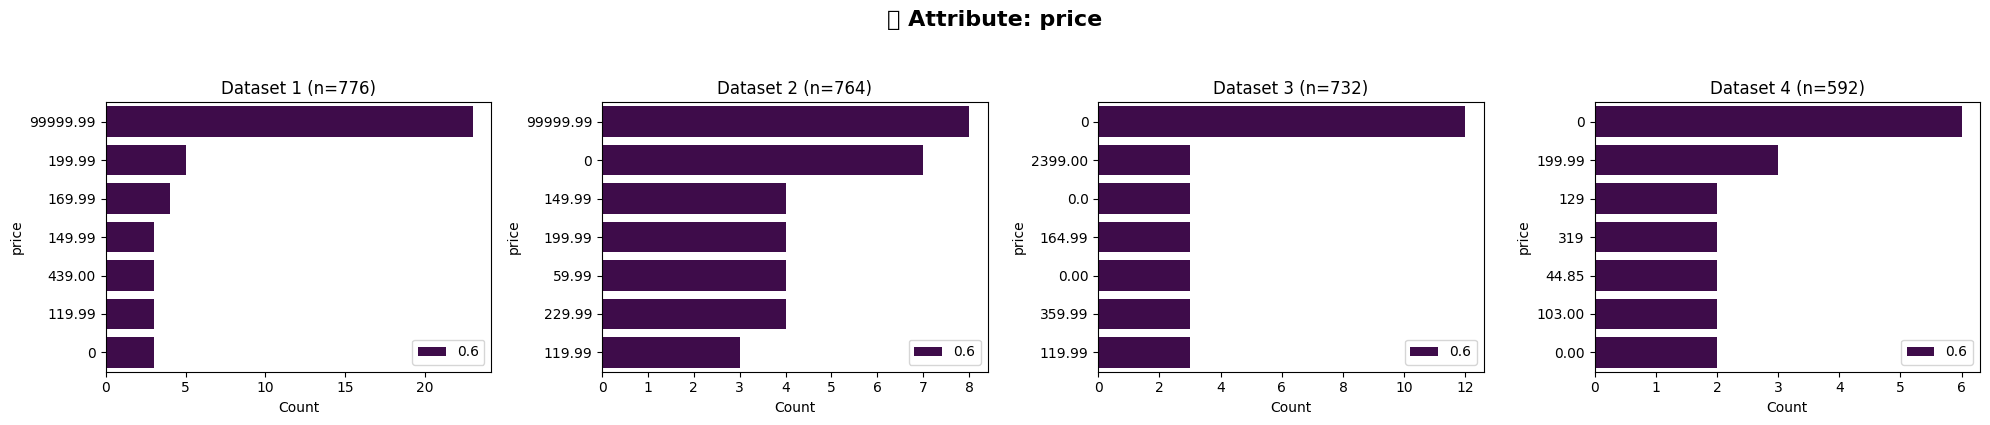

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


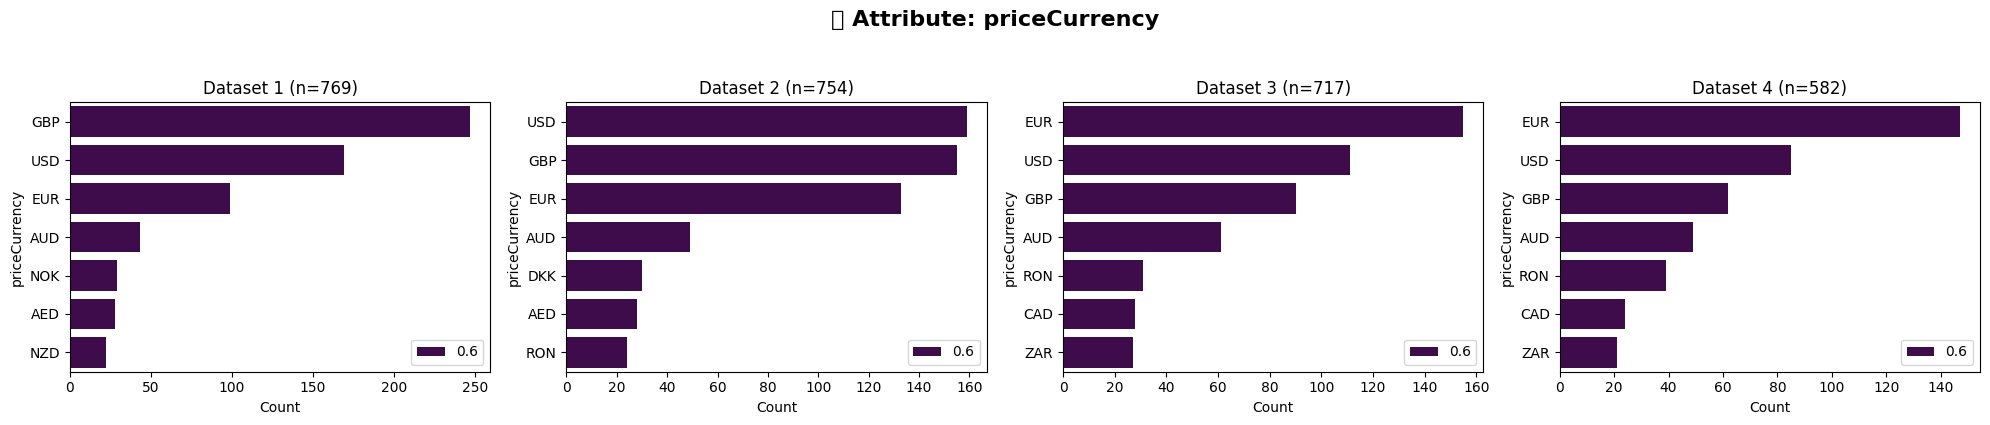

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


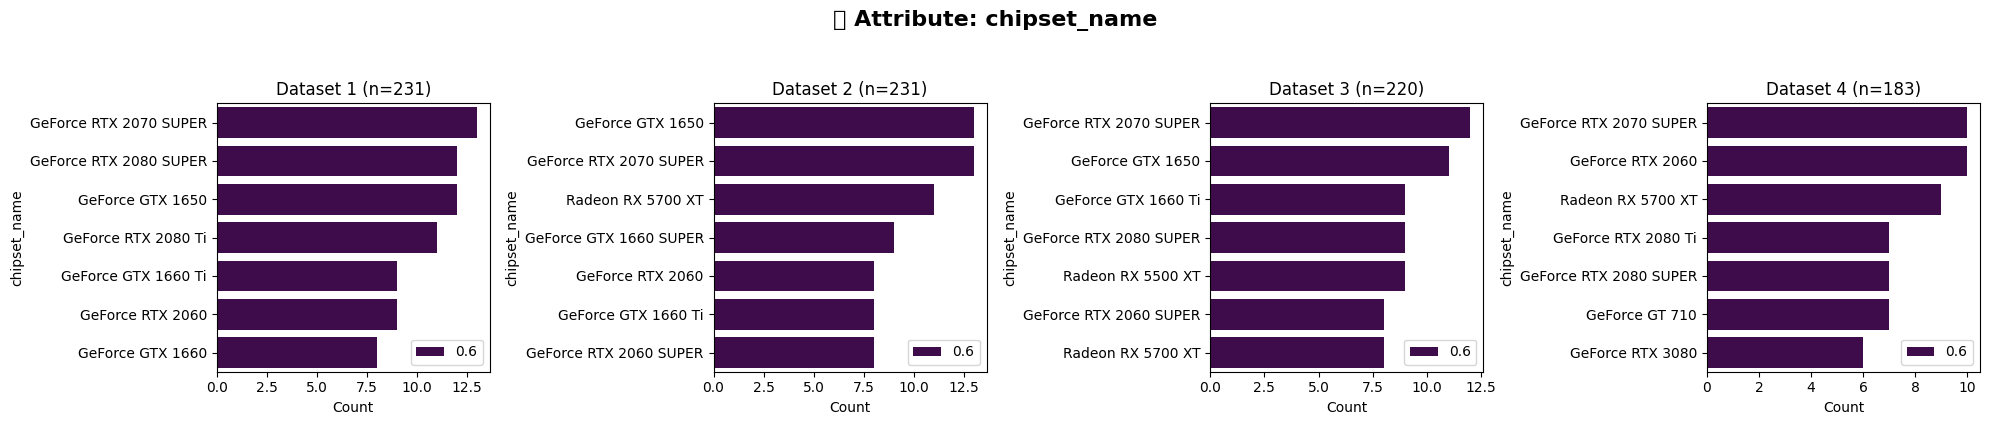

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


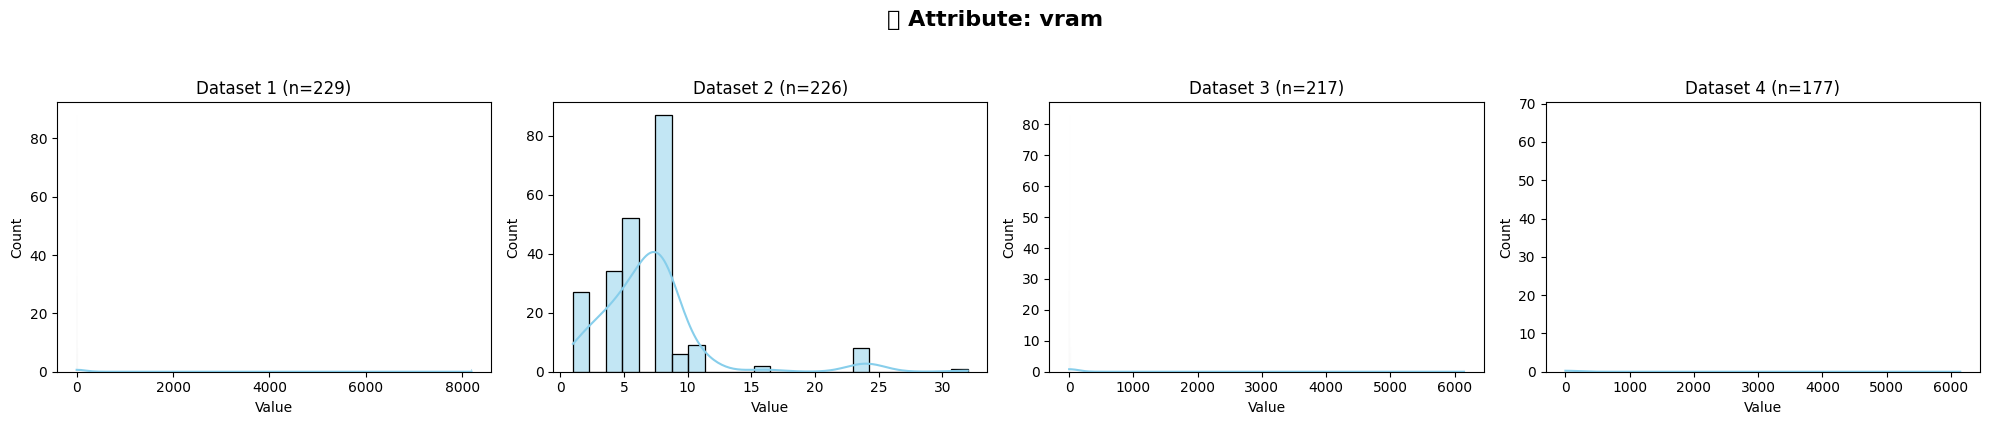

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


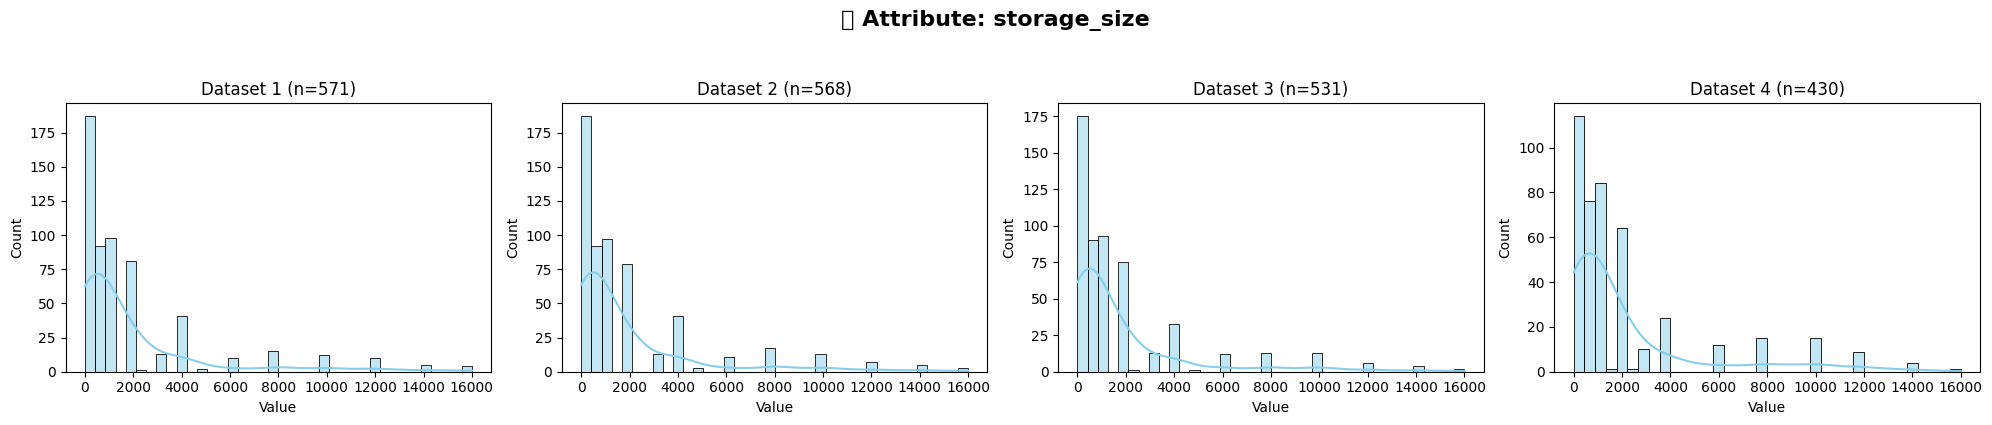

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


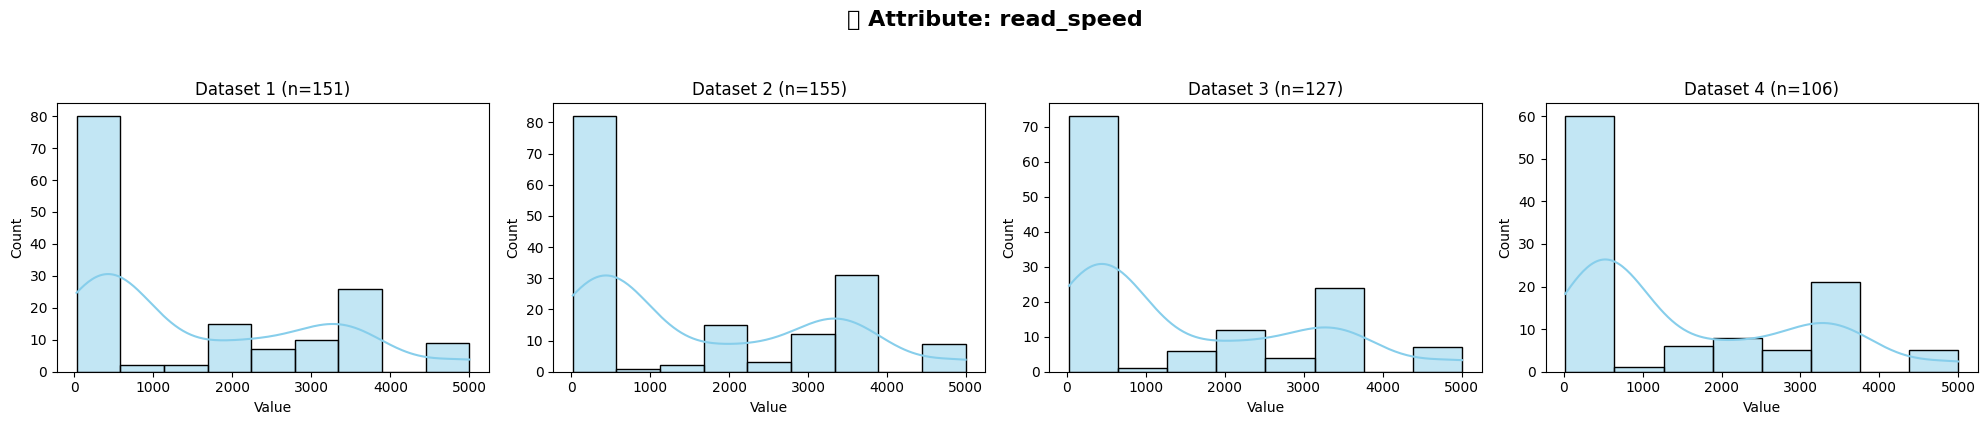

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


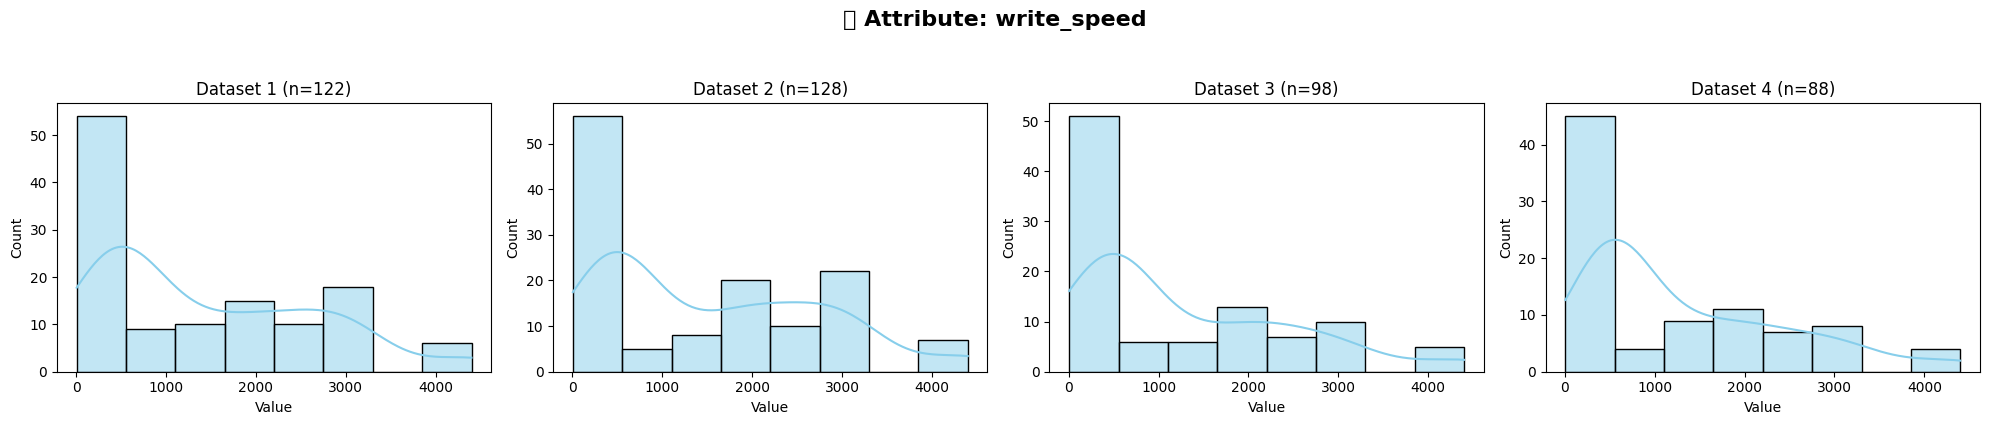

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


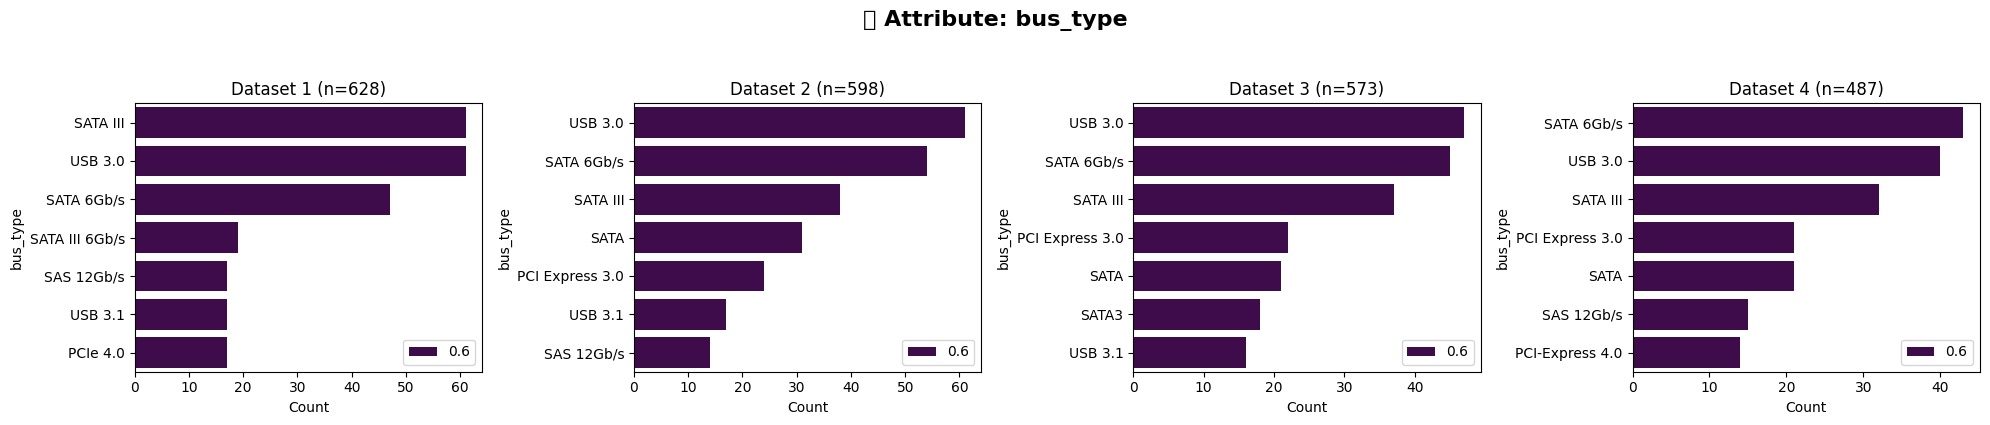

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


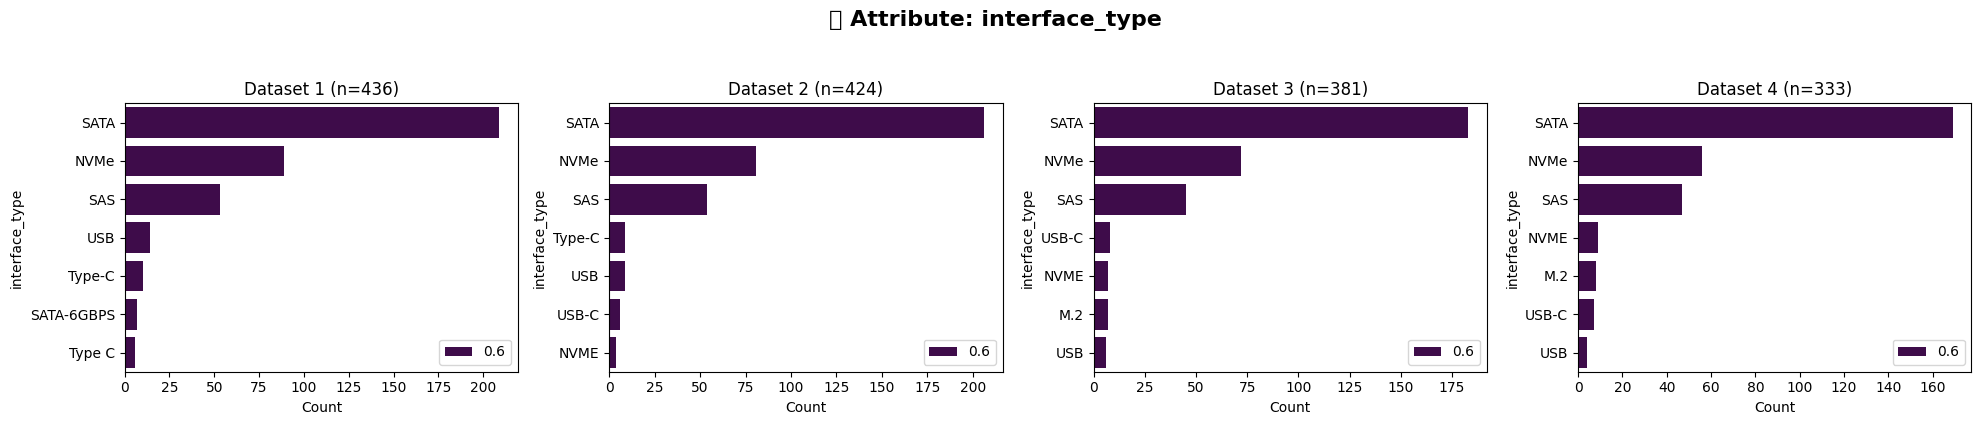

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


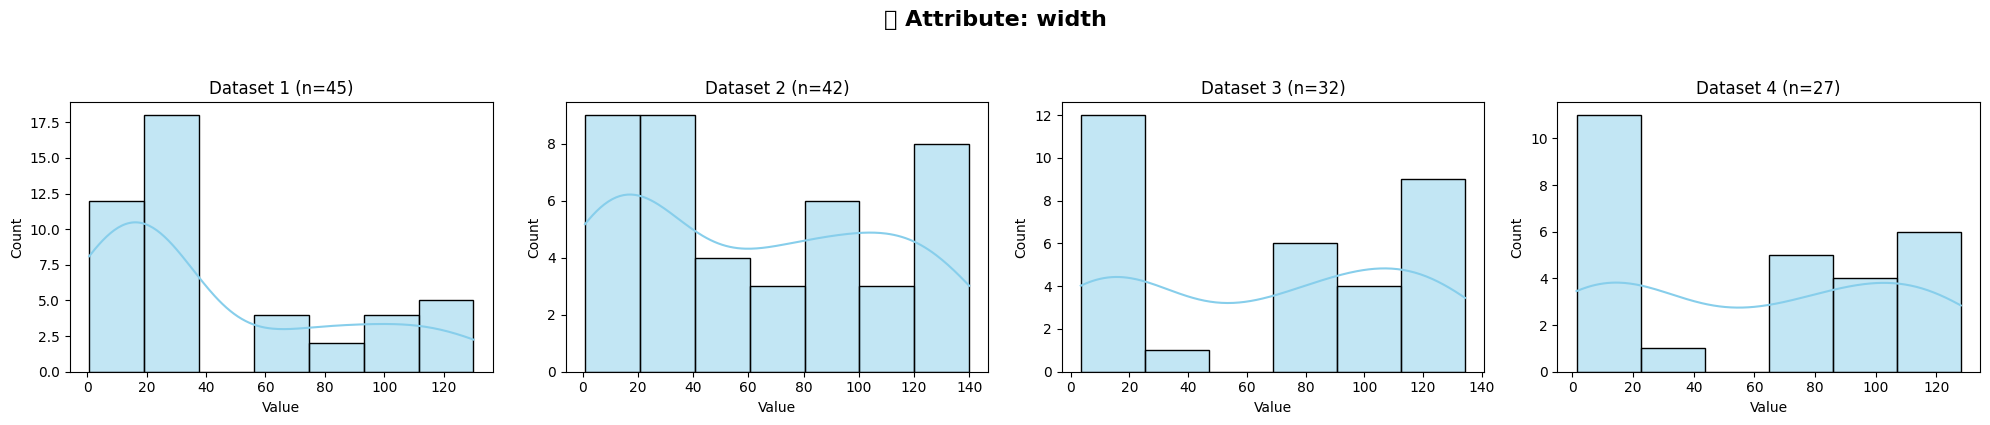

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


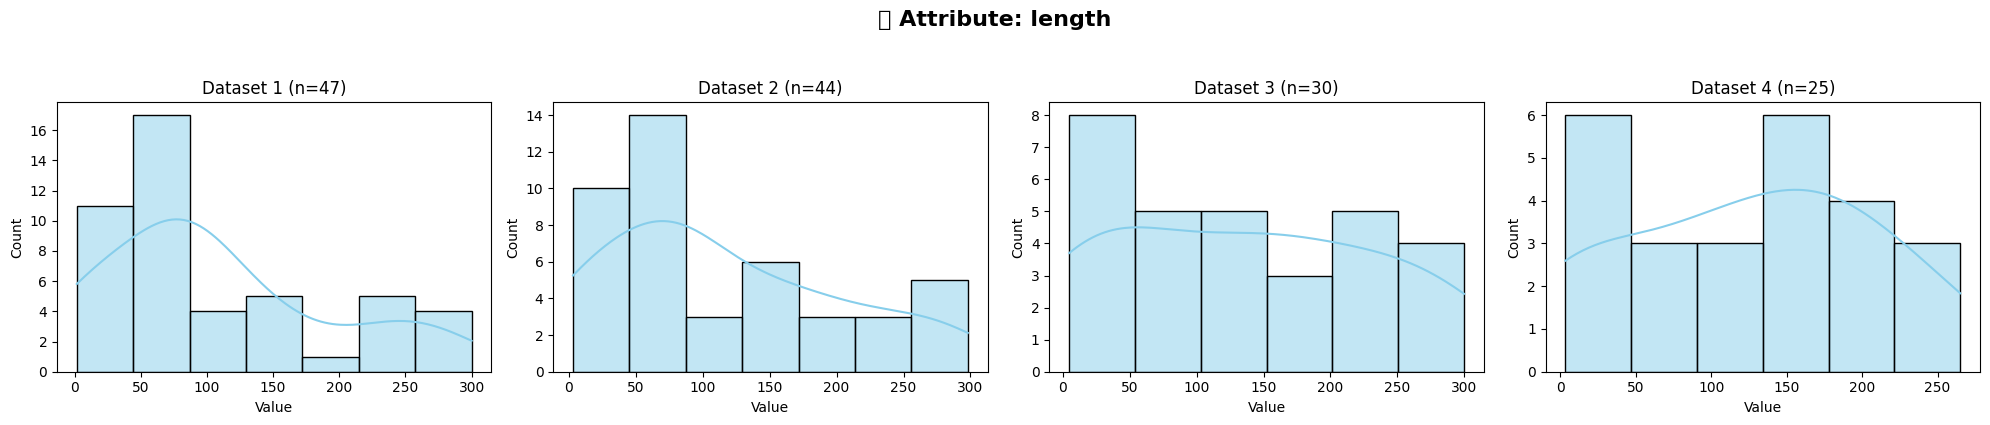

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


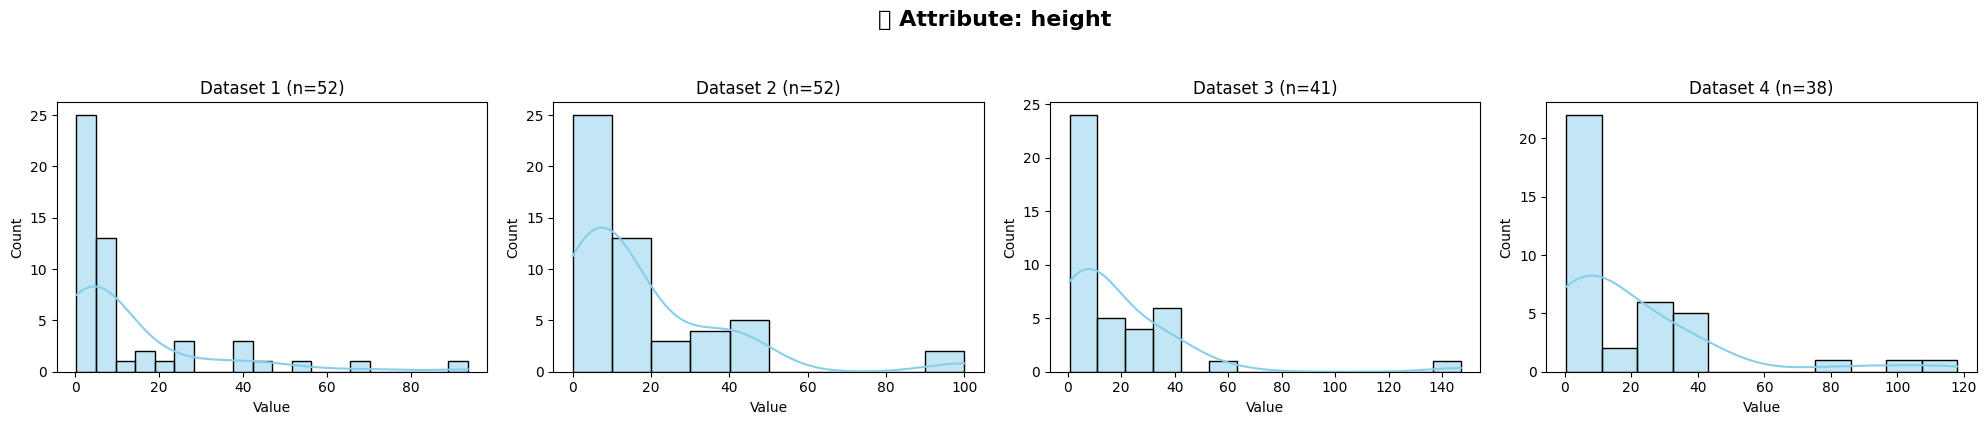

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


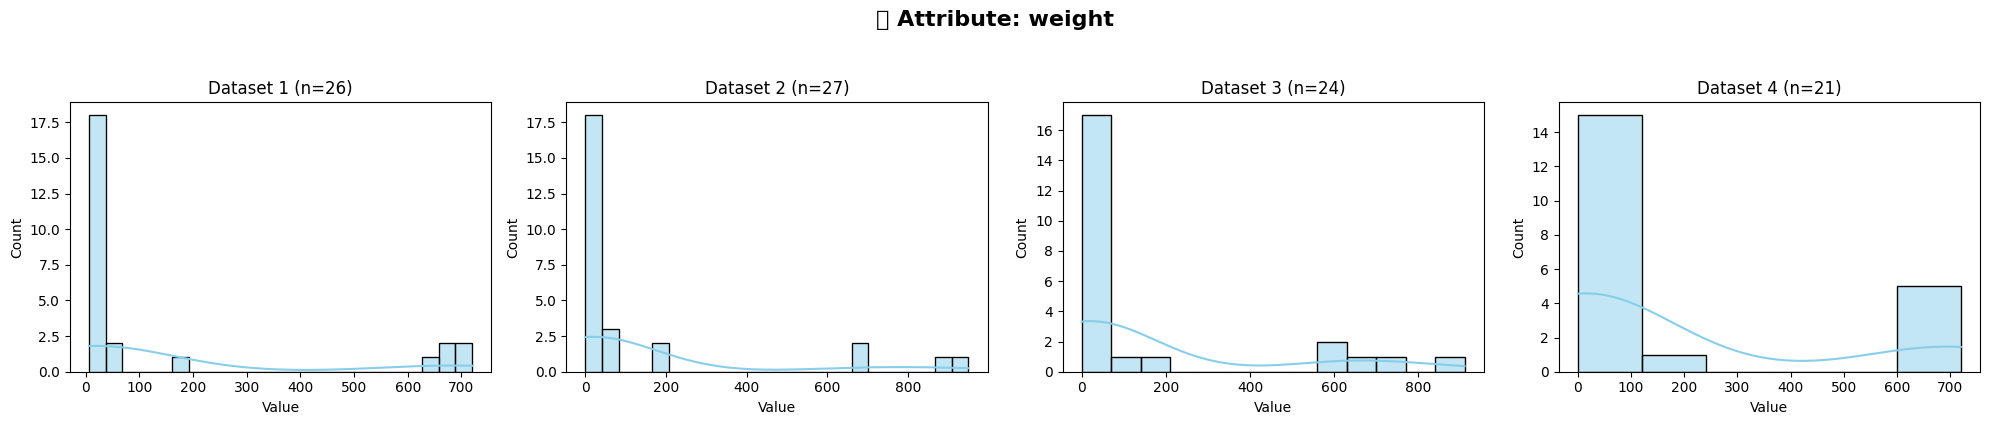

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


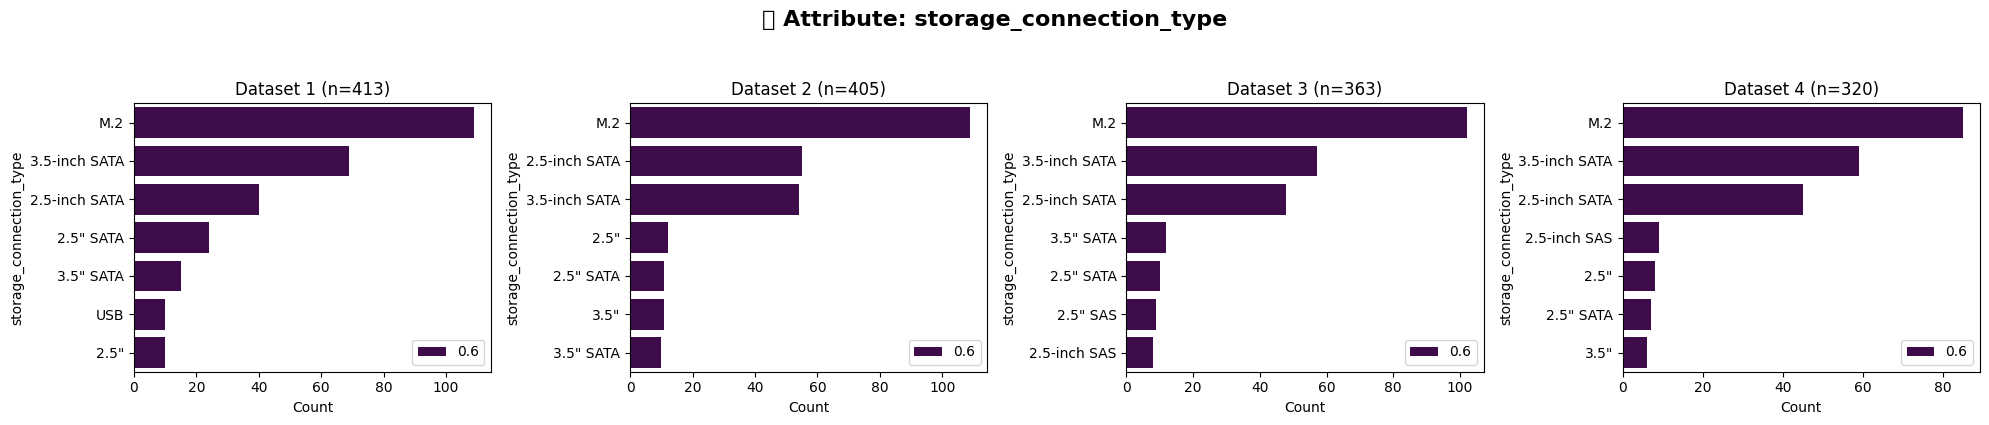

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


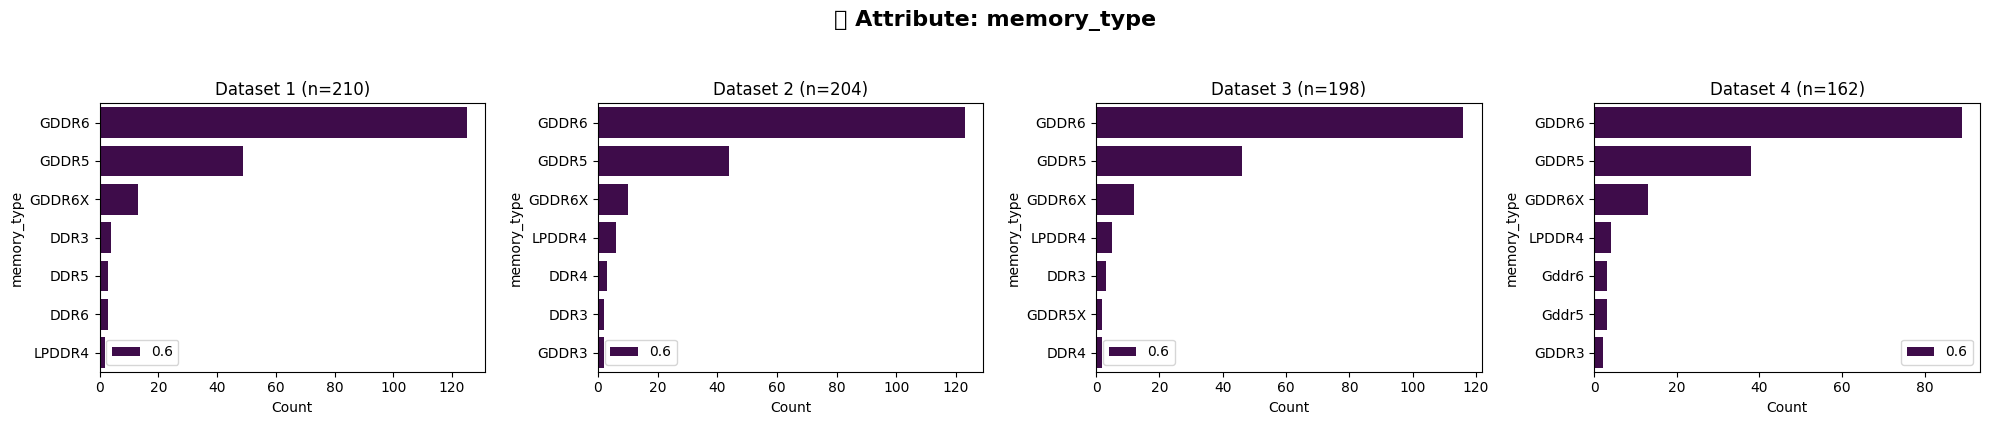

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


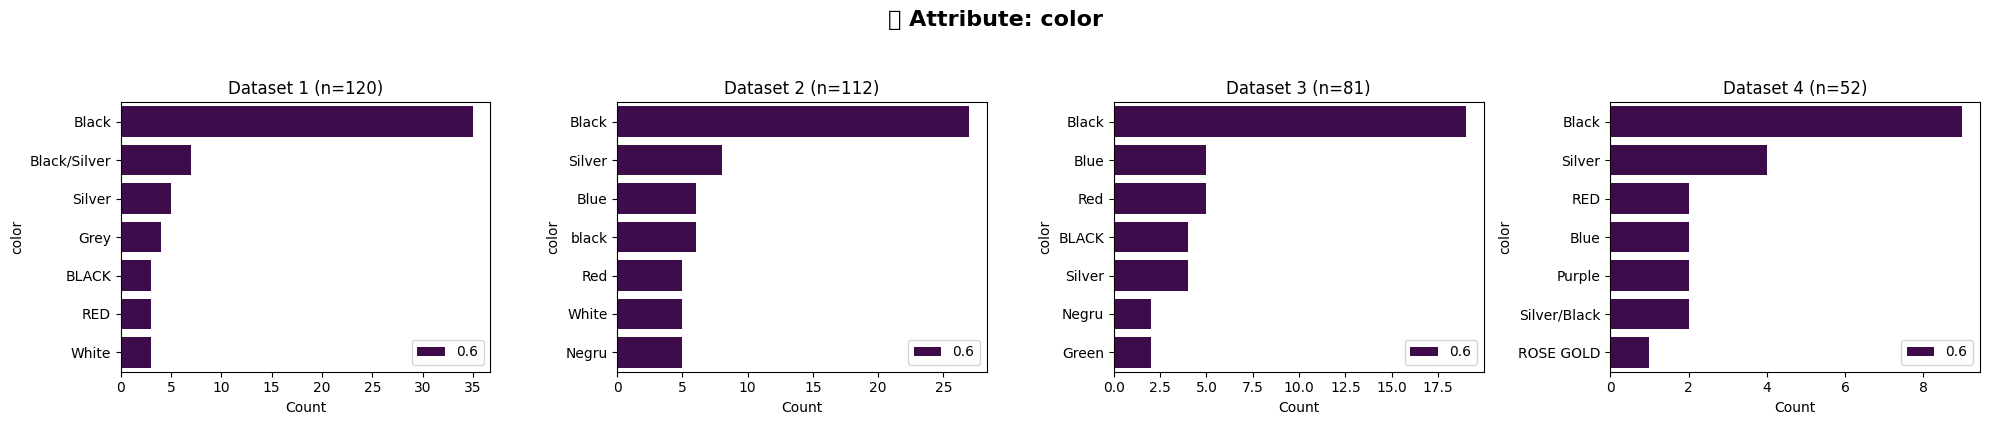

C:\Users\hussa\AppData\Local\Temp\ipykernel_26520\3371065262.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hussa\anaconda3\envs\hiwi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


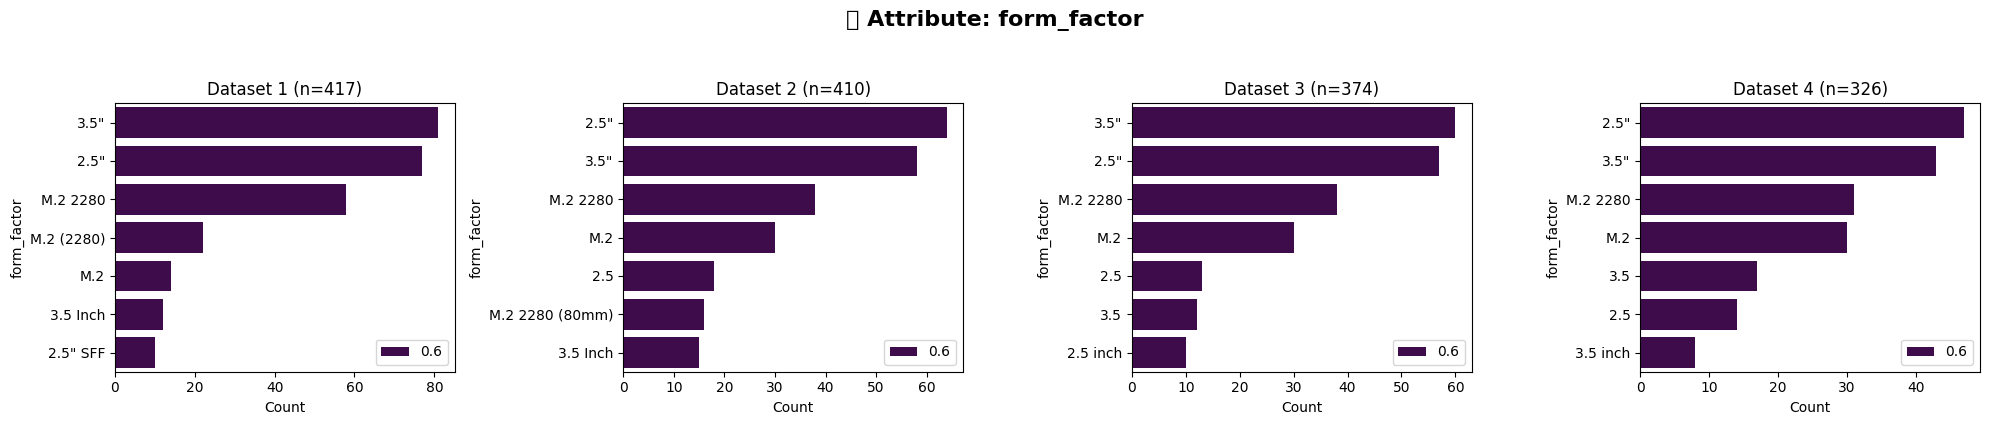

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_mini_distributions(datasets, attributes):
    """
    Plots a row of 4 mini-distributions for each attribute.
    """
    for attr in attributes:
        # Check if column exists in at least one dataset
        if not any(attr in df.columns for df in datasets):
            continue
            
        fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
        fig.suptitle(f"🔍 Attribute: {attr}", fontsize=16, fontweight='bold', y=1.05)
        
        for i, df in enumerate(datasets):
            ax = axes[i]
            if attr not in df.columns or df[attr].dropna().empty:
                ax.text(0.5, 0.5, "No Data", ha='center', va='center')
                ax.set_title(f"Dataset {i+1}")
                continue
            
            data = df[attr].dropna()
            
            # Determine if numeric or categorical
            if pd.api.types.is_numeric_dtype(data):
                sns.histplot(data, kde=True, ax=ax, color='skyblue')
                ax.set_xlabel("Value")
            else:
                # Show top 7 categories to prevent overcrowding
                top_cats = data.value_counts().head(7)
                sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax, palette='viridis',hue=0.6)
                ax.set_xlabel("Count")
            
            ax.set_title(f"Dataset {i+1} (n={len(data)})")
        
        plt.tight_layout()
        plt.show()

# List of attributes to check
check_list = [     
    'price', 'priceCurrency', 'chipset_name', 'vram', 'storage_size',
    'read_speed', 'write_speed', 'bus_type', 'interface_type',
    'width', 'length', 'height', 'weight', 
    'storage_connection_type', 'memory_type', 'color', 'form_factor'
]

# Run the visualization
plot_mini_distributions(brand_normalized_datasets_list, check_list)

In [110]:
attributes_to_check = [
    'height', 'width', 'length', 'weight',
    'storage_size', 'write_speed', 'read_speed'
]

for attr in attributes_to_check:
    print(f"\n🔍 Attribute: {attr}")
    print("-" * 70)
    
    for name, df in brand_normalized_datasets.items():
        if attr not in df.columns:
            print(f"   {name}: Not present")
            continue
            
        col_data = df[attr].dropna()
        if col_data.empty:
            print(f"   {name}: Empty")
            continue
                
            # Get samples (unique values to see formatting)
        samples = col_data.astype(str).unique()[:5]
        
        if pd.api.types.is_numeric_dtype(col_data):
            stats = col_data.describe()
            print(f"   {name} | Numeric | Min: {stats['min']:8.2f} | Max: {stats['max']:8.2f} | Mean: {stats['mean']:8.2f}")
        else:
            print(f"   {name} | String  | Unique Count: {col_data.nunique()}")
        
        print(f"             Samples: {samples}")


🔍 Attribute: height
----------------------------------------------------------------------
   Extracted_Products_1_brand_Normalized | Numeric | Min:     0.29 | Max:    93.50 | Mean:    12.90
             Samples: ['40.5' '6.1' '1.6' '7.0' '3.5']
   Extracted_Products_2_brand_Normalized | Numeric | Min:     0.10 | Max:   100.00 | Mean:    17.81
             Samples: ['46.0' '10.5' '11.4' '3.5' '1.9']
   Extracted_Products_3_brand_Normalized | Numeric | Min:     0.70 | Max:   147.00 | Mean:    18.47
             Samples: ['1.49' '42.05' '0.8200000000000001' '20.0' '14.7']
   Extracted_Products_4_brand_Normalized | Numeric | Min:     0.40 | Max:   118.00 | Mean:    20.85
             Samples: ['7.0' '80.0' '6.7' '41.0' '40.0']

🔍 Attribute: width
----------------------------------------------------------------------
   Extracted_Products_1_brand_Normalized | Numeric | Min:     0.69 | Max:   130.00 | Mean:    42.58
             Samples: ['122.02' '22.0' '7.22' '9.2' '21.2']
   Extracted_P

In [113]:
#check rows where weight is above 900
ds_list = list(brand_normalized_datasets.values())

df_filtered = ds_list[0][ds_list[1]['weight'] < 1] #to check if grams

#display and print count of such rows
print(f"Rows with weight < 1: {len(df_filtered)}")
display(df_filtered[['title_description', 'weight']])

#save all rows not exceeding 1 weight from all datasets to a json for review
# filtered_dfs = []
# for df in df_after_dropping:
#     filtered = df[df['weight'] < 1]
#     filtered_dfs.append(filtered)
# # Concatenate all filtered dataframes
# final_filtered = pd.concat(filtered_dfs, ignore_index=True) 
# final_filtered.to_json(OUTPUT_DIR / "informationextraction_then_dropped_columns" / "products_weight_below_1.json", orient="records", indent=2)  



Rows with weight < 1: 6


,title_description,weight
108,"Gigabyte GTX 1050 Ti OC 4G Graphics Card. Description: The WINDFORCE 2X cooling system features two 80mm unique blade fans and semi-passive 3D active fan together delivering an effective heat dissipation capacity for higher performance at lower temperatures.80mm Unique Blade Fan DesignThe airflow is spilt by the triangle fan edge, and guided smoothly through the 3D stripe curve on the fan surface, effectively enhancing the air flow.3D Active FanThe semi-passive fans will remain off when the GPU is under a set loading or temperature for low power gaming. It allows gamers to enjoy gameplay in complete silence when the system is running light or idle.One-click Super overclockingWith a simple click on XTREME engine utility, gamers can easily tune the card to meet their various gaming requirements without any overclocking knowledge, while saving the hassle of manual adjustment.Ultra CoolingLower RDS(on) MOSFETs are specially designed to produce lower switching resistance for faster electric current charging and discharging at extremely low temperature.Low Power LossMetal Choke hold energy much longer than common iron-core chokes at high frequency, thus effectively reduce core energy loss and EMI interference.Longer LifeLower ESR Solid Capacitors ensure better electronic conductivity for excellent system performance and longer lifespan.Powered by GeForce GTX 1050 TiIntegrated with 4GB GDDR5 128bit memoryWINDFORCE 2X with Blade Fan DesignSupport up to 8K display @60Hz",NaN
133,"WD 4TB Black 3.5"" SATA 6Gb/s 7200RPM 256MB Hard Drive. Description: WD 4TB Black 3.5"" SATA 6Gb/s 7200RPM 256MB Hard Drive",NaN
344,"Seagate SkyHawk AI ST14000VE0008 14TB 7200 RPM 256MB Cache SATA 6.0Gb/s 3.5\"" Internal Hard Drive. Description: SkyHawk AI features ImagePerfect AI firmware for superior image integrity for random read 24×7 workloadsGet scalable support for up to 16 AI streams while recording up to 64 HD video camera streamsSeamlessly tackle data-intensive footage with SkyHawk’s workload rating of 550TB/year—that’s more than 3× higher than standard surveillance-optimized drivesBenefit from improved total cost of ownership (TCO) with 1 5M MTBF",NaN
528,"SAMSUNG 970 EVO PLUS M.2 2280 500GB PCIe Gen 3.0 x4, NVMe 1.3 V-NAND 3-bit MLC Internal Solid State Drive (SSD) MZ-V7S500B/AM. Description: SAMSUNG 970 EVO PLUS M.2 2280 500GB PCIe Gen 3.0 x4, NVMe 1.3 V-NAND 3-bit MLC Internal Solid State Drive (SSD) MZ-V7S500B/AM",NaN
606,Western Digital WD BLACK SN750 NVMe M.2 2280 2TB PCI-Express 3.0 x4 64-layer 3D NAND Internal Solid State Drive (SSD) WDS200T3XHC W/ Heatsink. Description: Western Digital WD BLACK SN750 NVMe M.2 2280 2TB PCI-Express 3.0 x4 64-layer 3D NAND Internal Solid State Drive (SSD) WDS200T3XHC W/ Heatsink,NaN
750,Corsair Flash Voyager Slider X1 128GB USB 3.0 Flash Drive - Capless Design Read 130MBs Plug and Play. Description: Corsair Flash Voyager Slider X1 128GB USB 3.0 Flash Drive - Capless Design Read 130MBs Plug and Play,NaN


In [119]:
import pandas as pd

WEIGHT_RANGES = {
    "USB_STICK": (3, 60),     # raised to include heavier custom drives
    "SSD": (5, 300),
    "HDD": (100, 2000),       # raised to include large desktop HDDs
    "GPU": (150, 2000)        # lowered to include low-profile cards
}

KG_THRESHOLD = {
    "USB_STICK": 60,
    "SSD": 300,
    "HDD": 2000,
    "GPU": 2000
}

OZ_RANGES = {
    "USB_STICK": (0.1, 2),
    "SSD":       (0.5, 5),
    "HDD":       (10, 40),    # raised to include heavier enterprise HDDs in oz
    "GPU":       (5, 75),     # lowered to include light low-profile cards in oz
}
OZ_TO_G = 28.3495

def convert_weight_to_grams(weight, product_type):
    weight = float(weight)
    gram_low, gram_high = WEIGHT_RANGES.get(product_type, (0, float("inf")))

    # 1. Already valid grams
    if gram_low <= weight <= gram_high:
        return weight

    # 2. Likely kg — try any value under 10 first
    if 0 < weight < 10:
        converted = weight * 1000
        if gram_low <= converted <= gram_high:
            return converted

    # 3. Likely oz
    oz_low, oz_high = OZ_RANGES.get(product_type, (0, 0))
    if oz_low <= weight <= oz_high:
        converted = weight * OZ_TO_G
        if gram_low <= converted <= gram_high:
            return converted

    # 4. Nothing worked
    return weight


def check_range(weight, product_type):
    if product_type not in WEIGHT_RANGES:
        return None
    low, high = WEIGHT_RANGES[product_type]
    return low <= weight <= high


def dry_run_weight_check(df):
    df = df.copy()

    has_weight = df["weight"].notna()
    known_type = df["product_type"].isin(WEIGHT_RANGES.keys())
    mask = has_weight & known_type

    print(f"Total rows:                    {len(df)}")
    print(f"Rows with weight + known type: {mask.sum()}")
    print(f"Rows skipped (null/unknown):   {(~mask).sum()}\n")

    df_check = df[mask].copy()

    # Convert
    df_check["weight_converted"] = df_check.apply(
        lambda row: convert_weight_to_grams(row["weight"], row["product_type"]), axis=1
    )

    # Validate
    df_check["valid_weight"] = df_check.apply(
        lambda row: check_range(row["weight_converted"], row["product_type"]), axis=1
    )

    valid   = df_check["valid_weight"].sum()
    invalid = (~df_check["valid_weight"]).sum()

    print(f"Valid weights after conversion:   {valid} ({valid/len(df_check):.2%})")
    print(f"Invalid weights after conversion: {invalid} ({invalid/len(df_check):.2%})")

    if invalid > 0:
        print("\n⚠️ Invalid rows (manual inspection needed):")
        display(df_check[~df_check["valid_weight"]][
            ["brand", "product_type", "weight", "weight_converted", "title"]
        ].head(10))

    df.loc[mask, "weight_converted"] = df_check["weight_converted"]
    df.loc[mask, "valid_weight"]     = df_check["valid_weight"]

    


dry_run_weight_check(brand_normalized_datasets_list[3])

Total rows:                    626
Rows with weight + known type: 21
Rows skipped (null/unknown):   605

Valid weights after conversion:   21 (100.00%)
Invalid weights after conversion: 0 (0.00%)


### Step 2: Normalizing Weight

In [121]:
def apply_weight_normalization(df):
    """
    Applies weight conversion in-place on the actual weight column.
    Nulls out weights that couldn't be converted (still invalid after all attempts).
    """
    df = df.copy()

    has_weight = df["weight"].notna()
    known_type = df["product_type"].isin(WEIGHT_RANGES.keys())
    mask = has_weight & known_type

    # Convert
    df.loc[mask, "weight"] = df[mask].apply(
        lambda row: convert_weight_to_grams(row["weight"], row["product_type"]), axis=1
    )

    # Null out anything still outside valid range after conversion
    still_invalid = mask & df.apply(
        lambda row: not check_range(row["weight"], row["product_type"])
        if row["product_type"] in WEIGHT_RANGES else False,
        axis=1
    )

    nulled = still_invalid.sum()
    df.loc[still_invalid, "weight"] = None

    print(f"✅ Weight normalization applied to {mask.sum()} rows")
    print(f"🚫 Nulled out {nulled} rows that could not be converted")

    return df

# Apply to all datasets
brand_adnd_weight_normalized_datasets = [
    apply_weight_normalization(df) for df in brand_normalized_datasets_list
]

# Verify
for i, df in enumerate(brand_adnd_weight_normalized_datasets, start=1):
    valid = df[df["weight"].notna() & df["product_type"].isin(WEIGHT_RANGES.keys())]
    print(f"\nDataset {i} — {len(valid)} rows with weight after normalization")

✅ Weight normalization applied to 26 rows
🚫 Nulled out 0 rows that could not be converted
✅ Weight normalization applied to 27 rows
🚫 Nulled out 0 rows that could not be converted
✅ Weight normalization applied to 24 rows
🚫 Nulled out 0 rows that could not be converted
✅ Weight normalization applied to 21 rows
🚫 Nulled out 0 rows that could not be converted

Dataset 1 — 26 rows with weight after normalization

Dataset 2 — 27 rows with weight after normalization

Dataset 3 — 24 rows with weight after normalization

Dataset 4 — 21 rows with weight after normalization


**we normalize storage integer values so that all are in GBs**

### Step 3: Normalizing Storage

In [122]:
import numpy as np

def normalize_storage_with_report(df, dataset_name="Dataset"):
    # 1. Store original values for comparison
    original_series = df['storage_size'].copy()
    
    # 2. Define the normalization logic
    def convert_units(row):
        size = row['storage_size']
        p_type = str(row['product_type']).upper().strip() # Added strip() for safety
        
        if pd.isna(size) or size <= 0:
            return size
            
        # Logic: Multiply by 1000 if it's not a USB and below 64 (TB threshold)
        if p_type != 'USB_STICK' and size < 64:
            return size * 1000
        return size

    # 3. Apply the transformation
    df['storage_size'] = df.apply(convert_units, axis=1)
    
    # 4. Identify changed rows
    changed_mask = ~np.isclose(original_series.fillna(-1), df['storage_size'].fillna(-1))
    df_changed = df[changed_mask]
    
    # 5. Print the Report
    print(f"\n📊 Normalization Report for {dataset_name}:")
    print(f"   - Total rows: {len(df)}")
    print(f"   - Rows changed: {len(df_changed)}")
    
    if len(df_changed) > 0:
        print("   - Sample of changes:")
        comparison = pd.DataFrame({
            'Original': original_series[changed_mask],
            'Normalized': df['storage_size'][changed_mask],
            'Product_Type': df['product_type'][changed_mask]
        }).head(5)
        print(comparison)
    
    return df

# Initialize your new list
brand_storage_normalized_datasets = []

for i, df in enumerate(brand_adnd_weight_normalized_datasets, start=1):
    norm_df = normalize_storage_with_report(df.copy(), dataset_name=f"products_{i}")
    brand_storage_normalized_datasets.append(norm_df)

print(f"\n✅ Created 'brand_storage_normalized_datasets' list with {len(brand_storage_normalized_datasets)} DataFrames.")




📊 Normalization Report for products_1:
   - Total rows: 812
   - Rows changed: 42
   - Sample of changes:
    Original  Normalized Product_Type
1        6.0      6000.0          HDD
17       1.0      1000.0          HDD
34       1.8      1800.0          HDD
65       1.2      1200.0          HDD
68       1.0      1000.0          SSD

📊 Normalization Report for products_2:
   - Total rows: 812
   - Rows changed: 44
   - Sample of changes:
    Original  Normalized Product_Type
32       4.0      4000.0          HDD
72       1.0      1000.0          SSD
88       1.0      1000.0          SSD
93       6.0      6000.0          HDD
98       1.0      1000.0          SSD

📊 Normalization Report for products_3:
   - Total rows: 762
   - Rows changed: 45
   - Sample of changes:
    Original  Normalized Product_Type
1       6.00      6000.0          HDD
12      1.00      1000.0          SSD
48      4.00      4000.0          HDD
55      3.84      3840.0          SSD
76      2.00      2000.0         

In [123]:
for i, df in enumerate(brand_storage_normalized_datasets, start=1):
    print(f"\n✅ Audit for Dataset {i}:")
    
    # Check if we still have any "TB-looking" numbers in HDD/SSD
    tb_range = df[(df['product_type'].isin(['HDD', 'SSD'])) & (df['storage_size'] < 64)]
    
    if tb_range.empty:
        print("  - Success: No HDD/SSDs left in the 1GB-64GB 'TB-limbo' range.")
    else:
        print(f"  - Warning: {len(tb_range)} rows still have small storage values.")
        display(tb_range[['brand', 'storage_size', 'title']].head(5))

    # Show the most common sizes to ensure they look like GB
    print("  - Top 5 Storage Capacities (GB):")
    print(df[df['product_type'].isin(['HDD', 'SSD'])]['storage_size'].value_counts().head(5))


✅ Audit for Dataset 1:
  - Success: No HDD/SSDs left in the 1GB-64GB 'TB-limbo' range.
  - Top 5 Storage Capacities (GB):
storage_size
1000.0    97
2000.0    76
500.0     47
4000.0    39
8000.0    19
Name: count, dtype: int64

✅ Audit for Dataset 2:
  - Success: No HDD/SSDs left in the 1GB-64GB 'TB-limbo' range.
  - Top 5 Storage Capacities (GB):
storage_size
1000.0     95
2000.0     76
500.0      48
4000.0     39
10000.0    19
Name: count, dtype: int64

✅ Audit for Dataset 3:
  - Success: No HDD/SSDs left in the 1GB-64GB 'TB-limbo' range.
  - Top 5 Storage Capacities (GB):
storage_size
1000.0     92
2000.0     68
500.0      46
4000.0     32
10000.0    18
Name: count, dtype: int64

✅ Audit for Dataset 4:
  - Success: No HDD/SSDs left in the 1GB-64GB 'TB-limbo' range.
  - Top 5 Storage Capacities (GB):
storage_size
1000.0     73
2000.0     61
500.0      41
4000.0     20
10000.0    16
Name: count, dtype: int64


In [124]:
for i, df in enumerate(brand_storage_normalized_datasets):
    # Create a mask where the new value is different from the original
    # We use np.isclose for floats to handle tiny precision differences
    changed_mask = ~np.isclose(df_after_dropping[i]['storage_size'].fillna(-1), 
                               df['storage_size'].fillna(-1))
    
    # Extract the changed rows
    df_changes = df[changed_mask].copy()
    
    if not df_changes.empty:
        # Add the original value back in just for viewing
        df_changes['original_size'] = df_after_dropping[i].loc[changed_mask, 'storage_size']
        
        print(f"\n👀 Displaying {len(df_changes)} changed rows for Dataset {i+1}:")
        # Displaying key columns to verify the logic
        display(df_changes[['product_type', 'brand', 'original_size', 'storage_size']].head(10))
    else:
        print(f"\nDataset {i+1}: No changes detected.")


👀 Displaying 42 changed rows for Dataset 1:


,product_type,brand,original_size,storage_size
1,HDD,Western Digital,6.0,6000.0
17,HDD,Hewlett Packard Enterprise,1.0,1000.0
34,HDD,Hewlett Packard Enterprise,1.8,1800.0
65,HDD,Hewlett Packard,1.2,1200.0
68,SSD,Patriot,1.0,1000.0
88,SSD,Samsung,1.0,1000.0
93,HDD,Western Digital,6.0,6000.0
118,HDD,Seagate,8.0,8000.0
121,SSD,Samsung,1.0,1000.0
145,SSD,Western Digital,1.0,1000.0



👀 Displaying 44 changed rows for Dataset 2:


,product_type,brand,original_size,storage_size
32,HDD,Seagate,4.00,4000.0
72,SSD,Crucial,1.00,1000.0
88,SSD,Samsung,1.00,1000.0
93,HDD,Western Digital,6.00,6000.0
98,SSD,ADATA,1.00,1000.0
102,HDD,Seagate,10.00,10000.0
114,SSD,ADATA,1.00,1000.0
121,SSD,Samsung,1.00,1000.0
126,SSD,Seagate,1.92,1920.0
128,SSD,ADATA,1.00,1000.0



👀 Displaying 45 changed rows for Dataset 3:


,product_type,brand,original_size,storage_size
1,HDD,Western Digital,6.00,6000.0
12,SSD,ADATA,1.00,1000.0
48,HDD,Seagate,4.00,4000.0
55,SSD,Intel,3.84,3840.0
76,HDD,Seagate,2.00,2000.0
96,SSD,Crucial,1.00,1000.0
114,SSD,Samsung,1.00,1000.0
134,HDD,Western Digital,10.00,10000.0
138,HDD,Seagate,8.00,8000.0
141,SSD,Samsung,1.00,1000.0



👀 Displaying 14 changed rows for Dataset 4:


,product_type,brand,original_size,storage_size
32,SSD,Gigabyte,1.00,1000.0
58,SSD,Samsung,2.00,2000.0
101,SSD,None,1.92,1920.0
121,SSD,Samsung,1.00,1000.0
169,HDD,Seagate,10.00,10000.0
174,SSD,Seagate,2.00,2000.0
207,SSD,Intel,1.00,1000.0
230,SSD,Crucial,1.00,1000.0
255,HDD,Toshiba,16.00,16000.0
307,HDD,Western Digital,12.00,12000.0


In [125]:
limbo_rows = []

for i, df in enumerate(brand_storage_normalized_datasets): #all_datasets_normalized   df_after_dropping
    # Filter for the specific range and product types you mentioned
    mask = (
        (df['product_type'].isin(['HDD', 'SSD'])) & 
        (df['storage_size'] > 8) & 
        (df['storage_size'] < 64)
    )
    
    df_subset = df[mask].copy()
    if not df_subset.empty:
        df_subset['dataset_source'] = f"Dataset {i+1}"
        limbo_rows.append(df_subset)

# Combine them for a single view
if limbo_rows:
    df_limbo = pd.concat(limbo_rows)
    # View the titles and brands to see what these actually are
    print(f"🔍 Found {len(df_limbo)} rows in the 16GB-128GB range for HDDs/SSDs")
    display(df_limbo[['dataset_source', 'brand', 'product_type', 'storage_size', 'title']].sort_values('storage_size'))
else:
    print("No rows found in that specific range.")

No rows found in that specific range.


In [126]:
#check how many hdd and ssds are above 16 and under 120 in the non-normalized datasets
for i, df in enumerate(brand_storage_normalized_datasets, start=1):
    mask = (
        (df['product_type'].isin(['HDD', 'SSD'])) & 
        # (df['storage_size'] > 16) & 
        (df['storage_size'] < 119)
    )
    count = mask.sum()
    print(f"Dataset {i+1}: {count} rows with HDD/SSD storage above 16 GB and below 119 GB before normalization.")
    #print all the rows that are in this range to check if they are actually HDDs or SSDs
    # df_subset = df[mask]
    # display(df_subset)

Dataset 2: 1 rows with HDD/SSD storage above 16 GB and below 119 GB before normalization.
Dataset 3: 1 rows with HDD/SSD storage above 16 GB and below 119 GB before normalization.
Dataset 4: 0 rows with HDD/SSD storage above 16 GB and below 119 GB before normalization.
Dataset 5: 0 rows with HDD/SSD storage above 16 GB and below 119 GB before normalization.


In [127]:
#we check all the usb size unique values are
for i, df in enumerate(brand_storage_normalized_datasets, start=1):
    mask = (df['product_type'] == 'USB_STICK') & (df['storage_size'].notna())
    unique_sizes = df.loc[mask, 'storage_size'].unique()
    print(f"Dataset {i+1} - Unique USB Storage Sizes: {sorted(unique_sizes)}")

Dataset 2 - Unique USB Storage Sizes: [8.0, 16.0, 32.0, 64.0, 128.0, 256.0]
Dataset 3 - Unique USB Storage Sizes: [8.0, 16.0, 32.0, 64.0, 128.0, 256.0]
Dataset 4 - Unique USB Storage Sizes: [8.0, 16.0, 32.0, 64.0, 128.0, 256.0]
Dataset 5 - Unique USB Storage Sizes: [8.0, 16.0, 32.0, 64.0, 128.0, 256.0]


**we check dimensions and power metrics next

In [128]:
attributes_to_normalize = [
    'height', 'width', 'length' ,'write_speed', 'read_speed'
]

print("=" * 60)

for attr in attributes_to_normalize:
    print(f"\n📍 ATTRIBUTE: {attr}")
    
    for i, df in enumerate(brand_storage_normalized_datasets, start=1):
        if attr not in df.columns:
            print(f"  Dataset {i}: '{attr}' column missing.")
            continue
            
        col_data = df[attr].dropna()
        if col_data.empty:
            print(f"  Dataset {i}: No data available for GPUs.")
            continue
            
        # 2. Get all unique values (sorted for readability)
        unique_vals = sorted(col_data.unique().tolist(), key=lambda x: str(x))
        
        # 3. Report
        is_numeric = pd.api.types.is_numeric_dtype(col_data)
        type_label = "Numeric" if is_numeric else "String"
        
        print(f"  Dataset {i} [{type_label}] | Unique Count: {len(unique_vals)}")
        print(f"    Options: {unique_vals}")


📍 ATTRIBUTE: height
  Dataset 1 [Numeric] | Unique Count: 31
    Options: [0.29, 0.4, 0.6000000000000001, 0.7000000000000001, 1.0, 1.56, 1.6, 1.7000000000000002, 10.0, 14.7, 16.5, 19.0, 2.3, 2.38, 2.713, 26.1, 3.5, 3.7, 38.0, 4.0, 40.5, 46.0, 53.0, 6.1, 6.4, 6.8, 69.8, 7.0, 8.8, 9.0, 93.5]
  Dataset 2 [Numeric] | Unique Count: 35
    Options: [0.1, 1.0, 1.1, 1.6, 1.9, 10.0, 10.1, 10.5, 100.0, 11.4, 11.5, 15.0, 16.5, 19.85, 2.15, 2.3, 2.38, 2.4, 26.0, 26.1, 3.5, 36.6, 38.8, 4.0, 40.0, 40.41, 41.0, 42.0, 46.0, 6.1, 6.8, 6.9, 7.0, 8.0, 8.8]
  Dataset 3 [Numeric] | Unique Count: 25
    Options: [0.7000000000000001, 0.8200000000000001, 1.0, 1.49, 14.7, 147.0, 15.6, 16.5, 2.3, 2.38, 2.6, 20.0, 26.1, 3.5, 30.0, 36.0, 39.0, 40.5, 41.0, 42.05, 59.9, 6.7, 7.0, 8.8, 9.0]
  Dataset 4 [Numeric] | Unique Count: 21
    Options: [0.4, 1.0, 1.03, 1.2, 100.0, 118.0, 15.6, 16.5, 2.15, 2.23, 2.38, 26.1, 26.11, 35.3, 40.0, 41.0, 42.0, 5.04, 6.7, 7.0, 80.0]

📍 ATTRIBUTE: width
  Dataset 1 [Numeric] | Uniqu

In [129]:
# Grouping by general category for cleaner reporting
product_groups = {
    'GPU': ['GPU'],
    'STORAGE': ['SSD', 'HDD', 'USB_STICK']
}

attributes_to_check = [
    'height', 'width', 'length', 'write_speed', 'read_speed'
]

print("🕵️ Isolated Product-Type Audit")
print("=" * 60)

for group_name, types in product_groups.items():
    print(f"\n🚀 CATEGORY: {group_name} ({', '.join(types)})")
    print("-" * 40)
    
    for attr in attributes_to_check:
        print(f"\n📍 Attribute: {attr}")
        
        for i, df in enumerate(brand_storage_normalized_datasets, start=1):
            if attr not in df.columns:
                continue
                
            # Filter for this specific group
            mask = df['product_type'].str.upper().str.strip().isin(types)
            data = df.loc[mask, attr].dropna()
            
            if data.empty:
                continue
                
            unique_vals = sorted(data.unique().tolist())
            
            # Identify scale based on data distribution
            data_min, data_max = data.min(), data.max()
            
            print(f"  Dataset {i} | Range: [{data_min}, {data_max}] | Count: {len(unique_vals)}")
            # Show top 5 and bottom 5 if list is long
            if len(unique_vals) > 10:
                print(f"    Values: {unique_vals[:5]} ... {unique_vals[-5:]}")
            else:
                print(f"    Values: {unique_vals}")

🕵️ Isolated Product-Type Audit

🚀 CATEGORY: GPU (GPU)
----------------------------------------

📍 Attribute: height
  Dataset 1 | Range: [1.7000000000000002, 53.0] | Count: 10
    Values: [1.7000000000000002, 2.713, 3.5, 4.0, 14.7, 19.0, 38.0, 40.5, 46.0, 53.0]
  Dataset 2 | Range: [1.9, 46.0] | Count: 7
    Values: [1.9, 6.9, 38.8, 40.0, 40.41, 42.0, 46.0]
  Dataset 3 | Range: [1.49, 59.9] | Count: 9
    Values: [1.49, 14.7, 30.0, 36.0, 39.0, 40.5, 41.0, 42.05, 59.9]
  Dataset 4 | Range: [5.04, 42.0] | Count: 5
    Values: [5.04, 35.3, 40.0, 41.0, 42.0]

📍 Attribute: width
  Dataset 1 | Range: [4.8, 130.0] | Count: 9
    Values: [4.8, 6.9, 9.2, 68.9, 69.0, 113.0, 122.02, 126.0, 130.0]
  Dataset 2 | Range: [1.9, 133.0] | Count: 7
    Values: [1.9, 6.9, 120.58, 124.0, 127.0, 128.0, 133.0]
  Dataset 3 | Range: [4.33, 134.31] | Count: 10
    Values: [4.33, 68.9, 113.0, 114.0, 119.0, 122.02, 129.0, 130.0, 130.89, 134.31]
  Dataset 4 | Range: [1.73, 128.0] | Count: 7
    Values: [1.73, 113.

**closer inspection as some values dont make sense**

In [130]:
def pull_manual_checks(brand_storage_gpu_normalized):
    for i, df in enumerate(brand_storage_gpu_normalized, start=1):
        print(f"\n{'='*30} DATASET {i} SUSPECT RECORDS {'='*30}")
        
        # 1. GPU Dimension Suspects (Likely CM instead of MM)
        # Standard GPUs are > 100mm long and > 30mm thick. 
        # Anything between 1 and 60 is highly suspicious.
        gpu_mask = df['product_type'].str.upper().str.strip() == 'GPU'
        suspect_gpu_dims = df[gpu_mask & (
            (df['height'].between(0.1, 60)) | 
            (df['length'].between(0.1, 60))
        )]
        
        # 2. Storage Speed Suspects (Likely GB/s instead of MB/s)
        storage_mask = df['product_type'].str.upper().str.strip().isin(['SSD', 'HDD', 'USB_STICK'])
        suspect_speeds = df[storage_mask & (
            (df['read_speed'].between(0.1, 25)) | 
            (df['write_speed'].between(0.1, 25))
        )]
        

        # --- Display Results ---
        if not suspect_gpu_dims.empty:
            print(f"\n🚩 GPU Dims in 'CM range' ({len(suspect_gpu_dims)} rows):")
            display(suspect_gpu_dims[['brand', 'product_type', 'height', 'length', 'title']].head(10))

        if not suspect_speeds.empty:
            print(f"\n🚩 Storage Speeds in 'GB/s range' ({len(suspect_speeds)} rows):")
            display(suspect_speeds[['brand', 'product_type', 'read_speed', 'write_speed', 'title']].head(10))

# Run it on your current normalized list
pull_manual_checks(brand_storage_normalized_datasets)


============================== DATASET 1 SUSPECT RECORDS ==============================

🚩 GPU Dims in 'CM range' (12 rows):


,brand,product_type,height,length,title
8,Gigabyte,GPU,40.500,225.65,Gigabyte GeForce GTX 1660 SUPER OC 6GB Dual Fan Graphics Card
38,Asus,GPU,3.500,15.90,ASUS VGA ROG-STRIX-RX5600XT-O6G-GAMING
79,MSI,GPU,19.000,146.00,MSI GeForce GT 710 1GB DDR3 Silent Fanless Low Profile PCI-E Graphics Card
111,Gigabyte,GPU,14.700,149.90,Gigabyte nVidia GeForce GT 1030 2GB DDR5 Fan PCIe Video Card 4K @ 60Hz HDMI DVI 2xDisplays Low Profile 1506/1468 MHz VCG-N1030SL-2GL GV-N1030SL-2GL
166,PNY,GPU,2.713,5.70,"PNY NVIDIA Quadro P1000 GDDR5 4GB/128bit, 640 CUDA Cores, PCI-E 3.0 x16, 4xminiD"
168,Gigabyte,GPU,40.500,225.65,Gigabyte GeForce GTX 1660 Ti OC 6G Graphics Card
382,Asus,GPU,4.000,17.30,Tarjeta Grafica Asus GeForce GT 1030 2GB GDDR5
415,MSI,GPU,46.000,232.00,MSI RADEON RX 5700 XT MECH OC 8GB GDDR6
522,Asus,GPU,1.700,8.50,Asus Geforce Dual GXT 1660Ti O6G 6Gb Gddr6 192Bit
575,Asus,GPU,53.000,242.00,Asus DUAL-GTX1660S-A6G-EVO



🚩 Storage Speeds in 'GB/s range' (8 rows):


,brand,product_type,read_speed,write_speed,title
29,Kingston,USB_STICK,100.0,15.0,Kingston 128GB DataTraveler microDuo USB 3.1 Type-C Flash Drive
46,Kingston,USB_STICK,100.0,10.0,Kingston Data Traveler 100 G3 USB 3.1 Flash Drive Memory Stick 100MB/s- 128GB
221,Kingston,USB_STICK,110.0,15.0,"Kingston 32GB USB 3.0 Data Traveler 50, 110MB/s Read, 15MB/s Write (DT50/32GB)"
235,Kingston,USB_STICK,110.0,15.0,"Stick memorie Kingston USB Flash Drive DT50/64GB- DataTraveler® 50, Speed2 USB 3.1"
305,ADATA,USB_STICK,40.0,20.0,"ADATA USB Drive DashDrive Series UV128 32GB USB 3.0, Black/Blue (AUV128-32G-RBE) - New"
348,Kingston,USB_STICK,40.0,10.0,Kingston Data Traveler 100 G3 USB 3.0 Flash Drive Memory Stick - 16GB
500,Kingston,USB_STICK,100.0,15.0,Kingston 64GB DataTraveler DUO 3C DTDUO3C/64GB USB 3.1 Type-C Flash Drive
591,Kingston,USB_STICK,30.0,5.0,"Memorie USB Kingston USB Flash DriveDataTraveler® 50, 16GB, Speed2 USB 3.1, DT50/16GB"



============================== DATASET 2 SUSPECT RECORDS ==============================

🚩 GPU Dims in 'CM range' (9 rows):


...

,brand,product_type,read_speed,write_speed,title
28,Kingston,USB_STICK,100.0,15.0,Kingston DataTraveler MicroDuo 3C USB Flash Drive 128GB
211,Kingston,USB_STICK,110.0,15.0,Kingston DataTraveler 50 32GB USB 3.0/3.1 Silver and Red USB Flash Drive
281,Patriot,USB_STICK,27.0,25.0,Patriot Xporter 32GB USB2.0 Flash Drive Black
473,Kingston,USB_STICK,100.0,15.0,Kingston 128GB DataTraveler SE9 DTSE9G2/128GB USB 3.0 Flash Drive
475,Kingston,USB_STICK,100.0,15.0,Kingston Technology DataTraveler microDuo 3C 64GB USB flash drive USB Type-A / USB Type-C 3.0 (3.1 Gen 1) Black
557,Kingston,USB_STICK,30.0,5.0,Memorie externa KINGSTON Data Traveler 50 16GB USB 3.1
606,ADATA,USB_STICK,40.0,15.0,Adata 16GB UV128 DashDrive USB 3.0 Flash Drive - Blue
610,ADATA,USB_STICK,90.0,25.0,A-DATA S102 Pro Effortless Upgrade 32GB Titanium Blue Speed USB 3.0 Flash Drive
654,Kingston,USB_STICK,70.0,10.0,Kingston 16GB DataTraveler DUO 3 DTDUO3/16GB USB 3.0 Flash Drive



============================== DATASET 4 SUSPECT RECORDS ==============================

🚩 GPU Dims in 'CM range' (6 rows):


,brand,product_type,height,length,title
72,Zotac,GPU,41.00,209.60,ZOTAC GAMING GEFORCE RTX 2060 TWIN FAN 6GB GDDR6
84,Gigabyte,GPU,40.00,265.00,Gigabyte Geforce RTX 2060 SUPER WINDFORCE OC 8GB Graphics Card
171,MSI,GPU,42.00,204.00,MSI GeForce GTX 1660 VENTUS XS 6G OC 6GB Dual Fan Graphic Card
428,PNY,GPU,5.04,12.36,Placa De Vídeo PNY RTX 2070 Super XLR8 Gaming Overclocked Edition 8GB
493,Zotac,GPU,35.30,158.50,ZOTAC GAMING GEFORCE GTX 1650 SUPER TWIN FAN 4GB GDDR6
620,XFX,GPU,40.00,243.00,"PLACA VIDEO XFX RX 570 8GB ""RX-570P8DFD6"" - Lichidare stoc"



🚩 Storage Speeds in 'GB/s range' (2 rows):


,brand,product_type,read_speed,write_speed,title
178,Kingston,USB_STICK,110.0,15.0,"Memorie USB Kingston USB Flash DriveDataTraveler® 50,32GB,, Speed2 USB 3.1, DT50/32GB"
575,Sandisk,USB_STICK,20.0,5.0,SanDisk 32GB SDIX30C-032G-GN6NN USB 3.0 Flash Drive


**check unique width height and length per product type**

In [131]:
#check unique width height and length per product type (GPU, HDD, SSD, USB_STICK) 
for i, df in enumerate(brand_storage_normalized_datasets, start=1):
    print(f"\n📍 Dataset {i} - Unique Dimensions per Product Type")
    print("=" * 80)
    for p_type in df['product_type'].unique():
        print(f"\n📍 Dataset {i} - Unique Dimensions for {p_type}")
        subset = df[df['product_type'] == p_type]
        for dim in ['height', 'width', 'length']:
            if dim in subset.columns:
                unique_vals = sorted(subset[dim].dropna().unique())
                print(f"   - {p_type} | {dim}: {unique_vals}")


📍 Dataset 1 - Unique Dimensions per Product Type

📍 Dataset 1 - Unique Dimensions for GPU
   - GPU | height: [1.7000000000000002, 2.713, 3.5, 4.0, 14.7, 19.0, 38.0, 40.5, 46.0, 53.0]
   - GPU | width: [4.8, 6.9, 9.2, 68.9, 69.0, 113.0, 122.02, 126.0, 130.0]
   - GPU | length: [5.7, 8.5, 15.9, 16.7, 17.3, 115.0, 146.0, 149.9, 174.0, 225.65, 232.0, 242.0, 254.0, 265.0, 268.0, 287.0, 300.0]

📍 Dataset 1 - Unique Dimensions for HDD
   - HDD | height: [0.6000000000000001, 1.0, 1.56, 1.6, 6.4, 7.0, 16.5, 26.1]
   - HDD | width: [3.0, 4.0, 7.22, 7.57, 78.75, 101.6]
   - HDD | length: [11.87, 119.4, 147.0]

📍 Dataset 1 - Unique Dimensions for SSD
   - SSD | height: [0.7000000000000001, 2.3, 2.38, 3.5, 3.7, 6.1, 6.8, 7.0, 69.8, 93.5]
   - SSD | width: [2.2, 22.0, 22.1, 69.85, 79.0, 100.5]
   - SSD | length: [8.0, 9.0, 80.0, 100.0, 100.2]

📍 Dataset 1 - Unique Dimensions for USB_STICK
   - USB_STICK | height: [0.29, 0.4, 8.8, 9.0, 10.0]
   - USB_STICK | width: [0.6900000000000001, 0.8, 15.9, 20

### Step 4: Normalizing Dimensions

In [132]:
import pandas as pd

# ── Audit log ────────────────────────────────────────────────────────────────
total_audit_log = {
    'GPU_cm_to_mm': 0,
    'GPU_cm_to_mm_post': 0,
    'Storage_inch_to_mm': 0,
    'Storage_cm_to_mm': 0,
    'SSD_subtype_converted': 0,
    'Untouched': 0,
    'GPU_swapped': 0,
    'GPU_bad_height_nulled': 0,
    'SSD_bad_height_nulled': 0,
}

# ── SSD subtype detection ─────────────────────────────────────────────────────
def get_ssd_subtype(row):
    form      = str(row.get('form_factor', '')   or '').upper()
    interface = str(row.get('interface_type', '') or '').upper()
    title     = str(row.get('title', '')          or '').upper()

    if any(x in form or x in title for x in ['M.2', 'M2', 'NGFF', '2280', '2242', '2260']):
        return 'M2'
    if any(x in form or x in title for x in ['2.5', '2.5"', 'SATA']):
        return '2.5'
    if 'NVME' in interface or 'NVME' in title:
        return 'M2'
    return 'UNKNOWN'

# ── SSD dimension ranges (mm) by subtype ─────────────────────────────────────
SSD_DIM_RANGES = {
    'M2': {
        'height': (1.5, 4.0),
        'width':  (20.0, 25.0),
        'length': (40.0, 110.0),
    },
    '2.5': {
        'height': (5.0, 15.0),
        'width':  (60.0, 75.0),
        'length': (90.0, 105.0),
    },
    'UNKNOWN': {
        'height': (1.5, 15.0),
        'width':  (20.0, 75.0),
        'length': (40.0, 110.0),
    }
}

def safe_unit_correction_ssd(val, dim_type, ssd_subtype):
    if pd.isna(val) or val <= 0:
        return val

    low, high = SSD_DIM_RANGES[ssd_subtype][dim_type]

    if low <= val <= high:
        return round(val, 1)

    converted_inch = round(val * 25.4, 1)
    if low <= converted_inch <= high:
        total_audit_log['Storage_inch_to_mm'] += 1
        return converted_inch

    converted_cm = round(val * 10, 1)
    if low <= converted_cm <= high:
        total_audit_log['Storage_cm_to_mm'] += 1
        return converted_cm

    # Return as-is, post-processing will decide
    return round(val, 1)

# ── Main correction function ──────────────────────────────────────────────────
def safe_unit_correction(val, row, dim_type):
    p_type = str(row.get('product_type', '') or '').upper().strip()

    if pd.isna(val) or val <= 0:
        return val

    # --- GPUs ---
    if p_type == 'GPU':
        if dim_type == 'length' and val < 60:
            total_audit_log['GPU_cm_to_mm'] += 1
            return round(val * 10, 1)
        if dim_type in ['height', 'width'] and val < 20:
            total_audit_log['GPU_cm_to_mm'] += 1
            return round(val * 10, 1)

    # --- SSDs (subtype-aware) ---
    elif p_type == 'SSD':
        ssd_subtype = get_ssd_subtype(row)
        total_audit_log['SSD_subtype_converted'] += 1
        return safe_unit_correction_ssd(val, dim_type, ssd_subtype)

    # --- HDD / USB_STICK ---
    elif p_type in ['HDD', 'USB_STICK']:
        if val < 5.0:
            total_audit_log['Storage_inch_to_mm'] += 1
            return round(val * 25.4, 1)
        if 5.0 <= val < 15.0:
            total_audit_log['Storage_cm_to_mm'] += 1
            return round(val * 10, 1)

    total_audit_log['Untouched'] += 1
    return round(val, 1)

# ── Apply to all datasets ─────────────────────────────────────────────────────
br_str_other_normalized = []

for i, df in enumerate(brand_storage_normalized_datasets, start=1):
    df_temp = df.copy()

    # Step 1: unit correction
    for col in ['height', 'width', 'length']:
        if col in df_temp.columns:
            df_temp[col] = df_temp.apply(
                lambda row, c=col: safe_unit_correction(row[c], row, c),
                axis=1
            )

    gpu_mask = df_temp['product_type'] == 'GPU'
    ssd_mask = df_temp['product_type'] == 'SSD'

    # Step 2: fix swapped height/width for GPUs
    swapped = (
        gpu_mask &
        df_temp['height'].notna() &
        df_temp['width'].notna() &
        (df_temp['height'] > df_temp['width'])
    )
    if swapped.sum() > 0:
        df_temp.loc[swapped, ['height', 'width']] = df_temp.loc[swapped, ['width', 'height']].values
        total_audit_log['GPU_swapped'] += swapped.sum()

    # Step 3: null GPU rows where height > 55mm and height < length (bad data)
    bad_gpu_height = (
        gpu_mask &
        df_temp['height'].notna() &
        df_temp['length'].notna() &
        (df_temp['height'] > 55) &
        (df_temp['height'] < df_temp['length'])
    )
    if bad_gpu_height.sum() > 0:
        df_temp.loc[bad_gpu_height, 'height'] = None
        total_audit_log['GPU_bad_height_nulled'] += bad_gpu_height.sum()

    # Step 4: null SSD heights clearly out of range (> 15mm)
    bad_ssd_height = ssd_mask & df_temp['height'].notna() & (df_temp['height'] > 15)
    if bad_ssd_height.sum() > 0:
        df_temp.loc[bad_ssd_height, 'height'] = None
        total_audit_log['SSD_bad_height_nulled'] += bad_ssd_height.sum()

    # Step 5: convert GPU rows still in cm (length < 100mm — too short to be mm)
    # excludes legitimate low-profile cards (length >= 100mm after step 1)
    # Step 5 (revised): convert GPU rows still in cm — detected by height < 20 after step 1
    still_cm = (
        gpu_mask &
        df_temp['height'].notna() &
        (df_temp['height'] < 20) &
        (df_temp['height'] > 5)   # exclude legitimate small values already in mm
    )
    if still_cm.sum() > 0:
        for col in ['height', 'width', 'length']:
            if col in df_temp.columns:
                df_temp.loc[still_cm & df_temp[col].notna(), col] = \
                    (df_temp.loc[still_cm & df_temp[col].notna(), col] * 10).round(1)
        total_audit_log['GPU_cm_to_mm_post'] += still_cm.sum()

    # Step 6: null PNY Quadro-style bad data (length > 400mm is physically impossible)
    bad_length = (
        gpu_mask &
        df_temp['length'].notna() &
        (df_temp['length'] > 400)
    )
    if bad_length.sum() > 0:
        df_temp.loc[bad_length, ['height', 'length']] = None
        total_audit_log['GPU_bad_height_nulled'] += bad_length.sum()

    br_str_other_normalized.append(df_temp)
    print(f"✅ Dataset {i} complete.")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("📊 GLOBAL NORMALIZATION AUDIT SUMMARY")
print("="*50)
print(f"🔹 GPU converted (CM -> MM):        {total_audit_log['GPU_cm_to_mm']}")
print(f"🔹 GPU converted post-process:      {total_audit_log['GPU_cm_to_mm_post']}")
print(f"🔹 GPU height/width swapped:        {total_audit_log['GPU_swapped']}")
print(f"🔹 GPU bad height nulled:           {total_audit_log['GPU_bad_height_nulled']}")
print(f"🔹 SSD bad height nulled:           {total_audit_log['SSD_bad_height_nulled']}")
print(f"🔹 Storage (Inches -> MM):          {total_audit_log['Storage_inch_to_mm']}")
print(f"🔹 Storage (CM -> MM):              {total_audit_log['Storage_cm_to_mm']}")
print(f"🔹 SSD subtype-aware processed:     {total_audit_log['SSD_subtype_converted']}")
print(f"🔹 Untouched (already MM):          {total_audit_log['Untouched']}")
print("="*50)

✅ Dataset 1 complete.
✅ Dataset 2 complete.
✅ Dataset 3 complete.
✅ Dataset 4 complete.

📊 GLOBAL NORMALIZATION AUDIT SUMMARY
🔹 GPU converted (CM -> MM):        29
🔹 GPU converted post-process:      6
🔹 GPU height/width swapped:        5
🔹 GPU bad height nulled:           10
🔹 SSD bad height nulled:           7
🔹 Storage (Inches -> MM):          43
🔹 Storage (CM -> MM):              35
🔹 SSD subtype-aware processed:     185
🔹 Untouched (already MM):          193


In [133]:
for i in range(len(br_str_other_normalized)):
    df = br_str_other_normalized[i]
    print(f"\n📂 DATASET {i+1} VERIFICATION")
    
    gpu_h = df[df['product_type'] == 'GPU']['height'].dropna().unique()
    ssd_h = df[df['product_type'] == 'SSD']['height'].dropna().unique()
    
    print(f"   📍 GPU Height (mm)  : {sorted(gpu_h)}")
    print(f"   📍 SSD Height (mm)  : {sorted(ssd_h)}")


print("🔍 GPU HEIGHT OUTLIER INSPECTION")
print("=" * 80)

for i, df in enumerate(br_str_other_normalized, start=1):
    outliers = df[
        (df['product_type'] == 'GPU') & 
        (df['height'].notna()) & 
        ((df['height'] > 55) | (df['height'] < 20))
    ][['brand', 'title', 'height', 'width', 'length']].copy()
    
    if len(outliers) > 0:
        print(f"\n📂 Dataset {i} — {len(outliers)} suspicious GPU heights:")
        display(outliers)
    else:
        print(f"\n📂 Dataset {i} — ✅ No suspicious GPU heights")    


📂 DATASET 1 VERIFICATION
   📍 GPU Height (mm)  : [27.1, 35.0, 38.0, 40.0, 40.5, 46.0, 53.0]
   📍 SSD Height (mm)  : [0.7, 2.3, 2.4, 3.5, 3.7, 6.1, 6.8, 7.0]

📂 DATASET 2 VERIFICATION
   📍 GPU Height (mm)  : [38.8, 40.0, 40.4, 42.0, 46.0]
   📍 SSD Height (mm)  : [2.1, 2.3, 2.4, 2.5, 3.5, 4.0, 6.1, 6.8, 7.0, 8.0, 10.5, 11.4]

📂 DATASET 3 VERIFICATION
   📍 GPU Height (mm)  : [30.0, 36.0, 39.0, 40.5, 41.0, 42.0]
   📍 SSD Height (mm)  : [2.3, 2.4, 3.5, 7.0]

📂 DATASET 4 VERIFICATION
   📍 GPU Height (mm)  : [35.3, 40.0, 41.0, 42.0]
   📍 SSD Height (mm)  : [2.1, 2.2, 2.4, 7.0]
🔍 GPU HEIGHT OUTLIER INSPECTION

📂 Dataset 1 — ✅ No suspicious GPU heights

📂 Dataset 2 — ✅ No suspicious GPU heights

📂 Dataset 3 — ✅ No suspicious GPU heights

📂 Dataset 4 — ✅ No suspicious GPU heights


**quick check on VRAM**

In [134]:
#check vram unique values across all datatsets br_str_gpu_other_normalized
for i, df in enumerate(br_str_other_normalized, start=1):
    if 'vram' in df.columns:
        unique_vram = sorted(df['vram'].dropna().unique())
        print(f"Dataset {i} - Unique VRAM values: {unique_vram}")
    else:
        print(f"Dataset {i} - 'vram' column missing.")

# The specific outlier values we found
outliers = [1.024, 4096.0, 6144.0, 8192.0]

print("🔍 Investigating VRAM Outlier Rows")
print("=" * 80)

for i, df in enumerate(br_str_other_normalized, start=1):
    # Filter for the specific outlier values
    outlier_df = df[df['vram'].isin(outliers)]
    
    if not outlier_df.empty:
        print(f"\n📍 Dataset {i} - Found {len(outlier_df)} rows:")
        # Displaying columns that will reveal if it's a server/workstation card
        display(outlier_df[['brand', 'title', 'vram', 'product_type']])

Dataset 1 - Unique VRAM values: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0, 8192.0]
Dataset 2 - Unique VRAM values: [1.0, 1.024, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]
Dataset 3 - Unique VRAM values: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0, 6144.0]
Dataset 4 - Unique VRAM values: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0, 4096.0, 6144.0]
🔍 Investigating VRAM Outlier Rows

📍 Dataset 1 - Found 1 rows:


,brand,title,vram,product_type
412,Zotac,Zotac GeForce RTX 2060 SUPER AMP 8192MB GDDR6 PCI-Express Graphics Card |ZT-T20610D-10P,8192.0,GPU



📍 Dataset 2 - Found 1 rows:


,brand,title,vram,product_type
664,EVGA,EVGA GeForce GT 210 Low Profile Passive 1024MB GDDR3 PCI-Express Graphics Card (01G-P3-1313-KR),1.024,GPU



📍 Dataset 3 - Found 1 rows:


,brand,title,vram,product_type
472,Gigabyte,"Placa video GIGABYTE 6144 MB, GDDR5, 192 bit, PCI-E 16x, NVIDIA GeForce GTX 1660, HDMI, DISPLAY PORT",6144.0,GPU



📍 Dataset 4 - Found 2 rows:


,brand,title,vram,product_type
86,Gigabyte,Gigabyte nVidia GTX 1050 Ti OC 4096MB Graphics Card,4096.0,GPU
291,Palit,Palit GeForce GTX 1660Ti StormX 6144MB GDDR6 PCI-Express Graphics Card,6144.0,GPU


### Step 5: Normalizing VRAM

In [135]:
def harmonize_vram(val):
    if pd.isna(val):
        return val
    # If the value is in the 'MB' range (e.g., 1024, 4096, 8192)
    if val >= 128:
        return round(val / 1024, 1)
    # Handle precise binary extractions like 1.024 -> 1.0
    if 1.0 < val < 1.1:
        return round(val)
    return round(val, 1)

print("⚖️ Harmonizing VRAM scales (MB to GB)...")
print("=" * 60)

for df in br_str_other_normalized:
    if 'vram' in df.columns:
        df['vram'] = df['vram'].apply(harmonize_vram)

# Verification Check
for i, df in enumerate(br_str_other_normalized, start=1):
    unique_vram = sorted(df['vram'].dropna().unique())
    print(f"Dataset {i} - Cleaned VRAM: {unique_vram}")

⚖️ Harmonizing VRAM scales (MB to GB)...
Dataset 1 - Cleaned VRAM: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]
Dataset 2 - Cleaned VRAM: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]
Dataset 3 - Cleaned VRAM: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]
Dataset 4 - Cleaned VRAM: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]


### Step 6: Normalizing chipset_name

In [137]:
#check chipset name unique values across all datasets in br_str_other_normalized
for i, df in enumerate(br_str_other_normalized, start=1):
    if 'chipset_name' in df.columns:
        unique_chipsets = sorted(df['chipset_name'].dropna().unique())
        print(f"Dataset {i} - Unique Chipset Names: {unique_chipsets}")
    else:
        print(f"Dataset {i} - 'chipset_name' column missing.")

Dataset 1 - Unique Chipset Names: ['AMD RADEON RX5600 XT', 'AMD RX 570', 'AMD Radeon RX 5500 XT', 'AMD Radeon RX 5700 XT', 'AMD Radeon RX 580', 'GEFORCE RTX 2070 SUPER', 'GTX 1650 SUPER', 'GTX 1650 Super', 'GeForce 210', 'GeForce GT 1030', 'GeForce GT 710', 'GeForce GT 730', 'GeForce GT710', 'GeForce GTX 1050', 'GeForce GTX 1050 Ti', 'GeForce GTX 1650', 'GeForce GTX 1650 SUPER', 'GeForce GTX 1650 Super', 'GeForce GTX 1660', 'GeForce GTX 1660 SUPER', 'GeForce GTX 1660 SUPER™', 'GeForce GTX 1660 Super', 'GeForce GTX 1660 Ti', 'GeForce GTX1660', 'GeForce RTX 2060', 'GeForce RTX 2060 SUPER', 'GeForce RTX 2060 Super', 'GeForce RTX 2070', 'GeForce RTX 2070 SUPER', 'GeForce RTX 2070 Super', 'GeForce RTX 2080 SUPER', 'GeForce RTX 2080 Super', 'GeForce RTX 2080 Ti', 'GeForce RTX 3070', 'GeForce RTX 3080', 'GeForce RTX 3090', 'GeForce RTX™ 2060', 'GeForce® GT 1030', 'GeForce® GTX 1660', 'Geforce GTX 1650', 'Geforce GTX 1650 Super', 'Geforce GTX 1660 Super', 'Geforce GTX 1660Ti', 'Geforce RTX 208

In [138]:
vague = ['GeForce GT', 'GeForce GTX', 'Radeon', 'Radeon RX']

print("🔍 VAGUE CHIPSET INSPECTION")
print("=" * 80)

for i, df in enumerate(br_str_other_normalized, start=1):
    if 'chipset_name' not in df.columns:
        continue
    mask = df['chipset_name'].isin(vague)
    if mask.sum() == 0:
        continue
    print(f"\n📂 Dataset {i} — {mask.sum()} rows:")
    display(df[mask][['brand', 'title', 'chipset_name']].drop_duplicates())

🔍 VAGUE CHIPSET INSPECTION

📂 Dataset 1 — 1 rows:


,brand,title,chipset_name
150,MSI,MSI Radeon RX 570 Armor OC 4GB Video Card,Radeon RX



📂 Dataset 3 — 3 rows:


,brand,title,chipset_name
15,Palit,PALIT NE6166SS18J9-161F PALIT GeForce GT,GeForce GT
295,Asus,ASUS DUAL-RX5500XT-O8G-EVO Radeon - 8 GB,Radeon
431,Zotac,Buy Zotac GTX 1660 Twin Fan 6GB at the lowest price in India,GeForce GTX


In [139]:
CHIPSET_NAME_MAP = {
    # ── GeForce GT ────────────────────────────────────────────────────────────
    'GeForce GT':                       None,   # too vague. couldnt find an answer
    'GeForce 210':                      'GeForce GT 210',
    'GeForce GT 210':                   'GeForce GT 210',
    'GT 1030':                          'GeForce GT 1030',
    'GeForce GT 1030':                  'GeForce GT 1030',
    'GeForce® GT 1030':                 'GeForce GT 1030',
    'NVIDIA GeForce GT 1030':           'GeForce GT 1030',
    'GeForce GT 710':                   'GeForce GT 710',
    'GeForce GT710':                    'GeForce GT 710',
    'GF GT 710':                        'GeForce GT 710',
    'Geforce GT 710':                   'GeForce GT 710',
    'Geforce GT710':                    'GeForce GT 710',
    'NVIDIA GeForce GT 710':            'GeForce GT 710',
    'NVIDIA GeForce® GT 710':           'GeForce GT 710',
    'GeForce® GT 710':                  'GeForce GT 710',
    'GeForce GT 730':                   'GeForce GT 730',

    # ── GeForce GTX 1050 ─────────────────────────────────────────────────────
    'GeForce GTX 1050':                 'GeForce GTX 1050',
    'GeForce® GTX 1050':                'GeForce GTX 1050',
    'Geforce Gtx 1050 Ti':              'GeForce GTX 1050 Ti',
    'GeForce GTX 1050 Ti':              'GeForce GTX 1050 Ti',
    'GeForce® GTX 1050 Ti':             'GeForce GTX 1050 Ti',
    'NVIDIA GeForce GTX 1050 TI':       'GeForce GTX 1050 Ti',
    'GeForce GTX 1050Ti':               'GeForce GTX 1050 Ti',
    'GEFORCE GTX 1050TI':               'GeForce GTX 1050 Ti',

    # ── GeForce GTX 1650 ─────────────────────────────────────────────────────
    'GeForce GTX':                      'GeForce GTX 1660',   # # checked manually
    'GTX 1650':                         'GeForce GTX 1650',
    'GeForce GTX 1650':                 'GeForce GTX 1650',
    'Geforce GTX 1650':                 'GeForce GTX 1650',
    'Geforce GTX 1650 Super':           'GeForce GTX 1650 Super',
    'GeForce GTX1650':                  'GeForce GTX 1650',
    'NVIDIA® GeForce GTX 1650':         'GeForce GTX 1650',
    'GTX 1650 SUPER':                   'GeForce GTX 1650 Super',
    'GTX 1650 Super':                   'GeForce GTX 1650 Super',
    'GeForce GTX 1650 SUPER':           'GeForce GTX 1650 Super',
    'GeForce GTX 1650 Super':           'GeForce GTX 1650 Super',
    'GeForce® GTX 1650 SUPER™':         'GeForce GTX 1650 Super',
    'GF GTX 1650 SUPER':                'GeForce GTX 1650 Super',
    'Geforce GTX 1650 SUPER':           'GeForce GTX 1650 Super',
    'Gtx 1650S':                        'GeForce GTX 1650 Super',
    'GEFORCE GTX 1660':                 'GeForce GTX 1660',

    # ── GeForce GTX 1660 ─────────────────────────────────────────────────────
    'GTX 1660':                         'GeForce GTX 1660',
    'GeForce GTX 1660':                 'GeForce GTX 1660',
    'GeForce GTX1660':                  'GeForce GTX 1660',
    'GeForce® GTX 1660':                'GeForce GTX 1660',
    'GEFORCE GTX 1660':                 'GeForce GTX 1660',
    'NVIDIA GeForce GTX 1660':          'GeForce GTX 1660',
    'GeForce GTX 1660 SUPER':           'GeForce GTX 1660 Super',
    'GeForce GTX 1660 Super':           'GeForce GTX 1660 Super',
    'GeForce GTX 1660 SUPER™':          'GeForce GTX 1660 Super',
    'GeForce® GTX 1660 SUPER™':         'GeForce GTX 1660 Super',
    'Geforce GTX 1660 SUPER':           'GeForce GTX 1660 Super',
    'Geforce GTX 1660 Super':           'GeForce GTX 1660 Super',
    'Geforce GTX1660 Super':            'GeForce GTX 1660 Super',
    'GeForce GTX1660S':                 'GeForce GTX 1660 Super',
    'NVIDIA GeForce GTX 1660 SUPER':    'GeForce GTX 1660 Super',
    'Geforce GTX1660 Super':            'GeForce GTX 1660 Super',
    'GTX 1660 TI':                      'GeForce GTX 1660 Ti',
    'GTX 1660 Ti':                      'GeForce GTX 1660 Ti',
    'GeForce GTX 1660 Ti':              'GeForce GTX 1660 Ti',
    'GeForce GTX 1660 TI':              'GeForce GTX 1660 Ti',
    'Geforce GTX 1660Ti':               'GeForce GTX 1660 Ti',
    'Geforce GTX 1660TI':               'GeForce GTX 1660 Ti',
    'Geforce Gtx 1660 Ti':              'GeForce GTX 1660 Ti',
    'NVIDIA® GeForce® GTX 1660 Ti':     'GeForce GTX 1660 Ti',
    'NVIDIA GeForce GTX 1660 TI':       'GeForce GTX 1660 Ti',  # if present
    'GeForce GTX 1660Ti':               'GeForce GTX 1660 Ti',

    # ── GeForce RTX 2060 ─────────────────────────────────────────────────────
    'GeForce RTX 2060':                 'GeForce RTX 2060',
    'GeForce RTX™ 2060':                'GeForce RTX 2060',
    'Geforce RTX 2060':                 'GeForce RTX 2060',
    'NVIDIA GeForce RTX 2060':          'GeForce RTX 2060',
    'Nvidia GeForce RTX 2060':          'GeForce RTX 2060',
    'RTX2060':                          'GeForce RTX 2060',
    'GeForce RTX 2060 SUPER':           'GeForce RTX 2060 Super',
    'GeForce RTX 2060 Super':           'GeForce RTX 2060 Super',
    'GeForce® RTX 2060 SUPER™':         'GeForce RTX 2060 Super',
    'RTX 2060 SUPER':                   'GeForce RTX 2060 Super',
    'RTX 2060 Super':                   'GeForce RTX 2060 Super',
    'Geforce RTX2060 Super':            'GeForce RTX 2060 Super',

    # ── GeForce RTX 2070 ─────────────────────────────────────────────────────
    'GeForce RTX 2070':                 'GeForce RTX 2070',
    'GeForce RTX™ 2070':                'GeForce RTX 2070',
    'NVIDIA GeForce RTX 2070':          'GeForce RTX 2070',
    'Geforce Rtx 2070':                 'GeForce RTX 2070',
    'RTX 2070':                         'GeForce RTX 2070',
    'GEFORCE RTX 2070 SUPER':           'GeForce RTX 2070 Super',
    'GeForce RTX 2070 SUPER':           'GeForce RTX 2070 Super',
    'GeForce RTX 2070 Super':           'GeForce RTX 2070 Super',
    'GeForce® RTX 2070 SUPER™':         'GeForce RTX 2070 Super',
    'RTX 2070 SUPER':                   'GeForce RTX 2070 Super',
    'RTX 2070 Super':                   'GeForce RTX 2070 Super',
    'RTX 2070 Super':                   'GeForce RTX 2070 Super',

    # ── GeForce RTX 2080 ─────────────────────────────────────────────────────
    'GeForce RTX 2080':                 'GeForce RTX 2080',
    'GeForce RTX 2080 SUPER':           'GeForce RTX 2080 Super',
    'GeForce RTX 2080 Super':           'GeForce RTX 2080 Super',
    'GeForce® RTX 2080 SUPER™':         'GeForce RTX 2080 Super',
    'Geforce RTX 2080 SUPER':           'GeForce RTX 2080 Super',
    'Geforce RTX 2080 Super':           'GeForce RTX 2080 Super',
    'RTX 2080 SUPER':                   'GeForce RTX 2080 Super',
    'RTX 2080 Super':                   'GeForce RTX 2080 Super',
    'NVIDIA GeForce RTX 2080 Super':    'GeForce RTX 2080 Super',
    'Rtx 2080 Super':                   'GeForce RTX 2080 Super',
    'GeForce RTX 2080 Ti':              'GeForce RTX 2080 Ti',
    'GeForce RTX 2080 TI':              'GeForce RTX 2080 Ti', # if present
    'GeForce® RTX 2080 Ti':             'GeForce RTX 2080 Ti',
    'Geforce RTX 2080 Ti':              'GeForce RTX 2080 Ti',
    'Geforce RTX 2080 TI':              'GeForce RTX 2080 Ti',
    'Geforce Rtx 2080 Ti':              'GeForce RTX 2080 Ti',
    'GF RTX 2080 Ti':                   'GeForce RTX 2080 Ti',
    'RTX 2080 TI':                      'GeForce RTX 2080 Ti',
    'RTX 2080 Ti':                      'GeForce RTX 2080 Ti',
    'GEFORCE RTX 2080TI':               'GeForce RTX 2080 Ti',

    # ── GeForce RTX 3000 ─────────────────────────────────────────────────────
    'GeForce RTX 3070':                 'GeForce RTX 3070',
    'GeForce RTX 3080':                 'GeForce RTX 3080',
    'GEFORCE RTX 3080':                 'GeForce RTX 3080',
    'Geforce RTX 3080':                 'GeForce RTX 3080',
    'GeForce RTX 3090':                 'GeForce RTX 3090',
    'GEFORCE RTX 3090':                 'GeForce RTX 3090',
    'GeForce RTX3090':                  'GeForce RTX 3090',

    # ── Radeon RX ────────────────────────────────────────────────────────────
    'Radeon':                           'Radeon RX 5500 XT',   # checked manually
    'Radeon RX':                        'Radeon RX 570',   # too vague
    'Radeon RX 550':                    'Radeon RX 550',
    'Radeon Rx 550':                    'Radeon RX 550',
    'AMD Radeon RX 560':                'Radeon RX 560',
    'Radeon RX 570':                    'Radeon RX 570',
    'AMD RX 570':                       'Radeon RX 570',
    'AMD Radeon RX 570':                'Radeon RX 570',
    'Radeon™ RX 570':                   'Radeon RX 570',
    'Radeon RX 580':                    'Radeon RX 580',
    'AMD Radeon RX 580':                'Radeon RX 580',
    'Radeon RX580':                     'Radeon RX 580',
    'Radeon RX 590':                    'Radeon RX 590',
    'Radeon™ RX 590':                   'Radeon RX 590',
    'Radeon RX 5500':                   'Radeon RX 5500 XT',
    'Radeon RX 5500 XT':                'Radeon RX 5500 XT',
    'Radeon RX 5500XT':                 'Radeon RX 5500 XT',
    'AMD Radeon RX 5500 XT':            'Radeon RX 5500 XT',
    'Radeon™ RX 5500 XT':               'Radeon RX 5500 XT',
    'RX5500XT':                         'Radeon RX 5500 XT',
    'Radeon RX 5600 XT':                'Radeon RX 5600 XT',
    'AMD Radeon RX 5600 XT':            'Radeon RX 5600 XT',
    'AMD RADEON RX5600 XT':             'Radeon RX 5600 XT',
    'RADEON RX 5600 XT':                'Radeon RX 5600 XT',
    'RX 5600 XT':                       'Radeon RX 5600 XT',
    'Radeon RX 5700':                   'Radeon RX 5700',
    'RADEON RX 5700':                   'Radeon RX 5700',
    'Radeon Rx 5700':                   'Radeon RX 5700',
    'Radeon™ RX 5700':                  'Radeon RX 5700',
    'Radeon RX 5700 XT':                'Radeon RX 5700 XT',
    'Radeon RX 5700XT':                 'Radeon RX 5700 XT',
    'AMD Radeon RX 5700 XT':            'Radeon RX 5700 XT',
    'RADEON RX 5700 XT':                'Radeon RX 5700 XT',
    'RX 5700 XT':                       'Radeon RX 5700 XT',
    'RX 5700XT':                        'Radeon RX 5700 XT',
    'RX5700XT':                         'Radeon RX 5700 XT',
    'Radeon RX5700 XT':                 'Radeon RX 5700 XT',
    'Radeon RX Vega 56':                'Radeon RX Vega 56',
    'Radeon RX VEGA 56':                'Radeon RX Vega 56',

    # ── Radeon Pro WX ────────────────────────────────────────────────────────
    'Radeon Pro WX 2100':               'Radeon Pro WX 2100',
    'Radeon Pro Wx 2100':               'Radeon Pro WX 2100',
    'Radeon Pro WX 4100':               'Radeon Pro WX 4100',
    'Radeon Pro WX4100':                'Radeon Pro WX 4100',
    'Radeon Pro WX 5100':               'Radeon Pro WX 5100',
    'Radeon Pro WX5100':                'Radeon Pro WX 5100',
    'Radeon Pro WX 7100':               'Radeon Pro WX 7100',
    'Radeon Pro WX 9100':               'Radeon Pro WX 9100',

    # ── Quadro ───────────────────────────────────────────────────────────────
    'Quadro P400':                      'Quadro P400',
    'NVIDIA Quadro P400':               'Quadro P400',
    'Quadro P1000':                     'Quadro P1000',
    'NVIDIA Quadro P1000':              'Quadro P1000',
    'Nvidia Quadro P1000':              'Quadro P1000',
    'Quadro P5000':                     'Quadro P5000',
    'NVIDIA Quadro P5000':              'Quadro P5000',
    'Quadro P6000':                     'Quadro P6000',
    'NVIDIA Quadro P6000':              'Quadro P6000',
    'NVIDIA Quadro GV100':              'Quadro GV100',
    'Quadro GV100':                     'Quadro GV100',
    'NVIDIA QUADRO GV100':              'Quadro GV100',
    'Quadro RTX 4000':                  'Quadro RTX 4000',
    'Quadro Rtx 4000':                  'Quadro RTX 4000',

    #added later:
    'GeForce RTX™ 2080 Ti':     'GeForce RTX 2080 Ti',
    'NVIDIA GeForce GT710':     'GeForce GT 710',
    'Radeon RX 5600XT':         'Radeon RX 5600 XT',
    'Geforce RTX 2060 SUPER':   'GeForce RTX 2060 Super',
    'Geforce Rtx 2060 Super':   'GeForce RTX 2060 Super',
}

def normalize_chipset_name(name):
    if pd.isna(name):
        return name
    return CHIPSET_NAME_MAP.get(str(name).strip(), name)

# Apply to all datasets
for df in br_str_other_normalized:
    if 'chipset_name' in df.columns:
        df['chipset_name'] = df['chipset_name'].apply(normalize_chipset_name)

# Verify — print any unmapped values
print("🔍 Unmapped chipset names:")
for i, df in enumerate(br_str_other_normalized, start=1):
    unmapped = df[
        df['chipset_name'].notna() &
        ~df['chipset_name'].isin(CHIPSET_NAME_MAP.values())
    ]['chipset_name'].unique()
    if len(unmapped) > 0:
        print(f"\nDataset {i}: {sorted(unmapped)}")

🔍 Unmapped chipset names:


### Step 7: Normalizing bus_type

In [140]:
import pandas as pd

# ============================================================
# COMPLETE BUS TYPE NORMALIZATION MAP
# Rules:
#   - No assumptions: if no lane/speed info, map to base version only
#   - Lane info (x4, x8, x16) only kept when explicitly stated
#   - Typos, casing, spacing, punctuation all handled
# ============================================================

bus_normalization_map = {

    # ----------------------------------------------------------------
    # PCIe 4.0 — base
    # ----------------------------------------------------------------
    'pci 4.0':                          'PCIe 4.0',
    'pci 4. 0':                         'PCIe 4.0',
    'pci express 4.0':                  'PCIe 4.0',
    'pci-express 4.0':                  'PCIe 4.0',
    'pci-e 4.0':                        'PCIe 4.0',
    'pcie 4.0':                         'PCIe 4.0',
    'pcie4.0':                          'PCIe 4.0',
    'gen4':                             'PCIe 4.0',
    'gen.4 pcie':                       'PCIe 4.0',
    'pci express 4.0 x16':             'PCIe 4.0 x16',
    'pci express x16 4.0':             'PCIe 4.0 x16',
    'pci-e 4.0 x 16':                  'PCIe 4.0 x16',
    'pci-e 4.0 x16':                   'PCIe 4.0 x16',
    'pcie 4.0 x16':                    'PCIe 4.0 x16',
    'pci ex 4.0 16x':                  'PCIe 4.0 x16',
    'pci ex 4.0 16x':                  'PCIe 4.0 x16',
    'pci ex 4.0 16x':                  'PCIe 4.0 x16',
    'pci ex 4.0 16x':                  'PCIe 4.0 x16',
    'pcie 4.0 x16':                    'PCIe 4.0 x16',
    'pci express 4.0 x4':              'PCIe 4.0 x4',
    'pci-express 4.0 x4':              'PCIe 4.0 x4',
    'pcie 4.0 x4':                     'PCIe 4.0 x4',
    'pcie 4.0 (x4)':                   'PCIe 4.0 x4',
    'pcie gen4 x4':                    'PCIe 4.0 x4',
    'pcie gen4x4':                     'PCIe 4.0 x4',
    'pci-express gen 4.0 x4':          'PCIe 4.0 x4',
    'pci express nvme 4.0 x4':         'PCIe 4.0 x4',
    'pcie gen 4.0 x4':                 'PCIe 4.0 x4',
    'pcie gen4':                       'PCIe 4.0',

    # ----------------------------------------------------------------
    # PCIe 3.0 — base
    # ----------------------------------------------------------------
    'pci 3.0':                         'PCIe 3.0',
    'pci express 3.0':                 'PCIe 3.0',
    'pci-express 3.0':                 'PCIe 3.0',
    'pci-e 3.0':                       'PCIe 3.0',
    'pcie 3.0':                        'PCIe 3.0',
    'pci express3.0':                  'PCIe 3.0',
    'pci express3':                    'PCIe 3.0',
    'pci express3.o':                  'PCIe 3.0',   # typo
    'pci-e3.0':                        'PCIe 3.0',
    'pcie3.0':                         'PCIe 3.0',
    'pci-e 3.0':                       'PCIe 3.0',
    'pci express 3.3':                 'PCIe 3.0',   # likely typo for 3.0
    'gen3 pcie':                       'PCIe 3.0',
    'pci-e gen3':                      'PCIe 3.0',
    'pcie gen3':                       'PCIe 3.0',
    'pcie gen 3':                      'PCIe 3.0',
    'pcie gen 3.0':                    'PCIe 3.0',   # no lane info → base
    'pci-e gen 3x4':                   'PCIe 3.0 x4',
    'pci express 3.0 x16':            'PCIe 3.0 x16',
    'pci-e 3.0 x 16':                 'PCIe 3.0 x16',
    'pci-e 3.0 x16':                  'PCIe 3.0 x16',
    'pci-e 3.0x16':                   'PCIe 3.0 x16',
    'pci-e 3.0 16x':                  'PCIe 3.0 x16',
    'pci-e 3.0 16x':                  'PCIe 3.0 x16',
    'pcie 3.0 16x':                   'PCIe 3.0 x16',
    'pcie 3.0 x16':                   'PCIe 3.0 x16',
    'pci-ex 3.0 16x':                 'PCIe 3.0 x16',
    'pci-e x 3.0 16x':                'PCIe 3.0 x16',
    'pci express x16 3.0':            'PCIe 3.0 x16',
    'pci ex 3.0 16x':                 'PCIe 3.0 x16',
    'pci ex 3.0 16x':                 'PCIe 3.0 x16',
    'pci ex 3.0 x16':                 'PCIe 3.0 x16',
    'pcie express 3.0 x 16':          'PCIe 3.0 x16',
    'pci express x16 gen3 (uses x8)': 'PCIe 3.0 x16',  # uses x8 physically but slot is x16
    'pcie x16 3.0':                   'PCIe 3.0 x16',
    'pci express 3.0 x4':             'PCIe 3.0 x4',
    'pci-express 3.0 x4':             'PCIe 3.0 x4',
    'pcie 3.0 x4':                    'PCIe 3.0 x4',
    'pcie 3.0 (x4)':                  'PCIe 3.0 x4',
    'pcie 3.0 (x2)':                  'PCIe 3.0 x2',
    'pcie 3.0x4':                     'PCIe 3.0 x4',
    'pci-e gen 3x4':                  'PCIe 3.0 x4',
    'pcie gen 3.0 x4':                'PCIe 3.0 x4',
    'pcie gen 3.0 x 4':               'PCIe 3.0 x4',
    'pcie gen 3.0 x 4 lanes':         'PCIe 3.0 x4',
    'pcie gen3 x4':                   'PCIe 3.0 x4',
    'pcie gen3 x 4':                  'PCIe 3.0 x4',
    'pcie gen3x4':                    'PCIe 3.0 x4',
    'pcie gen3. x4':                  'PCIe 3.0 x4',
    'pcie gen3 ×4':                   'PCIe 3.0 x4',
    'pcie gen3.0x 4':                 'PCIe 3.0 x4',
    'pcie gen3 8gb/s, up to 4 lanes': 'PCIe 3.0 x4',
    'pcie gen3 8 gb/s, up to 4 lanes':'PCIe 3.0 x4',
    'pcie gen3 8gb/s':                'PCIe 3.0 x4',
    'pcie gen 3 x 4':                 'PCIe 3.0 x4',
    'pcie gen 3x4':                   'PCIe 3.0 x4',
    'pcie g3 1x4':                    'PCIe 3.0 x4',
    'pcie nvme 3.0 x4':               'PCIe 3.0 x4',
    'pcie nvme gen3x4':               'PCIe 3.0 x4',
    'nvme pcie':                      'PCIe 3.0',    # no version → base (NVMe implies PCIe but not version)
    'pci express nvme 3.0 x4':        'PCIe 3.0 x4',
    'pcie gen3x2':                    'PCIe 3.0 x2',
    'pci express 3.0 x2':             'PCIe 3.0 x2',
    'pci express 3.1 x4':             'PCIe 3.1 x4',
    'pcie 3.1 x4':                    'PCIe 3.1 x4',
    'pci express x4':                 'PCIe 3.0 x4',  # only PCIe x4 → assume 3.0 is too much; keep as PCIe x4
    'pcie x4':                        'PCIe x4',
    'pci express x4':                 'PCIe x4',

    # ----------------------------------------------------------------
    # PCIe 2.0
    # ----------------------------------------------------------------
    'pci express 2.0':                'PCIe 2.0',
    'pcie 2.0':                       'PCIe 2.0',
    'pcie2.0x16':                     'PCIe 2.0 x16',
    'pcie 2.0 16x':                   'PCIe 2.0 x16',
    'pci express 2.0 x16':            'PCIe 2.0 x16',
    'pci express x16 2.0':            'PCIe 2.0 x16',
    'pci express 2.0 x16 (uses x8)':  'PCIe 2.0 x16',
    'pci express x8 2.0':             'PCIe 2.0 x8',
    'pci express 2.0 x8':             'PCIe 2.0 x8',
    'pci-e 2.0 x 8':                  'PCIe 2.0 x8',

    # ----------------------------------------------------------------
    # PCIe — no version (keep generic, no assumption)
    # ----------------------------------------------------------------
    'pcie':                           'PCIe',
    'pci express':                    'PCIe',
    'pci-express':                    'PCIe',
    'pci-e':                          'PCIe',
    'pci express x16':                'PCIe x16',
    'pci express x16':                'PCIe x16',
    'pci-express x16':                'PCIe x16',
    'pci-expressx16':                 'PCIe x16',
    'pci-ex16':                       'PCIe x16',
    'pcie x16':                       'PCIe x16',
    'pci-e x16':                      'PCIe x16',
    'pci-e 16x':                      'PCIe x16',
    'pci express x16':                'PCIe x16',
    'pci':                            'PCIe',
    'pc ex 3.0 16x':                  'PCIe 3.0 x16',  # typo of PCIe
    'pci expre':                      'PCIe',           # truncated typo
    'pci expres':                     'PCIe',           # truncated typo
    'pcie express 3.0 x 16':          'PCIe 3.0 x16',
    'pci express3.0':                 'PCIe 3.0',

    # ----------------------------------------------------------------
    # SATA 3.0 / SATA III (6 Gb/s)
    # ----------------------------------------------------------------
    'sata iii':                       'SATA III',
    'sata-iii':                       'SATA III',
    's-ata iii':                      'SATA III',
    'sataiii':                        'SATA III',
    'sata3':                          'SATA III',
    'sata3.3':                        'SATA III',
    'sata3 6gb/s':                    'SATA III',
    'sata3 6 gb/s':                   'SATA III',
    'sata3 6gbps':                    'SATA III',
    'sata3 (6gb/s)':                  'SATA III',
    'sata3/sata 6.0 gb/s':            'SATA III',
    'serial ata iii':                 'SATA III',
    'serial ata-600':                 'SATA III',
    'sata 3.0':                       'SATA III',
    'sata 3.0 (6gb/s)':               'SATA III',
    'sata 3.3 (6gb/s)':               'SATA III',
    'sata iii - 6gb/s':               'SATA III',
    'sata iii - 6.0 gb/s':            'SATA III',
    'sata iii - 6gb/s':               'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6 gb/s':                'SATA III',
    'sata iii 600':                   'SATA III',
    'sata iii (6 gbps)':              'SATA III',
    'sata iii (6gb/s)':               'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6.0gb/s':               'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii 6gb/s':                 'SATA III',
    'sata iii (6gb/s)':               'SATA III',
    'sata-600':                       'SATA III',
    'sata-6gbps':                     'SATA III',
    'sata-6gb/s':                     'SATA III',
    'sata/600':                       'SATA III',
    'sata600':                        'SATA III',
    'sata6gbs':                       'SATA III',
    'sata6.0gb/s':                    'SATA III',
    'sata 6 gb/s':                    'SATA III',
    'sata 6gb/s':                     'SATA III',
    'sata 6.0gb/s':                   'SATA III',
    'sata 6.0gb/s':                   'SATA III',
    'sata 6.0 gb/s':                  'SATA III',
    'sata 6.0 gbit/s':                'SATA III',
    'sata 6gbps':                     'SATA III',
    'sata 6gbs':                      'SATA III',
    'sata 6gbps':                     'SATA III',
    'sata 6gb/s':                     'SATA III',
    'sata 6g':                        'SATA III',
    'sata 6gb/sec':                   'SATA III',
    'sata 6 gbit/s':                  'SATA III',
    'sata 6gb/s':                     'SATA III',
    'sata 6gb/s':                     'SATA III',
    'sata 6gbs':                      'SATA III',
    'sata 6gb/s':                     'SATA III',
    'sata (6 gb/s)':                  'SATA III',
    'sata (sata/600)':                'SATA III',
    'sata rev 3.0':                   'SATA III',
    '6g sata':                        'SATA III',
    'sata gen 3':                     'SATA III',
    'sata 8 gb/s':                    'SATA III',       # likely data error, closest is SATA III
    'sata iii 6gb/s':                 'SATA III',
    'sata iii - 6gbps':               'SATA III',
    'serial ata iii':                 'SATA III',
    '6 gbit/s':                       'SATA III',
    '6 gbps':                         'SATA III',

    # ----------------------------------------------------------------
    # SATA II (3 Gb/s)
    # ----------------------------------------------------------------
    'sata ii':                        'SATA II',
    'sata 2':                         'SATA II',
    's-ata ii':                       'SATA II',
    'sata 3gb/s':                     'SATA II',
    'sata 3.0gb/s':                   'SATA II',
    'sata 3gb/s':                     'SATA II',
    '3g sata':                        'SATA II',
    '3g':                             'SATA II',

    # ----------------------------------------------------------------
    # SATA — no version (keep generic)
    # ----------------------------------------------------------------
    'sata':                           'SATA',
    'serial ata':                     'SATA',
    'serial ata 3.0 (sata)':          'SATA III',
    'sata 3.0gb/s':                   'SATA II',
    'sata 1':                         'SATA',           # SATA 1 = 1.5Gb/s, keep generic
    '6 gb/s':                         'SATA III',
    '6gb/s':                          'SATA III',
    '6g':                             'SATA III',

    # ----------------------------------------------------------------
    # SAS 12G (12 Gb/s)
    # ----------------------------------------------------------------
    '12g sas':                        'SAS 12G',
    '12gb/s sas':                     'SAS 12G',
    'sas 12g':                        'SAS 12G',
    'sas 12gb/s':                     'SAS 12G',
    'sas 12 gb/s':                    'SAS 12G',
    'sas 12gbps':                     'SAS 12G',
    'sas 12gb/s':                     'SAS 12G',
    'sas-12gbps':                     'SAS 12G',
    '12g sas':                        'SAS 12G',
    'sas (12gb/s sas)':               'SAS 12G',
    'sas (12gb-s sas)':               'SAS 12G',
    'sas-3 serial attached scsi v3 - 12.0gbps': 'SAS 12G',

    # ----------------------------------------------------------------
    # SAS 6G (6 Gb/s)
    # ----------------------------------------------------------------
    '6g sas':                         'SAS 6G',
    'sas 6gb/s':                      'SAS 6G',
    '6gb/s sas':                      'SAS 6G',
    'sas 6g':                         'SAS 6G',
    '6gb sas':                        'SAS 6G',
    'sas6g':                          'SAS 6G',
    'sas-6gbps':                      'SAS 6G',
    'sas 6gbps':                      'SAS 6G',
    '6gb/s sas':                      'SAS 6G',
    'sas 6gb/s':                      'SAS 6G',

    # ----------------------------------------------------------------
    # SAS 3G (3 Gb/s)
    # ----------------------------------------------------------------
    'sas 3gb/s':                      'SAS 3G',
    'sas 3gbps':                      'SAS 3G',
    'sas / serial attached scsi - 3.0gbps': 'SAS 3G',

    # ----------------------------------------------------------------
    # SAS — no version
    # ----------------------------------------------------------------
    'sas':                            'SAS',
    'serial attached scsi (sas)':     'SAS',
    'sas 2.0':                        'SAS 6G',         # SAS 2.0 spec = 6G

   # ----------------------------------------------------------------
    # USB 3.2 Gen 2x2 (20 Gbps)
    # ----------------------------------------------------------------
    'usb 3.2 gen 2x2':                'USB 3.2 Gen 2x2',
    'usb 3.2 gen2x2':                 'USB 3.2 Gen 2x2',

    # ----------------------------------------------------------------
    # USB 3.2 Gen 2 / USB 3.1 Gen 2 (10 Gbps)
    # ----------------------------------------------------------------
    'usb 3.2 gen 2':                  'USB 3.2 Gen 2',
    'usb 3.2 gen2':                   'USB 3.2 Gen 2',
    'usb 3.2 gen. 2':                 'USB 3.2 Gen 2',
    'usb 3.2 gen 2 (usb 3.1)':        'USB 3.2 Gen 2',
    'usb 3.2 gen2 (10gbps)':          'USB 3.2 Gen 2',
    'usb 3.2 gen.2 (10gbps)':         'USB 3.2 Gen 2',
    'usb 3.1 gen 2':                  'USB 3.1 Gen 2',
    'usb 3.1 gen2':                   'USB 3.1 Gen 2',
    'usb3.1 gen2':                    'USB 3.1 Gen 2',

    # ----------------------------------------------------------------
    # USB 3.2 Gen 1
    # ----------------------------------------------------------------
    'usb 3.2 gen 1':                  'USB 3.2 Gen 1',
    'usb 3.2 gen1':                   'USB 3.2 Gen 1',
    'usb 3.2 gen 1 (3.1 gen 1)':      'USB 3.2 Gen 1',
    'usb 3.2 gen 1 (usb 3.0)':        'USB 3.2 Gen 1',
    'usb type-a 3.2 gen 1 (3.1 gen 1)': 'USB 3.2 Gen 1',
    'usb-c 3.2 gen 1':                'USB 3.2 Gen 1',

    # ----------------------------------------------------------------
    # USB 3.1 Gen 1
    # ----------------------------------------------------------------
    'usb 3.1 gen 1':                  'USB 3.1 Gen 1',
    'usb 3.1 gen1':                   'USB 3.1 Gen 1',
    'usb 3.1 (gen 1)':                'USB 3.1 Gen 1',
    'usb 3.1 gen 1 (usb 3.0)':        'USB 3.1 Gen 1',
    'usb 3.0 (3.1 gen 1)':            'USB 3.1 Gen 1',
    'usb type-a 3.0 (3.1 gen 1)':     'USB 3.1 Gen 1',
    '3.0 (3.1 gen 1)':                'USB 3.1 Gen 1',
    'usb 3.2 gen 1 (3.1 gen 1)':      'USB 3.1 Gen 1',  # parenthetical clarifies it's Gen 1
    'micro-usb b 3.0 (3.1 gen 1)':    'USB 3.1 Gen 1',

    # ----------------------------------------------------------------
    # USB 3.1 — no Gen suffix (ambiguous, keep as USB 3.1)
    # ----------------------------------------------------------------
    'usb 3.1':                        'USB 3.1',
    'usb3.1':                         'USB 3.1',
    'usb 3.1/3.0 g2':                 'USB 3.1',        # ambiguous, keep generic

    # ----------------------------------------------------------------
    # USB 3.0
    # ----------------------------------------------------------------
    'usb 3.0':                        'USB 3.0',
    'usb3.0':                         'USB 3.0',
    'usb3':                           'USB 3.0',
    'usb 3':                          'USB 3.0',
    'usb 3.0 / usb 2.0':              'USB 3.0',
    'usb 3.0 and 2.0':                'USB 3.0',
    'usb 3.0 & usb-c':                'USB 3.0',
    'usb 3.0/3.1':                    'USB 3.0',
    'usb 3.0 (compatible with usb 2.0)': 'USB 3.0',
    'usb flash drive 3.0':            'USB 3.0',
    'usb 3.0 and usb 3.1':            'USB 3.0',
    'usb3.0/usb2.0':                  'USB 3.0',

    # ----------------------------------------------------------------
    # USB 3.2 — no Gen suffix (ambiguous, keep as USB 3.2)
    # ----------------------------------------------------------------
    'usb 3.2':                        'USB 3.2',
    'usb3.2':                         'USB 3.2',

    # ----------------------------------------------------------------
    # USB 2.0
    # ----------------------------------------------------------------
    'usb 2.0':                        'USB 2.0',
    'usb2.0':                         'USB 2.0',
    'hi-speed usb 2.0':               'USB 2.0',
    'otg usb':                        'USB 2.0',

    # ----------------------------------------------------------------
    # USB — no version
    # ----------------------------------------------------------------
    'usb':                            'USB',
    'usb-c':                          'USB-C',
    'usb type c':                     'USB-C',
    # ----------------------------------------------------------------
    # Thunderbolt & FireWire
    # ----------------------------------------------------------------
    'thunderbolt 3, usb 3.1 gen 2':   'Thunderbolt 3',
    'thunderbolt 3':                  'Thunderbolt 3',
    'thunderbolt 2':                  'Thunderbolt 2',
    'firewire 800 + usb 3.0':         'FireWire 800',
    'firewire 800 & usb 3.0':         'FireWire 800',


    # --- Remaining unmapped values ---

    # PCIe
    'pci express 3.0 x16 (uses x8)':  'PCIe 3.0 x16',
    'pci-express x4':                  'PCIe x4',
    'pcie 2.0 (x1)':                   'PCIe 2.0 x1',
    'pcie gen.3 x4':                   'PCIe 3.0 x4',
    'pci-express 4.0x4':               'PCIe 4.0 x4',
    'pci-express 3.0 ×16':             'PCIe 3.0 x16',   # × unicode character
    'pci-express 4x':                  'PCIe x4',         # no version stated
    'pcie 3.0 x8':                     'PCIe 3.0 x8',
    'pci express 3.0 x4 (nvme)':       'PCIe 3.0 x4',

    # SATA
    'sataiii 6gb/s':                   'SATA III',
    'sata 6gb/s (sata 3.0)':           'SATA III',
    'sata iii 6.0 gbit/s':             'SATA III',
    'sata3 (6 gb/s)':                  'SATA III',
    'sata3 6.0gb/s':                   'SATA III',
    'sata 3':                          'SATA III',
    'sata 6':                          'SATA III',        # ambiguous but 6 implies 6Gb/s
    'serial ata 6 gb/s':               'SATA III',

    # SAS
    'sas, 6gb/s':                      'SAS 6G',
    'sas 3.0gb/s':                     'SAS 3G',

    # USB
    'usb 3.':                          'USB 3.0',         # truncated
    'usb 3.5':                         'USB 3.2 Gen 2',   # not a real spec, closest is 3.2 Gen 2
    'usb 3.1 gen.2':                   'USB 3.1 Gen 2',
}


def normalize_bus_type(val):
    if pd.isna(val) or str(val).strip() == '':
        return None
    
    lookup = str(val).lower().strip()
    return bus_normalization_map.get(lookup, val)


br_str_other_final_bus_normalized = []

for i, df in enumerate(br_str_other_normalized, start=1):
    df_new = df.copy()
    
    if 'bus_type' in df_new.columns:
        original = df_new['bus_type'].copy()
        df_new['bus_type'] = df_new['bus_type'].apply(normalize_bus_type)

        valid_targets = set(bus_normalization_map.values())

        # A value is truly unmapped if:
        # - it's not null
        # - it's not in the target values
        # - it was actually present in the original (not already null)
        unmapped_mask = (
            df_new['bus_type'].notna() &
            ~df_new['bus_type'].isin(valid_targets)
        )
        unmapped = df_new.loc[unmapped_mask, 'bus_type'].unique()

        total     = len(df_new)
        mapped    = df_new['bus_type'].isin(valid_targets).sum()
        nulled    = df_new['bus_type'].isna().sum()
        unchanged = unmapped_mask.sum()

        print(f"\n📊 Dataset {i}:")
        print(f"   ✅ Mapped:    {mapped} / {total}")
        print(f"   🚫 Nulled:    {nulled}  (were empty/NaN)")
        print(f"   ⚠️  Unmapped:  {unchanged} rows with unrecognised values")
        if len(unmapped) > 0:
            print(f"   👉 Values:   {sorted(unmapped)}")

    br_str_other_final_bus_normalized.append(df_new)

print("\n🚀 Normalization complete. Data stored in 'br_str_other_final_bus_normalized'.")


📊 Dataset 1:
   ✅ Mapped:    628 / 812
   🚫 Nulled:    184  (were empty/NaN)
   ⚠️  Unmapped:  0 rows with unrecognised values

📊 Dataset 2:
   ✅ Mapped:    598 / 812
   🚫 Nulled:    214  (were empty/NaN)
   ⚠️  Unmapped:  0 rows with unrecognised values

📊 Dataset 3:
   ✅ Mapped:    573 / 762
   🚫 Nulled:    189  (were empty/NaN)
   ⚠️  Unmapped:  0 rows with unrecognised values

📊 Dataset 4:
   ✅ Mapped:    487 / 626
   🚫 Nulled:    139  (were empty/NaN)
   ⚠️  Unmapped:  0 rows with unrecognised values

🚀 Normalization complete. Data stored in 'br_str_other_final_bus_normalized'.


In [141]:
import pandas as pd
import numpy as np

# 1. Categorical/Mapped Pairs
categorical_checks = [
    ('brand', 'brand'),
]

# 2. All Numeric/Extracted Attributes
numeric_checks = [
    'vram', 'storage_size',
    'height', 'width', 'length', 'write_speed', 'read_speed'
]

print("📊 GLOBAL AUDIT: RAW vs. FINAL (All Product Types)")
print("=" * 90)

for i in range(len(datasets)):
    df_raw = datasets[i]
    df_final = br_str_other_final_bus_normalized[i]
    
    print(f"\n📂 DATASET {i+1} - Total Rows: {len(df_final)}")
    print("=" * 50)

    # --- Section A: Mapped Transformations ---
    print("\n--- [CATEGORICAL MAPPINGS] ---")
    for raw_col, clean_col in categorical_checks:
        if raw_col in df_raw.columns and clean_col in df_final.columns:
            raw_unique = sorted([str(x) for x in df_raw[raw_col].dropna().unique()])
            clean_unique = sorted([str(x) for x in df_final[clean_col].dropna().unique()])
            
            print(f"📍 {raw_col} ⮕ {clean_col}")
            print(f"   RAW Variations ({len(raw_unique)}): {raw_unique[:5]}...")
            print(f"   CLEAN Unique ({len(clean_unique)}): {clean_unique}")

    # --- Section B: Numeric Extractions ---
    print("\n--- [NUMERIC ATTRIBUTES] ---")
    for attr in numeric_checks:
        if attr in df_final.columns:
            # Get unique values, filtering out actual Nulls/NaNs
            clean_vals = df_final[attr].dropna().unique()
            
            if len(clean_vals) > 0:
                # Sort numerically
                clean_unique = sorted(clean_vals)
                # Format output: show a slice if list is long
                display_vals = f"{clean_unique[:12]}..." if len(clean_unique) > 12 else f"{clean_unique}"
                print(f"🔢 {attr:<25} | Uniques: {len(clean_unique):<3} | Values: {display_vals}")
            else:
                print(f"🔢 {attr:<25} | Uniques: 0   | Values: EMPTY")

print("\n🚀 Global Audit complete. Compare Storage vs. VRAM to ensure no cross-contamination.")

📊 GLOBAL AUDIT: RAW vs. FINAL (All Product Types)

📂 DATASET 1 - Total Rows: 812

--- [CATEGORICAL MAPPINGS] ---
📍 brand ⮕ brand
   RAW Variations (78): ['A-DATA', 'A-Data', 'ADATA', 'ADATA XPG', 'AMD']...
   CLEAN Unique (42): ['ADATA', 'AMD', 'Asrock', 'Asus', 'Biyetimi', 'Corsair', 'Crucial', 'Dell', 'EMC', 'EVGA', 'Fujitsu', 'Gigabyte', 'Hewlett Packard', 'Hewlett Packard Enterprise', 'Inno3D', 'Intel', 'Intenso', 'Istorage', 'Kingston', 'Lacie', 'Lenovo', 'Lexar', 'MSI', 'Nvidia', 'PNY', 'Palit', 'Patriot', 'Powercolor', 'Sabrent', 'Samsung', 'Sandisk', 'Sapphire', 'Seagate', 'Shandian', 'Silicon Power', 'Team Group', 'Toshiba', 'Transcend', 'Wansenda', 'Western Digital', 'XFX', 'Zotac']

--- [NUMERIC ATTRIBUTES] ---
🔢 vram                      | Uniques: 10  | Values: [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 11.0, 16.0, 24.0, 32.0]
🔢 storage_size              | Uniques: 43  | Values: [8.0, 16.0, 32.0, 64.0, 72.0, 120.0, 128.0, 146.0, 240.0, 250.0, 256.0, 300.0]...
🔢 height                

**check price**

In [142]:
print("🔍 PRICE INSPECTION")
print("=" * 60)
for i, df in enumerate(br_str_other_final_bus_normalized, start=1):
    if 'price' not in df.columns:
        print(f"Dataset {i} — no price column")
        continue
    sample = df['price'].dropna().head(20).tolist()
    print(f"\nDataset {i} sample: {sample}")
    
    # Check for scientific notation strings
    sci = df['price'].dropna().astype(str).str.contains('E|e', regex=True)
    print(f"Scientific notation values: {sci.sum()}")

🔍 PRICE INSPECTION

Dataset 1 sample: ['799.99', '129.98', '2124.00', '142.99', '219.00', '1755.00', '289.00', '1746850', '861.87', '142', '282.98', '276.24', '134.95', '470.9', '1.54499E3', '22.676201', '30.156', '99999.99', '1321.6000000000001', '1099.00']
Scientific notation values: 35

Dataset 2 sample: ['99999.99', '128.99', '169.18', '1.4099E2', '731.50', '0.0', '95499.00', '22599.00', '1.35E3', '28', '99999.99', '497.00', '139.99', '419.0', '268.85', '371.10', '71.844001', '539.99', '26.95', '138.41']
Scientific notation values: 52

Dataset 3 sample: ['73160.00', '278.00', '2316.00', '329', '19970.00', '2500', '875.00', '1431.70', '0.0', '2599.00', '644.15', '119.99', '304.00', '2990.00', '246.21', '93.00', '539.99', '1330.29', '2.144E1', '109.20']
Scientific notation values: 31

Dataset 4 sample: ['791.99', '0', '694.93', '164.31', '988.79', '214.98', '1400.30', '1046.75', 'R10 819,98 incl tax', '137.44', '279.99', '569.00', '69.3753', '2569.00', '5999', '129.99', '41100.00', '

### Step 8: Price Normalization

In [143]:
import re
import pandas as pd

def clean_price(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return None
    
    s = str(val).strip()
    
    # Fix South African Rand: "R10 819,98 incl tax" → 10819.98
    rand_match = re.match(r'^R(\d+)\s+([\d,]+)', s, re.IGNORECASE)
    if rand_match:
        whole = rand_match.group(1)
        decimal_part = rand_match.group(2).replace(',', '.')
        try:
            return round(float(whole + decimal_part), 2)
        except ValueError:
            pass
    
    # Strip currency symbols and text prefixes
    s = re.sub(r'(?i)^(SAR|MX\$|N)\s*', '', s)  # prefix currencies
    s = re.sub(r'[€£$]', '', s)                 # other currency symbols
    
    # Strip text suffixes
    s = re.sub(r'(?i)(incl|excl|tax|ron|sar|kn|km)\b.*', '', s)
    s = s.strip()
    
    # Replace comma used as decimal separator (e.g. "71,74" or "6,25")
    s = re.sub(r',(\d{2})$', r'.\1', s)
    
    # Remove remaining non-numeric chars except dot and scientific notation chars
    s = re.sub(r'[^\d.Ee+\-]', '', s)
    
    if not s:
        return None
    
    try:
        price = float(s)
    except ValueError:
        return None
    
    if price <= 0:
        return None
    
    
    return round(price, 2)


# Apply to your DataFrames
br_str_other_price_normalized = []
for df in br_str_other_final_bus_normalized:
    df_temp = df.copy()
    if 'price' in df_temp.columns:
        df_temp['price'] = df_temp['price'].apply(clean_price)
    br_str_other_price_normalized.append(df_temp)

print("✅ PRICE CLEANING RESULTS")
print("=" * 60)
for i, df in enumerate(br_str_other_price_normalized, start=1):
    if 'price' not in df.columns:
        continue
    nulled = df['price'].isna().sum()
    sample = df['price'].dropna().head(10).tolist()
    print(f"\nDataset {i} — nulled: {nulled}/{len(df)}")
    print(f"Sample: {sample}")

✅ PRICE CLEANING RESULTS

Dataset 1 — nulled: 40/812
Sample: [799.99, 129.98, 2124.0, 142.99, 219.0, 1755.0, 289.0, 1746850.0, 861.87, 142.0]

Dataset 2 — nulled: 58/812
Sample: [99999.99, 128.99, 169.18, 140.99, 731.5, 95499.0, 22599.0, 1350.0, 28.0, 99999.99]

Dataset 3 — nulled: 49/762
Sample: [73160.0, 278.0, 2316.0, 329.0, 19970.0, 2500.0, 875.0, 1431.7, 2599.0, 644.15]

Dataset 4 — nulled: 43/626
Sample: [791.99, 694.93, 164.31, 988.79, 214.98, 1400.3, 1046.75, 10819.98, 137.44, 279.99]


In [144]:
print("🔍 PRICE CHANGE INSPECTION")
print("=" * 60)

for i, (df_orig, df_clean) in enumerate(zip(br_str_other_final_bus_normalized, br_str_other_price_normalized), start=1):
    if 'price' not in df_orig.columns:
        continue
    
    changed_mask = df_orig['price'].astype(str) != df_clean['price'].astype(str)
    df_changed = pd.DataFrame({
        'original': df_orig.loc[changed_mask, 'price'],
        'cleaned':  df_clean.loc[changed_mask, 'price']
    })
    
    print(f"\n📂 Dataset {i} — {changed_mask.sum()} values changed:")
    # display(df_changed)

    #write all changes to a txt file with utf-8 encoding
    # with open(f"dataset_{i}_price_changes.txt", "w", encoding="utf-8") as f:
    #     for idx, row in df_changed.iterrows():
    #         f.write(f"Original: {row['original']} -> Cleaned: {row['cleaned']}\n")

🔍 PRICE CHANGE INSPECTION

📂 Dataset 1 — 373 values changed:

📂 Dataset 2 — 411 values changed:

📂 Dataset 3 — 428 values changed:

📂 Dataset 4 — 351 values changed:


**cast vram into int**

In [145]:
#cast vram into int for all datasets
for i, df in enumerate(br_str_other_price_normalized, start=1):
    if 'vram' in df.columns:
        df['vram'] = pd.to_numeric(df['vram'], errors='coerce').astype('Int64')

# Verification Check
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['vram'].dropna().unique())
    print(f"Dataset {i} - Cleaned VRAM: {unique_vram}")        

Dataset 1 - Cleaned VRAM: [1, 2, 4, 6, 8, 10, 11, 16, 24, 32]
Dataset 2 - Cleaned VRAM: [1, 2, 4, 6, 8, 10, 11, 16, 24, 32]
Dataset 3 - Cleaned VRAM: [1, 2, 4, 6, 8, 10, 11, 16, 24, 32]
Dataset 4 - Cleaned VRAM: [1, 2, 4, 6, 8, 10, 11, 16, 24, 32]


In [146]:
print("\n🔍 READ SPEED INSPECTION")
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['read_speed'].dropna().unique())
    print(f"Dataset {i} - read_speed: {unique_vram}")  

print("\n🔍 WRITE SPEED INSPECTION")    
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['write_speed'].dropna().unique())
    print(f"Dataset {i} - write_speed: {unique_vram}")  

print("\n🔍 STORAGE SIZE INSPECTION")
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['storage_size'].dropna().unique())
    print(f"Dataset {i} - storage_size: {unique_vram}")    


🔍 READ SPEED INSPECTION
Dataset 1 - read_speed: [30.0, 40.0, 100.0, 110.0, 130.0, 135.0, 147.0, 148.0, 150.0, 156.0, 200.0, 226.0, 237.0, 261.0, 300.0, 500.0, 520.0, 530.0, 540.0, 545.0, 550.0, 560.0, 564.0, 1050.0, 1500.0, 1550.0, 1700.0, 1800.0, 2000.0, 2100.0, 2200.0, 2300.0, 2400.0, 2450.0, 2500.0, 2600.0, 2650.0, 3000.0, 3100.0, 3200.0, 3400.0, 3430.0, 3450.0, 3480.0, 3500.0, 4950.0, 5000.0]
Dataset 2 - read_speed: [18.0, 20.0, 24.0, 40.0, 70.0, 90.0, 100.0, 110.0, 130.0, 135.0, 148.0, 150.0, 175.0, 200.0, 215.0, 217.0, 261.0, 440.0, 500.0, 515.0, 520.0, 530.0, 540.0, 545.0, 550.0, 555.0, 560.0, 1050.0, 1500.0, 1550.0, 1700.0, 1800.0, 2000.0, 2100.0, 2200.0, 2300.0, 2500.0, 2600.0, 3000.0, 3100.0, 3200.0, 3300.0, 3400.0, 3430.0, 3450.0, 3470.0, 3480.0, 3500.0, 4950.0, 5000.0]
Dataset 3 - read_speed: [27.0, 30.0, 40.0, 70.0, 90.0, 100.0, 110.0, 130.0, 150.0, 175.0, 180.0, 215.0, 226.0, 254.0, 267.0, 300.0, 500.0, 530.0, 540.0, 545.0, 550.0, 555.0, 560.0, 1050.0, 1500.0, 1550.0, 17

In [148]:
for df in br_str_other_price_normalized:
    for col in ['read_speed', 'write_speed', 'storage_size']:
        if col in df.columns:
            df[col] = df[col].astype('Int64')  # pandas nullable integer

In [149]:
print("\n🔍 READ SPEED INSPECTION")
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['read_speed'].dropna().unique())
    print(f"Dataset {i} - read_speed: {unique_vram}")  

print("\n🔍 WRITE SPEED INSPECTION")    
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['write_speed'].dropna().unique())
    print(f"Dataset {i} - write_speed: {unique_vram}")  

print("\n🔍 STORAGE SIZE INSPECTION")
for i, df in enumerate(br_str_other_price_normalized, start=1):
    unique_vram = sorted(df['storage_size'].dropna().unique())
    print(f"Dataset {i} - storage_size: {unique_vram}")    


🔍 READ SPEED INSPECTION
Dataset 1 - read_speed: [30, 40, 100, 110, 130, 135, 147, 148, 150, 156, 200, 226, 237, 261, 300, 500, 520, 530, 540, 545, 550, 560, 564, 1050, 1500, 1550, 1700, 1800, 2000, 2100, 2200, 2300, 2400, 2450, 2500, 2600, 2650, 3000, 3100, 3200, 3400, 3430, 3450, 3480, 3500, 4950, 5000]
Dataset 2 - read_speed: [18, 20, 24, 40, 70, 90, 100, 110, 130, 135, 148, 150, 175, 200, 215, 217, 261, 440, 500, 515, 520, 530, 540, 545, 550, 555, 560, 1050, 1500, 1550, 1700, 1800, 2000, 2100, 2200, 2300, 2500, 2600, 3000, 3100, 3200, 3300, 3400, 3430, 3450, 3470, 3480, 3500, 4950, 5000]
Dataset 3 - read_speed: [27, 30, 40, 70, 90, 100, 110, 130, 150, 175, 180, 215, 226, 254, 267, 300, 500, 530, 540, 545, 550, 555, 560, 1050, 1500, 1550, 1700, 1800, 2000, 2100, 2200, 2300, 2400, 2500, 2850, 3000, 3100, 3150, 3200, 3350, 3400, 3480, 3500, 4950, 5000]
Dataset 4 - read_speed: [20, 110, 130, 136, 160, 210, 237, 250, 500, 515, 520, 540, 545, 550, 555, 560, 600, 1050, 1700, 1800, 2000, 2

**after normalizations, we add the metrics to the column names**

In [ ]:
# Mapping of old column names to new names with units
column_unit_map = {
    "width": "width_mm",
    "length": "length_mm",
    "height": "height_mm",
    "weight": "weight_g",
    "vram": "vram_gb",
    "storage_size": "storage_gb",
    "read_speed": "read_speed_mb_s",
    "write_speed": "write_speed_mb_s"
}

# Apply to each DataFrame
for i, df in enumerate(br_str_other_price_normalized, start=1):
    # Rename columns if they exist in this df
    cols_to_rename = {col: column_unit_map[col] for col in df.columns if col in column_unit_map}
    df.rename(columns=cols_to_rename, inplace=True)
    

### after curating fusion data, we do a few adjustments for normalization

In [151]:
import numpy as np
import pandas as pd
import re

# --- 1. DEFINE ALL MAPPINGS ---

interface_map = {
    "SATA": "SATA III", "Sata": "SATA III", "Sata3": "SATA III", 
    "SataIII": "SATA III", "SATA III": "SATA III", "SATA III (6 Gbps)": "SATA III", 
    "SATA III-600": "SATA III", "SATA 6GBPS": "SATA III", "SATA-6GBPS": "SATA III", 
    "SATA-III": "SATA III", "SATA3": "SATA III", "SATA3 (6Gb/s)": "SATA III", 
    "SATA3 6Gbps": "SATA III", "Serial ATA": "SATA III", "Serial ATA 3.0 (SATA)": "SATA III", 
    "Serial ATA III": "SATA III", "Serial ATA-600": "SATA III", "Série ATA III": "SATA III",
    "SAS-12GBPS": "SAS 12G", "SAS-6GBPS": "SAS 6G", 
    "USB Type-C": "USB Type-C", "USB Type C": "USB Type-C", "USB-C": "USB Type-C", 
    "Type-C": "USB Type-C", "Type C": "USB Type-C", "TYPE-C": "USB Type-C", 
    "USB Tip C": "USB Type-C", "USB 3.1 Type C": "USB Type-C",
    "USB Type-A": "USB Type-A", "USB-A": "USB Type-A", "Type-A": "USB Type-A", 
    "USB tipo A": "USB Type-A",
    "USB 3.0": "USB 3.0", "USB3": "USB 3.0", "USB3.0": "USB 3.0", 
    "USB 3.0 and 2.0": "USB 3.0",
    "USB Type-A / USB Type-C": "USB Type-A / USB Type-C",
    "USB Type-A and USB Type-C": "USB Type-A and USB Type-C", 
    "USB-A and USB-C": "USB Type-A and USB Type-C",
    "USB-A and Lightning": "USB Type-A and Lightning",
    "micro USB OTG": "USB 2.0 and OTG", "PCIe": "PCIe"
}

bus_type_map = {
    'SAS 12G': 'SAS', 'SAS 3G': 'SAS', 'SAS 6G': 'SAS',
    'SATA II': 'SATA', 'SATA III': 'SATA',
    'Thunderbolt 2': 'Thunderbolt', 'Thunderbolt 3': 'Thunderbolt',
    'USB 3.0': 'USB 3.0', 'USB 3.1': 'USB 3.0', 'USB 3.1 Gen 1': 'USB 3.0', 
    'USB 3.2': 'USB 3.0', 'USB 3.2 Gen 1': 'USB 3.0',
    'USB 3.2 Gen 2x2': 'USB 3.2 Gen 2',
    'USB-C': 'USB Type-C',
    'PCIe 3.0 x4': 'PCI Express x4', 'PCIe 3.1 x4': 'PCI Express x4', 
    'PCIe 4.0 x4': 'PCI Express x4', 'PCIe x4': 'PCI Express x4',
    'PCIe 2.0 x16': 'PCI Express x16', 'PCIe 3.0': 'PCI Express x16', 
    'PCIe 3.0 x16': 'PCI Express x16', 'PCIe 4.0 x16': 'PCI Express x16', 
    'PCIe x16': 'PCI Express x16',
    'PCIe 2.0 x8': 'PCI Express x8', 'PCIe 3.0 x8': 'PCI Express x8',
    'PCIe 3.0 x2': 'PCI Express x2'
}

ff_groups = {
    '2.5-inch': ['1"', '2,5', '2,5"', "2,5''", '2,5Zoll', '2.5', '2.5 "', '2.5 INCH', '2.5 Inch', '2.5 in × 7 mm', '2.5 inch', '2.5 inch 7mm', '2.5 inch SFF', '2.5"', '2.5" (6.4 cm)', '2.5" (in 3.5" carrier)', '2.5" - 3.5"', '2.5" / 7mm', '2.5" 7mm', '2.5" SFF', '2.5" Slim', '2.5". 7mm', '2.5"/7mm', "2.5'", "2.5''", "2.5'' SFF", '2.5-Inch', '2.5-inch', '2.5-inch (SFF)', '2.5-inch SFF', '2.5-inch internal SSD', '2.5INCH', '2.5Inch', '2.5P', '2.5\\', '2.5``', '2.5in', '2.5in 7mm', '2.5inch', '2.5inch 7mm', '2.5inx15mm SFF', '2.5s', '2.5“', '2.5”', '2.5” 7mm', '2.5″', '6.4 cm (2.5)', 'SFF', 'SFF (2.5-inch)', 'SFF (2.5in)', 'SFF 2.5"', 'SFF 2.5Inches'],
    '3.5-inch': ['2.713” H x 5.70” L, Single Slot', '3 5in', '3,5', '3,5"', "3,5''", '3. 5-lff', '3.12.7 cm (5")', '3.5', '3.5 "', '3.5 INCH', '3.5 Inch', '3.5 Inch x 1/3H', '3.5 X 1/3h', '3.5 col', '3.5 inch', '3.5 inches', '3.5"', '3.5" Form Factor', '3.5" LFF', '3.5" x 1/3H', '3.5"x1.0" (LFF Hard Drive)', "3.5'", "3.5''", '3.5-Inch', '3.5-inch', '3.5-inch LFF', '3.50 inches', '3.5IN', '3.5INCH', '3.5Inch', '3.5in', '3.5inch', '3.5”', '3.5″', 'LFF', 'LFF (3.5-inch)', 'LFF (3.5in)', 'LFF 3.5"'],
    'M.2 2280': ['M.2', 'M.2 (2280)', 'M.2 (22x80)', 'M.2 2280', 'M.2 2280 (80mm)', 'M.2 2280 double-sided', 'M.2 2280SS', 'M.2(2280)', 'M.2-2280', 'M2 2280', 'm2_2280', '22x80 mm', '22x80mm', '2280', 'NVMe-M.2', 'Carte M.2'],
    'mSATA': ['MSATA', 'mSATA'],
    'External': ['External', 'PORTABLE', 'Portable', 'Portable External', 'external SSD'],
    'Single Slot': ['Single Slot', 'Single-Slot', 'single-slot PCIe', 'single-slot PCIe form factor', 'single-slot, low-profile'],
    'Dual Slot': ['Dual Slot', 'Dual-Slot'],
    'ATX': ['ATX', 'ATX Form']
}

sc_groups = {
    "2.5-inch External": ['2.5" External'],
    "2.5-inch SAS": ['2.5 Inch SAS', '2.5 SAS', '2.5 inch SAS', '2.5" SAS', "2.5'' SAS", '2.5-inch SAS', '2.5Inches SAS', '2.5″ SAS'],
    "2.5-inch SATA": ['2,5-inch SATA', '2.5 INCH', '2.5 Inch', '2.5 Inch SATA', '2.5 SATA', '2.5 SATA3', '2.5 SFF', '2.5 inch', '2.5 inch SATA', '2.5" SATA', '2.5" SATA3', '2.5" Sata III', "2.5' SATA", "2.5'' SATA", "2.5'' SATA3", '2.5-Inch', '2.5-Inch SATA', '2.5-Inch SSD', '2.5-inch', '2.5-inch SATA', '2.5IN SATA III', '2.5P SATA III', '2.5SATA', '2.5in', '2.5in SATA', '2.5inch', '2.5inch SATA-6GBPS', '2.5” SATA', '2.5″ SATA', 'SataIII2.5'],
    "3.5-inch External": ["3.5'' External"],
    "3.5-inch SAS": ['3.5 Inch SAS', '3.5 SAS', '3.5 inch sas', '3.5" SAS', '3.5-inch SAS', '3.5-inch LFF SAS'],
    "3.5-inch SATA": ['3,5 SATA', '3,5" SATA', '3.5 - sata', '3.5 - sata 6Gb/s', '3.5 SATA', '3.5 inch SATA', '3.5" - SATA', '3.5" 6G SATA', '3.5" SATA', '3.5" SATA III', '3.5" SATA3', '3.5" Sata3', "3.5' SATA", "3.5'' SATA", "3.5'SATA3", '3.5-Inch SATA', '3.5-inch SATA', '3.5IN SATA', '3.5Inch SATA', '3.5in SATA', '3.5” SATA', 'LFF (3.5-inch) SATA', 'LFF SATA'],
    "M.2": ['M.2', 'M2'], "U2": ['U.2', 'U.2 2.5-Inch'], "USB": ['USB', 'USB3'], "USB 3.0": ['USB 3.0'],
    "USB Type-C": ['USB 3.1 Type C', 'USB Type C', 'Type C', 'Type-C', 'USB Type-C', 'USB-C'],
    "USB Type-A": ['Type-A', 'USB Type-A', 'USB-A', 'USB tipo A'],
    "USB Type-A and USB Type-C": ['USB Type-A / USB Type-C'],
    "USB Type-A and Lightning": ['USB-A and Lightning'],
    "USB Type-A and Micro-USB": ['USB Type-A and Micro-USB'],
    "mSATA": ['mSATA']
}

# Generate Flat Maps
form_factor_map = {val: key for key, values in ff_groups.items() for val in values}
storage_conn_map = {val: key for key, values in sc_groups.items() for val in values}
artifacts = ['â€¢', 'Â®', 'â€™', '@', 'â', 'Â', '™'] # Added broader artifact check
artifact_pattern = '|'.join(map(re.escape, artifacts))

# --- 2. THE LOGIC FUNCTION ---
def normalize_dimensions_logic(row):
    l, w, h = row['length_mm'], row['width_mm'], row['height_mm']
    if pd.isna(l) or pd.isna(w) or pd.isna(h):
        return l, w, h
    
    # Sort numeric values descending: [Largest, Middle, Smallest]
    s = sorted([l, w, h], reverse=True)
    
    if row.get('product_type') == 'GPU':
        # GPU Rule: Max -> Length, Mid -> Height, Min -> Width
        return s[0], s[2], s[1]
    else:
        # Others Rule: Max -> Length, Mid -> Width, Min -> Height
        return s[0], s[1], s[2]

# --- 3. THE MASTER PROCESSING LOOP ---


for i, df in enumerate(br_str_other_price_normalized, start=1):
    print(f"\n📊 DataFrame {i}")

    # A. Clean Text Columns
    for col in ['description', 'title']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(artifact_pattern, '', regex=True).str.strip()
        else:
            print(f"⚠️ Column '{col}' not found → text cleaning skipped")

    # B. Apply Mappings
    if 'bus_type' in df.columns:
        df['bus_type'] = df['bus_type'].replace(bus_type_map)
    if 'form_factor' in df.columns:
        df['form_factor'] = df['form_factor'].replace(form_factor_map)
    if 'storage_connection_type' in df.columns:
        df['storage_connection_type'] = df['storage_connection_type'].replace(storage_conn_map)
    
    t_int = 'interface' if 'interface' in df.columns else 'interface_type'
    if t_int in df.columns:
        df[t_int] = df[t_int].replace(interface_map)

    # C. Fix Dimensions + summary
    dim_cols = ['length_mm', 'width_mm', 'height_mm']

    if not set(dim_cols).issubset(df.columns):
        missing = set(dim_cols) - set(df.columns)
        print(f"⚠️ Skipped dimensions → missing columns: {missing}")
    else:
        for col in dim_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        total_rows = len(df)
        nan_rows = df[dim_cols].isna().any(axis=1).sum()
        valid_rows = total_rows - nan_rows

        df[dim_cols] = df.apply(
            lambda r: pd.Series(normalize_dimensions_logic(r), index=dim_cols),
            axis=1
        )

        print(f"✔️ Dimensions: {valid_rows}/{total_rows} rows processed ({nan_rows} skipped)")



📊 DataFrame 1
✔️ Dimensions: 35/812 rows processed (777 skipped)

📊 DataFrame 2
✔️ Dimensions: 34/812 rows processed (778 skipped)

📊 DataFrame 3
✔️ Dimensions: 21/762 rows processed (741 skipped)

📊 DataFrame 4
✔️ Dimensions: 18/626 rows processed (608 skipped)


**save the current result to output dir**

In [152]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Paths relative to this notebook
NOTEBOOK_DIR = Path(".").resolve()
INPUT_DIR = NOTEBOOK_DIR / "input"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
NORMALIZED_OUTPUT_DIR = INPUT_DIR / "data_cleaned_final"
os.makedirs(NORMALIZED_OUTPUT_DIR, exist_ok=True)

for i, df in enumerate(br_str_other_price_normalized, start=1):
    output_path = NORMALIZED_OUTPUT_DIR / f"dataset_{i}_normalized.json"
    
    # 1. Handle NaN/NaT/NA: Replace all with None so JSON outputs 'null'
    # We use .where(pd.notnull(df), None) as a safety net for nullable types
    df_clean = df.replace({np.nan: None}).where(pd.notnull(df), None)
    
    # 2. Convert to list of dictionaries
    data_dict = df_clean.to_dict(orient='records')
    
    # 3. Write to file with indentation for the "under each other" look
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(data_dict, f, indent=4, ensure_ascii=False)
        
    print(f"✅ Dataset {i} saved as JSON to {output_path}")

✅ Dataset 1 saved as JSON to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\input\data_cleaned_final\dataset_1_normalized.json
✅ Dataset 2 saved as JSON to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\input\data_cleaned_final\dataset_2_normalized.json
✅ Dataset 3 saved as JSON to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\input\data_cleaned_final\dataset_3_normalized.json
✅ Dataset 4 saved as JSON to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\input\data_cleaned_final\dataset_4_normalized.json


In [153]:
coverage = profiler.analyze_coverage(
    datasets=br_str_other_price_normalized,
    include_samples=True,
    sample_count=3  # Show 3 sample values per attribute
)
# 1. Force pandas to show all 66 rows
pd.set_option('display.max_rows', None)

# 2. Force pandas to show all 20 columns
pd.set_option('display.max_columns', None)

# 3. Prevent text inside cells from being cut off
pd.set_option('display.max_colwidth', None)

print("📊 Attribute coverage across datasets:")
display(coverage)

# Identify attributes suitable for entity matching
print("\n🔗 Attributes suitable for entity matching:")
matching_attrs = coverage[coverage['datasets_with_attribute'] >= 2]['attribute'].tolist()
print(f"Attributes available in 2+ datasets: {matching_attrs}")

[INFO ] PyDI.fusion.analysis - Analyzed 27 attributes across 4 datasets


📊 Attribute coverage across datasets:


,attribute,dataset_0_count,dataset_0_pct,dataset_0_coverage,dataset_0_samples,dataset_1_count,dataset_1_pct,dataset_1_coverage,dataset_1_samples,dataset_2_count,dataset_2_pct,dataset_2_coverage,dataset_2_samples,dataset_3_count,dataset_3_pct,dataset_3_coverage,dataset_3_samples,avg_coverage,max_coverage,datasets_with_attribute
0,brand,785/812,96.7%,0.966749,"['Gigabyte', 'Western Digital', 'Corsair']",771/812,95.0%,0.949507,"['Gigabyte', 'Western Digital', 'Corsair']",721/762,94.6%,0.946194,"['Gigabyte', 'Western Digital', 'Corsair']",592/626,94.6%,0.945687,"['Gigabyte', 'Western Digital', 'Corsair']",0.952034,0.966749,4
1,bus_type,628/812,77.3%,0.773399,"['SATA', 'PCI Express x4', 'SATA']",598/812,73.6%,0.736453,"['SATA', 'PCI Express x4', 'SATA']",573/762,75.2%,0.751969,"['SATA', 'SATA', 'PCI Express x16']",487/626,77.8%,0.777955,"['SATA', 'SATA', 'PCI Express x16']",0.759944,0.777955,4
2,chipset_name,231/812,28.4%,0.284483,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",231/812,28.4%,0.284483,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",219/762,28.7%,0.287402,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",183/626,29.2%,0.292332,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",0.287175,0.292332,4
3,cluster_id,812/812,100.0%,1.000000,"[1002037, 1004942, 1007272]",812/812,100.0%,1.000000,"[1002037, 1004942, 1007272]",762/762,100.0%,1.000000,"[1002037, 1004942, 1007272]",626/626,100.0%,1.000000,"[1002037, 1004942, 1007272]",1.000000,1.000000,4
4,color,120/812,14.8%,0.147783,"['black and red', 'Green', 'Black']",112/812,13.8%,0.137931,"['Black', 'Silver', 'Cobalt Trim']",81/762,10.6%,0.106299,"['svart/blå', 'Black/White', 'black']",52/626,8.3%,0.083067,"['ROSE GOLD', 'Black', 'Alb']",0.118770,0.147783,4
5,description,812/812,100.0%,1.000000,"['CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X, ...",812/812,100.0%,1.000000,['Gigabyte NVIDIA GeForce RTX 3080 GAMING OC 10GB ...,762/762,100.0%,1.000000,"['To Avail the offer Click Here', 'Western Digital...",626/626,100.0%,1.000000,['Gigabyte Video Card GV-N3080GAMING OC-10GD GeFor...,1.000000,1.000000,4
6,form_factor,417/812,51.4%,0.513547,"['3.5-inch', 'M.2 2280', '3.5-inch']",410/812,50.5%,0.504926,"['3.5-inch', 'M.2 2280', '3.5-inch']",374/762,49.1%,0.490814,"['3.5-inch', '3.5-inch', 'M.2 2280']",326/626,52.1%,0.520767,"['3.5-inch', 'M.2 2280', '3.5-inch']",0.507513,0.520767,4
7,height_mm,46/812,5.7%,0.056650,"[122.0, 6.1, 40.6]",48/812,5.9%,0.059113,"[127.0, 10.5, 11.4]",37/762,4.9%,0.048556,"[130.9, 20.8, 7.0]",35/626,5.6%,0.055911,"[7.0, 15.0, 119.3]",0.055058,0.059113,4
8,id,812/812,100.0%,1.000000,"[12198483, 78378158, 80641070]",812/812,100.0%,1.000000,"[19126355, 42841911, 46775597]",762/762,100.0%,1.000000,"[46320085, 91583813, 86850217]",626/626,100.0%,1.000000,"[66956099, 5078198, 77571226]",1.000000,1.000000,4
9,interface_type,436/812,53.7%,0.536946,"['SATA III', 'NVMe', 'SATA III']",424/812,52.2%,0.522167,"['SATA III', 'NVMe', 'SATA III']",381/762,50.0%,0.500000,"['SATA III', 'NVMe', 'SATA III']",333/626,53.2%,0.531949,"['SATA III', 'SATA III', 'NVMe']",0.522766,0.536946,4



🔗 Attributes suitable for entity matching:
Attributes available in 2+ datasets: ['brand', 'bus_type', 'chipset_name', 'cluster_id', 'color', 'description', 'form_factor', 'height_mm', 'id', 'interface_type', 'length_mm', 'memory_type', 'model', 'model_number', 'price', 'priceCurrency', 'product_type', 'read_speed_mb_s', 'storage_connection_type', 'storage_gb', 'title', 'title_description', 'url', 'vram_gb', 'weight_g', 'width_mm', 'write_speed_mb_s']


#### End of Normalization

## Part 4: LLM-Based Schema Matching

### Step 1: Schema Matching 

In [154]:
import json
import pandas as pd
from PyDI.schemamatching import LLMBasedSchemaMatcher, SchemaTranslator
from PyDI.normalization import load_normalization_spec
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

from pathlib import Path

# Paths relative to this notebook
NOTEBOOK_DIR = Path(".").resolve()
INPUT_DIR = NOTEBOOK_DIR / "input"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
SCHEMA_DIR = INPUT_DIR / "schemamatching"

# Load schema
with open(SCHEMA_DIR / "products_target_schema.json") as f:
    target_schema = json.load(f)

spec = load_normalization_spec(SCHEMA_DIR / "products_target_schema.json")
target_columns = list(spec.columns.keys())

df_target = pd.DataFrame(columns=target_columns)
df_target.attrs["dataset_name"] = "target_schema"

# Match each dataset
matcher = LLMBasedSchemaMatcher(
    chat_model=ChatOpenAI(model="gpt-5.2", temperature=0),
    num_rows=40,
    target_schema=target_schema,
)

mappings = {}
translator = SchemaTranslator()

[INFO ] PyDI.schemamatching.llm_based - Initialized LLMBasedSchemaMatcher with 40 sample rows


In [155]:
br_str_other_price_normalized[0].attrs["dataset_name"] = "products_1"
mapping_1 = matcher.match(br_str_other_price_normalized[0], df_target)

df_final_1 = translator.translate(
    br_str_other_price_normalized[0], 
    mapping=mapping_1, 
    normalize=None
)

[INFO ] PyDI.schemamatching.llm_based - LLM-based schema matching: products_1 -> target_schema
[INFO ] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO ] PyDI.utils.llm - LLM call: {"timestamp": "2026-04-17T19:40:50.055973Z", "row_index": 0, "attempt": 0, "provider_class": "ChatOpenAI", "model": "gpt-5.2", "duration_ms": 7229.344606399536, "temperature": 0.0, "max_tokens": null, "usage": {"input_tokens": 32094, "output_tokens": 259, "total_tokens": 32353, "input_token_details": {"audio": 0, "cache_read": 0}, "output_token_details": {"audio": 0, "reasoning": 0}}, "request_messages": [{"type": "system", "content": "You are an expert at aligning table schemas.\n\nGiven Table A and Table B, identify the matching columns between them. For every column in Table A, specify the corresponding column in Table B. If a column in Table A has no match in Table B, map it to null. Represent each mapping as a two-item list like [\"Table A column\", \"Table B

In [156]:
br_str_other_price_normalized[1].attrs["dataset_name"] = "products_2"
mapping_2 = matcher.match(br_str_other_price_normalized[1], df_target)

df_final_2 = translator.translate(
    br_str_other_price_normalized[1], 
    mapping=mapping_2, 
    normalize=None
)

[INFO ] PyDI.schemamatching.llm_based - LLM-based schema matching: products_2 -> target_schema
[INFO ] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO ] PyDI.utils.llm - LLM call: {"timestamp": "2026-04-17T19:41:01.788279Z", "row_index": 0, "attempt": 0, "provider_class": "ChatOpenAI", "model": "gpt-5.2", "duration_ms": 9248.857021331787, "temperature": 0.0, "max_tokens": null, "usage": {"input_tokens": 30369, "output_tokens": 259, "total_tokens": 30628, "input_token_details": {"audio": 0, "cache_read": 0}, "output_token_details": {"audio": 0, "reasoning": 0}}, "request_messages": [{"type": "system", "content": "You are an expert at aligning table schemas.\n\nGiven Table A and Table B, identify the matching columns between them. For every column in Table A, specify the corresponding column in Table B. If a column in Table A has no match in Table B, map it to null. Represent each mapping as a two-item list like [\"Table A column\", \"Table B

In [157]:
br_str_other_price_normalized[2].attrs["dataset_name"] = "products_3"
mapping_3 = matcher.match(br_str_other_price_normalized[2], df_target)

df_final_3 = translator.translate(
    br_str_other_price_normalized[2],
    mapping=mapping_3,
    normalize=None
)

[INFO ] PyDI.schemamatching.llm_based - LLM-based schema matching: products_3 -> target_schema
[INFO ] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO ] PyDI.utils.llm - LLM call: {"timestamp": "2026-04-17T19:41:09.965697Z", "row_index": 0, "attempt": 0, "provider_class": "ChatOpenAI", "model": "gpt-5.2", "duration_ms": 4171.16379737854, "temperature": 0.0, "max_tokens": null, "usage": {"input_tokens": 33034, "output_tokens": 259, "total_tokens": 33293, "input_token_details": {"audio": 0, "cache_read": 0}, "output_token_details": {"audio": 0, "reasoning": 0}}, "request_messages": [{"type": "system", "content": "You are an expert at aligning table schemas.\n\nGiven Table A and Table B, identify the matching columns between them. For every column in Table A, specify the corresponding column in Table B. If a column in Table A has no match in Table B, map it to null. Represent each mapping as a two-item list like [\"Table A column\", \"Table B 

In [158]:
br_str_other_price_normalized[3].attrs["dataset_name"] = "products_4"
mapping_4 = matcher.match(br_str_other_price_normalized[3], df_target)

df_final_4 = translator.translate(
    br_str_other_price_normalized[3],
    mapping=mapping_4,
    normalize=None
)

[INFO ] PyDI.schemamatching.llm_based - LLM-based schema matching: products_4 -> target_schema
[INFO ] httpx - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO ] PyDI.utils.llm - LLM call: {"timestamp": "2026-04-17T19:41:20.730003Z", "row_index": 0, "attempt": 0, "provider_class": "ChatOpenAI", "model": "gpt-5.2", "duration_ms": 8434.824705123901, "temperature": 0.0, "max_tokens": null, "usage": {"input_tokens": 25471, "output_tokens": 259, "total_tokens": 25730, "input_token_details": {"audio": 0, "cache_read": 0}, "output_token_details": {"audio": 0, "reasoning": 0}}, "request_messages": [{"type": "system", "content": "You are an expert at aligning table schemas.\n\nGiven Table A and Table B, identify the matching columns between them. For every column in Table A, specify the corresponding column in Table B. If a column in Table A has no match in Table B, map it to null. Represent each mapping as a two-item list like [\"Table A column\", \"Table B

### Step 2: Data profiling (again)

In [159]:
profiling_datasets = [
    df_final_1,
    df_final_2,
    df_final_3,
    df_final_4
]

names = ["products_1", "products_2", "products_3", "products_4"]


total_records = sum(len(df) for df in profiling_datasets)
print(f"Total records across all profiling_datasets: {total_records:,}")

# Initialize the DataProfiler
profiler = DataProfiler()

for df, name in zip(profiling_datasets, names):
    profile = profiler.summary(df) # automatically prints some statistics and returns object containing stats

display(profile)

Total records across all profiling_datasets: 3,012
products_1:
  Rows: 812
  Columns: 27
  Total nulls: 9,142
  Null percentage: 41.7%
  Null counts per column:
    brand: 27 (3.3%)
    price: 40 (4.9%)
    priceCurrency: 43 (5.3%)
    model: 64 (7.9%)
    model_number: 478 (58.9%)
    chipset_name: 581 (71.6%)
    vram_gb: 583 (71.8%)
    storage_gb: 241 (29.7%)
    read_speed_mb_s: 661 (81.4%)
    write_speed_mb_s: 690 (85.0%)
    bus_type: 184 (22.7%)
    interface_type: 376 (46.3%)
    width_mm: 767 (94.5%)
    length_mm: 767 (94.5%)
    height_mm: 766 (94.3%)
    weight_g: 786 (96.8%)
    storage_connection_type: 399 (49.1%)
    memory_type: 602 (74.1%)
    color: 692 (85.2%)
    form_factor: 395 (48.6%)

products_2:
  Rows: 812
  Columns: 27
  Total nulls: 9,269
  Null percentage: 42.3%
  Null counts per column:
    brand: 41 (5.0%)
    price: 58 (7.1%)
    priceCurrency: 58 (7.1%)
    model: 70 (8.6%)
    model_number: 482 (59.4%)
    chipset_name: 581 (71.6%)
    vram_gb: 586 (

{'rows': 626,
 'columns': 27,
 'nulls_total': 7166,
 'nulls_per_column': {'id': 0,
  'brand': 34,
  'title': 0,
  'description': 0,
  'price': 43,
  'priceCurrency': 44,
  'cluster_id': 0,
  'url': 0,
  'title_description': 0,
  'model': 49,
  'model_number': 376,
  'product_type': 1,
  'chipset_name': 443,
  'vram_gb': 449,
  'storage_gb': 196,
  'read_speed_mb_s': 520,
  'write_speed_mb_s': 538,
  'bus_type': 139,
  'interface_type': 293,
  'width_mm': 599,
  'length_mm': 602,
  'height_mm': 591,
  'weight_g': 605,
  'storage_connection_type': 306,
  'memory_type': 464,
  'color': 574,
  'form_factor': 300},
 'dtypes': {'id': 'int64',
  'brand': 'object',
  'title': 'object',
  'description': 'object',
  'price': 'float64',
  'priceCurrency': 'object',
  'cluster_id': 'int64',
  'url': 'object',
  'title_description': 'object',
  'model': 'object',
  'model_number': 'object',
  'product_type': 'object',
  'chipset_name': 'object',
  'vram_gb': 'Int64',
  'storage_gb': 'Int64',
  'rea

In [160]:
coverage = profiler.analyze_coverage(
    datasets=profiling_datasets,
    include_samples=True,
    sample_count=3  # Show 3 sample values per attribute
)

print("📊 Attribute coverage across profiling_datasets:")
display(coverage)

# Identify attributes suitable for entity matching
print("\n🔗 Attributes suitable for entity matching:")
matching_attrs = coverage[coverage['datasets_with_attribute'] >= 2]['attribute'].tolist()
print(f"Attributes available in 2+ datasets: {matching_attrs}")

[INFO ] PyDI.fusion.analysis - Analyzed 27 attributes across 4 datasets


📊 Attribute coverage across profiling_datasets:


,attribute,products_1_count,products_1_pct,products_1_coverage,products_1_samples,products_2_count,products_2_pct,products_2_coverage,products_2_samples,products_3_count,products_3_pct,products_3_coverage,products_3_samples,products_4_count,products_4_pct,products_4_coverage,products_4_samples,avg_coverage,max_coverage,datasets_with_attribute
0,brand,785/812,96.7%,0.966749,"['Gigabyte', 'Western Digital', 'Corsair']",771/812,95.0%,0.949507,"['Gigabyte', 'Western Digital', 'Corsair']",721/762,94.6%,0.946194,"['Gigabyte', 'Western Digital', 'Corsair']",592/626,94.6%,0.945687,"['Gigabyte', 'Western Digital', 'Corsair']",0.952034,0.966749,4
1,bus_type,628/812,77.3%,0.773399,"['SATA', 'PCI Express x4', 'SATA']",598/812,73.6%,0.736453,"['SATA', 'PCI Express x4', 'SATA']",573/762,75.2%,0.751969,"['SATA', 'SATA', 'PCI Express x16']",487/626,77.8%,0.777955,"['SATA', 'SATA', 'PCI Express x16']",0.759944,0.777955,4
2,chipset_name,231/812,28.4%,0.284483,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",231/812,28.4%,0.284483,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",219/762,28.7%,0.287402,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",183/626,29.2%,0.292332,"['GeForce RTX 3080', 'GeForce GTX 1650', 'GeForce ...",0.287175,0.292332,4
3,cluster_id,812/812,100.0%,1.000000,"[1002037, 1004942, 1007272]",812/812,100.0%,1.000000,"[1002037, 1004942, 1007272]",762/762,100.0%,1.000000,"[1002037, 1004942, 1007272]",626/626,100.0%,1.000000,"[1002037, 1004942, 1007272]",1.000000,1.000000,4
4,color,120/812,14.8%,0.147783,"['black and red', 'Green', 'Black']",112/812,13.8%,0.137931,"['Black', 'Silver', 'Cobalt Trim']",81/762,10.6%,0.106299,"['svart/blå', 'Black/White', 'black']",52/626,8.3%,0.083067,"['ROSE GOLD', 'Black', 'Alb']",0.118770,0.147783,4
5,description,812/812,100.0%,1.000000,"['CUDA Cores: 8704, Boost Clock: 1800MHz, GDDR6X, ...",812/812,100.0%,1.000000,['Gigabyte NVIDIA GeForce RTX 3080 GAMING OC 10GB ...,762/762,100.0%,1.000000,"['To Avail the offer Click Here', 'Western Digital...",626/626,100.0%,1.000000,['Gigabyte Video Card GV-N3080GAMING OC-10GD GeFor...,1.000000,1.000000,4
6,form_factor,417/812,51.4%,0.513547,"['3.5-inch', 'M.2 2280', '3.5-inch']",410/812,50.5%,0.504926,"['3.5-inch', 'M.2 2280', '3.5-inch']",374/762,49.1%,0.490814,"['3.5-inch', '3.5-inch', 'M.2 2280']",326/626,52.1%,0.520767,"['3.5-inch', 'M.2 2280', '3.5-inch']",0.507513,0.520767,4
7,height_mm,46/812,5.7%,0.056650,"[122.0, 6.1, 40.6]",48/812,5.9%,0.059113,"[127.0, 10.5, 11.4]",37/762,4.9%,0.048556,"[130.9, 20.8, 7.0]",35/626,5.6%,0.055911,"[7.0, 15.0, 119.3]",0.055058,0.059113,4
8,id,812/812,100.0%,1.000000,"[12198483, 78378158, 80641070]",812/812,100.0%,1.000000,"[19126355, 42841911, 46775597]",762/762,100.0%,1.000000,"[46320085, 91583813, 86850217]",626/626,100.0%,1.000000,"[66956099, 5078198, 77571226]",1.000000,1.000000,4
9,interface_type,436/812,53.7%,0.536946,"['SATA III', 'NVMe', 'SATA III']",424/812,52.2%,0.522167,"['SATA III', 'NVMe', 'SATA III']",381/762,50.0%,0.500000,"['SATA III', 'NVMe', 'SATA III']",333/626,53.2%,0.531949,"['SATA III', 'SATA III', 'NVMe']",0.522766,0.536946,4



🔗 Attributes suitable for entity matching:
Attributes available in 2+ datasets: ['brand', 'bus_type', 'chipset_name', 'cluster_id', 'color', 'description', 'form_factor', 'height_mm', 'id', 'interface_type', 'length_mm', 'memory_type', 'model', 'model_number', 'price', 'priceCurrency', 'product_type', 'read_speed_mb_s', 'storage_connection_type', 'storage_gb', 'title', 'title_description', 'url', 'vram_gb', 'weight_g', 'width_mm', 'write_speed_mb_s']


In [161]:
from pathlib import Path

# Generate detailed HTML profiles for each dataset
profile_dir = OUTPUT_DIR / "dataset-profiles"
profile_dir.mkdir(parents=True, exist_ok=True)

profile_paths = []

for df, name in zip(profiling_datasets, names): #will put the most upto date datasets here after normalization
    print(f"Profiling {name}...")
    
    profile_path = profiler.profile(df, str(profile_dir))
    profile_paths.append(profile_path)
    print(f"Profile saved: {profile_path}")

print(f"\n Generated {len(profile_paths)} detailed HTML reports")
print(f" Location: {profile_dir}")
print("\n Open these HTML files in your browser for interactive exploration:")
for path in profile_paths:
    print(f"  • {Path(path).name}")




Profiling products_1...


[INFO ] visions.backends - Pandas backend loaded 2.3.3
[INFO ] visions.backends - Numpy backend loaded 1.26.4
[INFO ] visions.backends - Pyspark backend NOT loaded
[INFO ] visions.backends - Python backend loaded
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 34.48it/s]


Profile saved: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\dataset-profiles\products_1_profile.html
Profiling products_2...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 39.99it/s]


Profile saved: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\dataset-profiles\products_2_profile.html
Profiling products_3...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 35.32it/s]


Profile saved: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\dataset-profiles\products_3_profile.html
Profiling products_4...


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 43.48it/s]

Profile saved: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\dataset-profiles\products_4_profile.html

 Generated 4 detailed HTML reports
 Location: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\dataset-profiles

 Open these HTML files in your browser for interactive exploration:
  • products_1_profile.html
  • products_2_profile.html
  • products_3_profile.html
  • products_4_profile.html


## Part 5: Entity Matching

**setup logging**

In [162]:
# Set up logging
import logging

import os
os.makedirs('output/logs', exist_ok=True)

logging.basicConfig(
    level=logging.INFO, # Alternatively, use logging.DEBUG for more verbosity
    format='[%(levelname)-5s] %(name)s - %(message)s',
    handlers=[
          logging.FileHandler('output/logs/pydi.log'),  # Save to file
          logging.StreamHandler()                      # Display on console
      ],
    force=True
)

In [163]:
from pathlib import Path

# Paths relative to this notebook
NOTEBOOK_DIR = Path(".").resolve()
INPUT_DIR = NOTEBOOK_DIR / "input"
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from PyDI.io import load_json

products_1_cleaned = load_json(INPUT_DIR / "data_cleaned_final" / "dataset_1_normalized.json")
products_1_cleaned.attrs["dataset_name"] = "products_1_cleaned"

products_2_cleaned = load_json(INPUT_DIR / "data_cleaned_final" / "dataset_2_normalized.json")
products_2_cleaned.attrs["dataset_name"] = "products_2_cleaned"

products_3_cleaned = load_json(INPUT_DIR / "data_cleaned_final" / "dataset_3_normalized.json")
products_3_cleaned.attrs["dataset_name"] = "products_3_cleaned"

products_4_cleaned = load_json(INPUT_DIR / "data_cleaned_final" / "dataset_4_normalized.json")
products_4_cleaned.attrs["dataset_name"] = "products_4_cleaned"

# ✅ Cast id to int64 so it matches the GT CSV id types
products_1_cleaned['id'] = products_1_cleaned['id'].astype('int64')
products_2_cleaned['id'] = products_2_cleaned['id'].astype('int64')
products_3_cleaned['id'] = products_3_cleaned['id'].astype('int64')
products_4_cleaned['id'] = products_4_cleaned['id'].astype('int64')

profiling_datasets = [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]

### Step 1: Blocking

In [164]:
import re
from PyDI.entitymatching import StandardBlocker


out_dir_blocker =OUTPUT_DIR / "Blocking" / "standard_blocker_on_product_type"
out_dir_blocker.mkdir(parents=True, exist_ok=True)


# 3. Initialize the Star Schema Blockers
standard_blocker_p1_p2 = StandardBlocker(
    products_1_cleaned, products_2_cleaned,
    on=['product_type'],
    batch_size=1000,
    output_dir=out_dir_blocker / "p1_p2_blocking",
    id_column='id'
)

standard_blocker_p1_p3 = StandardBlocker(
    products_1_cleaned, products_3_cleaned,
    on=['product_type'],
    batch_size=1000,
    output_dir=out_dir_blocker / "p1_p3_blocking",
    id_column='id'
)

standard_blocker_p1_p4 = StandardBlocker(
    products_1_cleaned, products_4_cleaned,
    on=[ 'product_type'],
    batch_size=1000,
    output_dir=out_dir_blocker / "p1_p4_blocking",
    id_column='id'
)

[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocking keys for first dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocking keys for second dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocks from blocking keys
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - Debug results written to file: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\Blocking\standard_blocker_on_product_type\p1_p2_blocking\debugResultsBlocking_StandardBlocker.csv


[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocking keys for first dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 5 blocking keys for second dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocks from blocking keys
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - Debug results written to file: C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\Blocking\standard_blocker_on_product_type\p1_p3_blocking\debugResultsBlocking_StandardBlocker.csv
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocking keys for first dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 5 blocking keys for second dataset
[INFO ] PyDI.entitymatching.blocking.standard.StandardBlocker - created 4 blocks from blocking keys
[INFO ] PyDI.entitymatching.blocking.standard.StandardB

### Step 2: Evaluate Blocking Against Ground Truth

In [165]:
import pandas as pd
from PyDI.io import load_csv
from PyDI.entitymatching import EntityMatchingEvaluator
# Showcase EntityMatchingEvaluator.evaluate_blocking utility

# Load test set with proper column names
test_gt_p1_p2 = load_csv(
    OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod2_val.csv", 
    name="test_p1_p2", header=0, names=['id1', 'id2', 'label','ishard'], add_index=False)

# 2. Evaluate Blocker
results_p1_p2 = EntityMatchingEvaluator.evaluate_blocking_batched(
    blocker=standard_blocker_p1_p2,
    test_pairs=test_gt_p1_p2,
    out_dir=OUTPUT_DIR / "Blocking" / "blocking_eval_prod1_prod2"
)

print("--- Evaluation: Product 1 to Product 2 ---")
display(results_p1_p2)



[INFO ] root - Starting batched blocking evaluation...


[INFO ] root - Processed 10 batches, 10000 pairs, 3 true matches
[INFO ] root - Processed 20 batches, 20000 pairs, 10 true matches
[INFO ] root - Processed 30 batches, 30000 pairs, 11 true matches
[INFO ] root - Processed 40 batches, 40000 pairs, 17 true matches
[INFO ] root - Processed 50 batches, 50000 pairs, 19 true matches
[INFO ] root - Processed 60 batches, 60000 pairs, 23 true matches
[INFO ] root - Processed 70 batches, 70000 pairs, 26 true matches
[INFO ] root - Processed 80 batches, 80000 pairs, 29 true matches
[INFO ] root - Processed 90 batches, 90000 pairs, 30 true matches
[INFO ] root - Processed 100 batches, 100000 pairs, 36 true matches
[INFO ] root - Processed 110 batches, 110000 pairs, 39 true matches
[INFO ] root - Processed 120 batches, 120000 pairs, 42 true matches
[INFO ] root - Processed 130 batches, 130000 pairs, 45 true matches
[INFO ] root - Processed 140 batches, 140000 pairs, 48 true matches
[INFO ] root - Processed 150 batches, 150000 pairs, 52 true matches

--- Evaluation: Product 1 to Product 2 ---


{'pair_completeness': 1.0,
 'pair_quality': 0.0003358431287579221,
 'reduction_ratio': 0.7200095852847679,
 'total_candidates': 184610,
 'total_possible_pairs': 659344,
 'true_positives_found': 62,
 'total_true_pairs': 62,
 'batches_processed': 185,
 'evaluation_timestamp': '2026-04-17T21:44:43.750432',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod2\\blocking_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod2\\blocking_detailed_results.csv']}

In [166]:
import pandas as pd
from PyDI.io import load_csv
from PyDI.entitymatching import EntityMatchingEvaluator
# Showcase EntityMatchingEvaluator.evaluate_blocking utility

# Load test set with proper column names
test_gt_p1_p3 = load_csv(
    OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod3_val.csv", 
    name="test_p1_p3", header=0, names=['id1', 'id2', 'label', 'ishard'], add_index=False)

# 2. Evaluate Blocker
results_p1_p3 = EntityMatchingEvaluator.evaluate_blocking_batched(
    blocker=standard_blocker_p1_p3,
    test_pairs=test_gt_p1_p3,
    out_dir=OUTPUT_DIR / "Blocking" / "blocking_eval_prod1_prod3"
)

print("--- Evaluation: Product 1 to Product 3 ---")
display(results_p1_p3)


[INFO ] root - Starting batched blocking evaluation...


[INFO ] root - Processed 10 batches, 10000 pairs, 3 true matches
[INFO ] root - Processed 20 batches, 20000 pairs, 11 true matches
[INFO ] root - Processed 30 batches, 30000 pairs, 13 true matches
[INFO ] root - Processed 40 batches, 40000 pairs, 18 true matches
[INFO ] root - Processed 50 batches, 50000 pairs, 21 true matches
[INFO ] root - Processed 60 batches, 60000 pairs, 24 true matches
[INFO ] root - Processed 70 batches, 70000 pairs, 26 true matches
[INFO ] root - Processed 80 batches, 80000 pairs, 29 true matches
[INFO ] root - Processed 90 batches, 90000 pairs, 35 true matches
[INFO ] root - Processed 100 batches, 100000 pairs, 38 true matches
[INFO ] root - Processed 110 batches, 110000 pairs, 42 true matches
[INFO ] root - Processed 120 batches, 120000 pairs, 45 true matches
[INFO ] root - Processed 130 batches, 130000 pairs, 48 true matches
[INFO ] root - Processed 140 batches, 140000 pairs, 52 true matches
[INFO ] root - Processed 150 batches, 150000 pairs, 55 true matches

--- Evaluation: Product 1 to Product 3 ---


{'pair_completeness': 1.0,
 'pair_quality': 0.0003577796885008454,
 'reduction_ratio': 0.7199310215533403,
 'total_candidates': 173291,
 'total_possible_pairs': 618744,
 'true_positives_found': 62,
 'total_true_pairs': 62,
 'batches_processed': 174,
 'evaluation_timestamp': '2026-04-17T21:45:07.125911',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod3\\blocking_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod3\\blocking_detailed_results.csv']}

In [167]:
import pandas as pd
from PyDI.io import load_csv
from PyDI.entitymatching import EntityMatchingEvaluator
# Showcase EntityMatchingEvaluator.evaluate_blocking utility

# Load test set with proper column names
test_gt_p1_p4 = load_csv(
    OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod4_val.csv", 
    name="test_p1_p4", header=0, names=['id1', 'id2', 'label','ishard'], add_index=False)

# 2. Evaluate Blocker
results_p1_p4 = EntityMatchingEvaluator.evaluate_blocking_batched(
    blocker=standard_blocker_p1_p4,
    test_pairs=test_gt_p1_p4,
    out_dir=OUTPUT_DIR / "Blocking" / "blocking_eval_prod1_prod4"
)

print("--- Evaluation: Product 1 to Product 4 ---")
display(results_p1_p4)


[INFO ] root - Starting batched blocking evaluation...
[INFO ] root - Processed 10 batches, 10000 pairs, 4 true matches
[INFO ] root - Processed 20 batches, 20000 pairs, 11 true matches
[INFO ] root - Processed 30 batches, 30000 pairs, 16 true matches
[INFO ] root - Processed 40 batches, 40000 pairs, 19 true matches
[INFO ] root - Processed 50 batches, 50000 pairs, 24 true matches
[INFO ] root - Processed 60 batches, 60000 pairs, 28 true matches
[INFO ] root - Processed 70 batches, 70000 pairs, 30 true matches
[INFO ] root - Processed 80 batches, 80000 pairs, 38 true matches
[INFO ] root - Processed 90 batches, 90000 pairs, 40 true matches
[INFO ] root - Processed 100 batches, 100000 pairs, 45 true matches
[INFO ] root - Processed 110 batches, 110000 pairs, 48 true matches
[INFO ] root - Processed 120 batches, 120000 pairs, 53 true matches
[INFO ] root - Processed 130 batches, 130000 pairs, 56 true matches
[INFO ] root - Processed 140 batches, 140000 pairs, 58 true matches
[INFO ] root

--- Evaluation: Product 1 to Product 4 ---


{'pair_completeness': 1.0,
 'pair_quality': 0.00043072904364257824,
 'reduction_ratio': 0.71682352570862,
 'total_candidates': 143942,
 'total_possible_pairs': 508312,
 'true_positives_found': 62,
 'total_true_pairs': 62,
 'batches_processed': 144,
 'evaluation_timestamp': '2026-04-17T21:45:29.312656',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod4\\blocking_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\Blocking\\blocking_eval_prod1_prod4\\blocking_detailed_results.csv']}

### Step 3: Entity Matching with Comparators

In [168]:
from PyDI.entitymatching import StringComparator, NumericComparator
import re

# Custom hardware normalization (similar to your music/companies example)
# This removes noise like "GB", "TB", and punctuation to focus on model codes
def normalize_hardware_text(s: str) -> str: 
    if s is None:
        return ""
    # Remove standard units and punctuation to isolate model numbers (e.g., 980, SN850)
    s = re.sub(r"(?i)\b(gb|tb|ssd|nvme|internal|hhd|sata)\b", "", s)
    return re.sub(r"[^\w\s]|_", "", s).lower().strip()


comparators = [
    # 1. Title (Tokens) - Handles word shuffling
    StringComparator(
        column='title', 
        similarity_function='sorensen_dice', #got better results than jaccard
        tokenization='word',
        preprocess=normalize_hardware_text
    ),
    
    # 2. Brand - Switched to Jaccard since they are normalized
    StringComparator(
        column='brand',
        similarity_function='jaccard',
        tokenization='word',
        preprocess=str.lower
    ),
    
    # 3. Product Type - Switched to Jaccard for strict category matching
    StringComparator(
        column='product_type',
        similarity_function='jaccard',
        tokenization='word',
        preprocess=str.lower
    ),
    
    # 4. Storage GB - Essential to distinguish 500GB from 1000GB variants
    NumericComparator(
        column='storage_gb',
        method='relative_difference',
        max_difference=0.1 
    )
]

Next, we setup the matcher and run the matching with our chosen best blocking method:

### Step 4: Rule Based Matcher

In [169]:
from PyDI.entitymatching import RuleBasedMatcher

matcher = RuleBasedMatcher()

# New Weights distribution (must sum to 1.0):
# [Title_sorensen_dice, Brand_Jaccard, product_Type_Jaccard, Storage_Numeric]
# current_weights = [0.35, 0.30, 0.20, 0.15] #good balance, decent F1
# current_weights = [0.35, 0.30, 0.25, 0.10] #good for all, slightly better F1 than above (2nd best)
# current_weights = [0.30, 0.25, 0.30, 0.15] #slightly worse
current_weights = [0.30, 0.30, 0.30, 0.10] #best so far
# current_weights = [0.45, 0.15, 0.10, 0.30] #perfect precision but sinks in recall and f1
# current_weights = [0.35, 0.30, 0.30, 0.05] #worse than above
# current_weights = [0.50, 0.15, 0.30, 0.05] #massive drop in recall and F1, even if precision is perfect, so not good
# current_weights = [0.40, 0.20, 0.30, 0.10] #2nd best

current_threshold = 0.70 

# Evaluation for P1 to P2
correspondences_p1_p2 = matcher.match(
    df_left=products_1_cleaned,
    df_right=products_2_cleaned,
    candidates=standard_blocker_p1_p2, 
    comparators=comparators, 
    weights=current_weights,
    threshold=current_threshold,
    id_column='id'
)

# Evaluation for P1 to P3
correspondences_p1_p3 = matcher.match(
    df_left=products_1_cleaned,
    df_right=products_3_cleaned,
    candidates=standard_blocker_p1_p3,
    comparators=comparators,
    weights=current_weights,
    threshold=current_threshold,
    id_column='id'
)

# Evaluation for P1 to P4
correspondences_p1_p4 = matcher.match(
    df_left=products_1_cleaned,
    df_right=products_4_cleaned,
    candidates=standard_blocker_p1_p4,
    comparators=comparators,
    weights=current_weights,
    threshold=current_threshold,
    id_column='id'
)

[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Starting Entity Matching
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Blocking 812 x 812 elements
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Matching 812 x 812 elements after 0:00:0.183; 184610 blocked pairs (reduction ratio: 0.7200095852847679)
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Entity Matching finished after 0:00:56.750; found 13250 correspondences.
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Starting Entity Matching
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Blocking 812 x 762 elements
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Matching 812 x 762 elements after 0:00:0.168; 173291 blocked pairs (reduction ratio: 0.7199310215533403)
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Entity Matching finished after 0:00:49.177; found 11287 correspondences.
[INFO ] PyDI.entitymatching.rule_based.RuleBasedMatcher - Starting Entity 

### Step 5: Evaluate Matching Against Ground Truth

In [170]:
from PyDI.entitymatching import EntityMatchingEvaluator

# Evaluate P1 to P2
results_p1_p2 = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p2,
    test_pairs=test_gt_p1_p2,
 
)

# Evaluate P1 to P3
results_p1_p3 = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p3,
    test_pairs=test_gt_p1_p3,

)

# Evaluate P1 to P4
results_p1_p4 = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p4,
    test_pairs=test_gt_p1_p4,
 
)

[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  56
[INFO ] root -   True Negatives:  71
[INFO ] root -   False Positives: 19
[INFO ] root -   False Negatives: 6
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.836
[INFO ] root -   Precision: 0.747
[INFO ] root -   Recall:    0.903
[INFO ] root -   F1-Score:  0.818
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  55
[INFO ] root -   True Negatives:  43
[INFO ] root -   False Positives: 5
[INFO ] root -   False Negatives: 7
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.891
[INFO ] root -   Precision: 0.917
[INFO ] root -   Recall:    0.887
[INFO ] root -   F1-Score:  0.902
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  58
[INFO ] root -   True Negatives:  50
[INFO ] root -   False Positives: 4
[INFO ] root -   False Negatives: 4
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.931
[INFO ] root -   Precision: 0.935
[INFO ] root -

In [171]:
print("--- P1 to P2 Matching Results ---")
display(results_p1_p2)

print("--- P1 to P3 Matching Results ---")
display(results_p1_p3)

print("--- P1 to P4 Matching Results ---")
display(results_p1_p4)

--- P1 to P2 Matching Results ---


{'precision': 0.7466666666666667,
 'recall': 0.9032258064516129,
 'f1': 0.8175182481751825,
 'accuracy': 0.8355263157894737,
 'true_positives': 56,
 'false_positives': 19,
 'false_negatives': 6,
 'true_negatives': 71,
 'threshold_used': 0.0,
 'total_correspondences': 13250,
 'filtered_correspondences': 13250,
 'evaluation_timestamp': '2026-04-17T21:50:41.195788'}

--- P1 to P3 Matching Results ---


{'precision': 0.9166666666666666,
 'recall': 0.8870967741935484,
 'f1': 0.9016393442622951,
 'accuracy': 0.8909090909090909,
 'true_positives': 55,
 'false_positives': 5,
 'false_negatives': 7,
 'true_negatives': 43,
 'threshold_used': 0.0,
 'total_correspondences': 11287,
 'filtered_correspondences': 11287,
 'evaluation_timestamp': '2026-04-17T21:50:41.920326'}

--- P1 to P4 Matching Results ---


{'precision': 0.9354838709677419,
 'recall': 0.9354838709677419,
 'f1': 0.9354838709677419,
 'accuracy': 0.9310344827586207,
 'true_positives': 58,
 'false_positives': 4,
 'false_negatives': 4,
 'true_negatives': 50,
 'threshold_used': 0.0,
 'total_correspondences': 8991,
 'filtered_correspondences': 8991,
 'evaluation_timestamp': '2026-04-17T21:50:42.486490'}

In [172]:

import logging

# This prevents the logger from crashing when it can't print a special character
logging.raiseExceptions = False

print("Analyzing cluster size distribution in our entity matching results...")

# Create cluster size distribution from our matches
cluster_distribution = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p2,
    out_dir=str(OUTPUT_DIR / "cluster_analysis"/ "p1_p2_cluster_distribution")
)

print(f"\n📊 Cluster Size Distribution Results for p1_p2:")
display(cluster_distribution)

# Write out detailed cluster information with all entity records for debugging purposes

# Use the matches we found earlier to demonstrate cluster details
cluster_details_path = OUTPUT_DIR / "cluster_analysis" / "p1_p2_cluster_distribution" / "p1_p2_detailed_cluster_info.json"

# Call write_cluster_details with our entity matches
output_path = EntityMatchingEvaluator.write_cluster_details(
    correspondences=correspondences_p1_p2,
    out_path=cluster_details_path
)


Analyzing cluster size distribution in our entity matching results...


[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 55 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	13	|	23.64%
[INFO ] PyDI.entitymatching.evaluation - 		3	|	4	|	7.27%
[INFO ] PyDI.entitymatching.evaluation - 		4	|	5	|	9.09%
[INFO ] PyDI.entitymatching.evaluation - 		5	|	1	|	1.82%
[INFO ] PyDI.entitymatching.evaluation - 		6	|	3	|	5.45%
[INFO ] PyDI.entitymatching.evaluation - 		7	|	1	|	1.82%
[INFO ] PyDI.entitymatching.evaluation - 		8	|	3	|	5.45%
[INFO ] PyDI.entitymatching.evaluation - 		10	|	1	|	1.82%
[INFO ] PyDI.entitymatching.evaluation - 		12	|	2	|	3.64%
[INFO ] PyDI.entitymatching.evaluation - 		14	|	2	|	3.64%
[INFO ] PyDI.entitymatching.evaluation - 		17	|	1	|	1.82%
[INFO ] PyDI.entitymatching.evaluation - 		20	|	2	|	3.64%
[INFO ] PyDI.entitymatching.evaluation - 		29	|	1	|	1


📊 Cluster Size Distribution Results for p1_p2:


,cluster_size,frequency,percentage
0,2,13,23.636364
1,3,4,7.272727
2,4,5,9.090909
3,5,1,1.818182
4,6,3,5.454545
5,7,1,1.818182
6,8,3,5.454545
7,10,1,1.818182
8,12,2,3.636364
9,14,2,3.636364


[INFO ] root - Cluster details written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p2_cluster_distribution\p1_p2_detailed_cluster_info.json
[INFO ] root - Exported 55 clusters with detailed record information


In [173]:

import logging

# This prevents the logger from crashing when it can't print a special character
logging.raiseExceptions = False

print("Analyzing cluster size distribution in our entity matching results...")

# Create cluster size distribution from our matches
cluster_distribution = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p3,
    out_dir=str(OUTPUT_DIR / "cluster_analysis"/ "p1_p3_cluster_distribution")
)

print(f"\n📊 Cluster Size Distribution Results for p1_p3:")
display(cluster_distribution)
# Write out detailed cluster information with all entity records for debugging purposes

# Use the matches we found earlier to demonstrate cluster details
cluster_details_path = OUTPUT_DIR / "cluster_analysis" / "p1_p3_cluster_distribution" / "p1_p3_detailed_cluster_info.json"

# Call write_cluster_details with our entity matches
output_path = EntityMatchingEvaluator.write_cluster_details(
    correspondences=correspondences_p1_p3,
    out_path=cluster_details_path
)


Analyzing cluster size distribution in our entity matching results...


[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 56 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	16	|	28.57%
[INFO ] PyDI.entitymatching.evaluation - 		3	|	3	|	5.36%
[INFO ] PyDI.entitymatching.evaluation - 		4	|	4	|	7.14%
[INFO ] PyDI.entitymatching.evaluation - 		5	|	2	|	3.57%
[INFO ] PyDI.entitymatching.evaluation - 		6	|	1	|	1.79%
[INFO ] PyDI.entitymatching.evaluation - 		7	|	2	|	3.57%
[INFO ] PyDI.entitymatching.evaluation - 		8	|	4	|	7.14%
[INFO ] PyDI.entitymatching.evaluation - 		10	|	2	|	3.57%
[INFO ] PyDI.entitymatching.evaluation - 		14	|	1	|	1.79%
[INFO ] PyDI.entitymatching.evaluation - 		15	|	2	|	3.57%
[INFO ] PyDI.entitymatching.evaluation - 		19	|	1	|	1.79%
[INFO ] PyDI.entitymatching.evaluation - 		20	|	1	|	1.79%
[INFO ] PyDI.entitymatching.evaluation - 		28	|	1	|	1


📊 Cluster Size Distribution Results for p1_p3:


,cluster_size,frequency,percentage
0,2,16,28.571429
1,3,3,5.357143
2,4,4,7.142857
3,5,2,3.571429
4,6,1,1.785714
5,7,2,3.571429
6,8,4,7.142857
7,10,2,3.571429
8,14,1,1.785714
9,15,2,3.571429


[INFO ] root - Cluster details written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p3_cluster_distribution\p1_p3_detailed_cluster_info.json
[INFO ] root - Exported 56 clusters with detailed record information


In [174]:

import logging

# This prevents the logger from crashing when it can't print a special character
logging.raiseExceptions = False

print("Analyzing cluster size distribution in our entity matching results...")

# Create cluster size distribution from our matches
cluster_distribution = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p4,
    out_dir=str(OUTPUT_DIR / "cluster_analysis"/ "p1_p4_cluster_distribution")
)

print(f"\n📊 Cluster Size Distribution Results for p1_p4:")
display(cluster_distribution)

# Write out detailed cluster information with all entity records for debugging purposes

# Use the matches we found earlier to demonstrate cluster details
cluster_details_path = OUTPUT_DIR / "cluster_analysis" / "p1_p4_cluster_distribution" / "p1_p4_detailed_cluster_info.json"

# Call write_cluster_details with our entity matches
output_path = EntityMatchingEvaluator.write_cluster_details(
    correspondences=correspondences_p1_p4,
    out_path=cluster_details_path
)

Analyzing cluster size distribution in our entity matching results...


[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 43 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	6	|	13.95%
[INFO ] PyDI.entitymatching.evaluation - 		3	|	2	|	4.65%
[INFO ] PyDI.entitymatching.evaluation - 		4	|	4	|	9.30%
[INFO ] PyDI.entitymatching.evaluation - 		5	|	1	|	2.33%
[INFO ] PyDI.entitymatching.evaluation - 		6	|	2	|	4.65%
[INFO ] PyDI.entitymatching.evaluation - 		7	|	3	|	6.98%
[INFO ] PyDI.entitymatching.evaluation - 		8	|	2	|	4.65%
[INFO ] PyDI.entitymatching.evaluation - 		12	|	2	|	4.65%
[INFO ] PyDI.entitymatching.evaluation - 		13	|	1	|	2.33%
[INFO ] PyDI.entitymatching.evaluation - 		14	|	1	|	2.33%
[INFO ] PyDI.entitymatching.evaluation - 		18	|	1	|	2.33%
[INFO ] PyDI.entitymatching.evaluation - 		20	|	1	|	2.33%
[INFO ] PyDI.entitymatching.evaluation - 		24	|	1	|	2.


📊 Cluster Size Distribution Results for p1_p4:


,cluster_size,frequency,percentage
0,2,6,13.953488
1,3,2,4.651163
2,4,4,9.302326
3,5,1,2.325581
4,6,2,4.651163
5,7,3,6.976744
6,8,2,4.651163
7,12,2,4.651163
8,13,1,2.325581
9,14,1,2.325581


[INFO ] root - Cluster details written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p4_cluster_distribution\p1_p4_detailed_cluster_info.json
[INFO ] root - Exported 43 clusters with detailed record information


Additionally, PyDI offers 6 different post-clustering methods to "clean" clusters after entity matching. For example, if we want to enforce that each record in a dataset can only have exactly one correspondence in the other dataset, we can apply a greedy one-to-one matching, maximum bipartite matching or stable marriage matching.

### Step 6: GreedyOneToOneMatchingAlgorithm

In [175]:
from PyDI.entitymatching import GreedyOneToOneMatchingAlgorithm

# 1. Initialize the Refinement Clusterer
# This ensures that one item in P1 doesn't match multiple items in P2
refiner = GreedyOneToOneMatchingAlgorithm()

print("Refining P1-P2 results to 1:1 matches...")
correspondences_p1_p2_refined = refiner.cluster(correspondences_p1_p2)

# 2. Re-Evaluate the REFINED Results
# You should see your Precision go UP, but Recall might go down slightly
results_p1_p2_refined = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p2_refined,
    test_pairs=test_gt_p1_p2,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p2_refined"
)

print("\n✨ Refined Performance Metrics (P1 to P2):")
display(results_p1_p2_refined)

print("Analyzing REFINED cluster size distribution...")

# Create distribution for the 1:1 results
cluster_dist_refined = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p2_refined,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p2_greedy_1_to_1_distribution")
)

display(cluster_dist_refined)


[INFO ] root - Filtered correspondences: 13250 -> 13250 (threshold=0.0)


Refining P1-P2 results to 1:1 matches...


[INFO ] root - Greedy matching: 13250 -> 720 correspondences (1440 entities matched)
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 13250 -> 720 correspondences
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 1526 -> 1440 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  27
[INFO ] root -   True Negatives:  88
[INFO ] root -   False Positives: 2
[INFO ] root -   False Negatives: 35
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.757
[INFO ] root -   Precision: 0.931
[INFO ] root -   Recall:    0.435
[INFO ] root -   F1-Score:  0.593



✨ Refined Performance Metrics (P1 to P2):


{'precision': 0.9310344827586207,
 'recall': 0.43548387096774194,
 'f1': 0.5934065934065935,
 'accuracy': 0.756578947368421,
 'true_positives': 27,
 'false_positives': 2,
 'false_negatives': 35,
 'true_negatives': 88,
 'threshold_used': 0.0,
 'total_correspondences': 720,
 'filtered_correspondences': 720,
 'evaluation_timestamp': '2026-04-17T21:51:25.486729',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p2_refined\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p2_refined\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 720 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	720	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p2_greedy_1_to_1_distribution\cluster_size_distribution.csv


Analyzing REFINED cluster size distribution...


,cluster_size,frequency,percentage
0,2,720,100.0


In [176]:
from PyDI.entitymatching import GreedyOneToOneMatchingAlgorithm

# 1. Initialize the Refinement Clusterer
# This ensures that one item in P1 doesn't match multiple items in P3
refiner = GreedyOneToOneMatchingAlgorithm()

print("Refining P1-P3 results to 1:1 matches...")
correspondences_p1_p3_refined = refiner.cluster(correspondences_p1_p3)
# 2. Re-Evaluate the REFINED Results
# You should see your Precision go UP, but Recall might go down slightly
results_p1_p3_refined = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p3_refined,
    test_pairs=test_gt_p1_p3,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p3_refined"
)

print("\n✨ Refined Performance Metrics (P1 to P3):")
display(results_p1_p3_refined)

print("Analyzing REFINED cluster size distribution...")

# Create distribution for the 1:1 results
cluster_dist_refined = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p3_refined,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p3_greedy_1_to_1_distribution")
)

display(cluster_dist_refined)


[INFO ] root - Filtered correspondences: 11287 -> 11287 (threshold=0.0)


Refining P1-P3 results to 1:1 matches...


[INFO ] root - Greedy matching: 11287 -> 688 correspondences (1376 entities matched)
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 11287 -> 688 correspondences
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 1483 -> 1376 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  36
[INFO ] root -   True Negatives:  47
[INFO ] root -   False Positives: 1
[INFO ] root -   False Negatives: 26
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.755
[INFO ] root -   Precision: 0.973
[INFO ] root -   Recall:    0.581
[INFO ] root -   F1-Score:  0.727



✨ Refined Performance Metrics (P1 to P3):


{'precision': 0.972972972972973,
 'recall': 0.5806451612903226,
 'f1': 0.7272727272727273,
 'accuracy': 0.7545454545454545,
 'true_positives': 36,
 'false_positives': 1,
 'false_negatives': 26,
 'true_negatives': 47,
 'threshold_used': 0.0,
 'total_correspondences': 688,
 'filtered_correspondences': 688,
 'evaluation_timestamp': '2026-04-17T21:51:30.905445',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p3_refined\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p3_refined\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 688 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	688	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p3_greedy_1_to_1_distribution\cluster_size_distribution.csv


Analyzing REFINED cluster size distribution...


,cluster_size,frequency,percentage
0,2,688,100.0


In [177]:
from PyDI.entitymatching import GreedyOneToOneMatchingAlgorithm

# 1. Initialize the Refinement Clusterer
# This ensures that one item in P1 doesn't match multiple items in P4
refiner = GreedyOneToOneMatchingAlgorithm()

print("Refining P1-P4 results to 1:1 matches...")
correspondences_p1_p4_refined = refiner.cluster(correspondences_p1_p4)
# 2. Re-Evaluate the REFINED Results
# You should see your Precision go UP, but Recall might go down slightly
results_p1_p4_refined = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p4_refined,
    test_pairs=test_gt_p1_p4,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p4_refined"
)

print("\n✨ Refined Performance Metrics (P1 to P4):")
display(results_p1_p4_refined)

print("Analyzing REFINED cluster size distribution...")

# Create distribution for the 1:1 results
cluster_dist_refined = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p4_refined,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p4_greedy_1_to_1_distribution")
)

display(cluster_dist_refined)


[INFO ] root - Filtered correspondences: 8991 -> 8991 (threshold=0.0)


Refining P1-P4 results to 1:1 matches...


[INFO ] root - Greedy matching: 8991 -> 568 correspondences (1136 entities matched)
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 8991 -> 568 correspondences
[INFO ] root - GreedyOneToOneMatchingAlgorithm: 1332 -> 1136 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  33
[INFO ] root -   True Negatives:  54
[INFO ] root -   False Positives: 0
[INFO ] root -   False Negatives: 29
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.750
[INFO ] root -   Precision: 1.000
[INFO ] root -   Recall:    0.532
[INFO ] root -   F1-Score:  0.695



✨ Refined Performance Metrics (P1 to P4):


{'precision': 1.0,
 'recall': 0.532258064516129,
 'f1': 0.6947368421052631,
 'accuracy': 0.75,
 'true_positives': 33,
 'false_positives': 0,
 'false_negatives': 29,
 'true_negatives': 54,
 'threshold_used': 0.0,
 'total_correspondences': 568,
 'filtered_correspondences': 568,
 'evaluation_timestamp': '2026-04-17T21:51:34.385040',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p4_refined\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p4_refined\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 568 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	568	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p4_greedy_1_to_1_distribution\cluster_size_distribution.csv


Analyzing REFINED cluster size distribution...


,cluster_size,frequency,percentage
0,2,568,100.0


### Step 7: MaximumBipartiteMatching

In [178]:
from PyDI.entitymatching import MaximumBipartiteMatching

# 1. Initialize the MBM Clusterer
mbm_clusterer = MaximumBipartiteMatching()

print("Refining P1-P2 results using Maximum Bipartite Matching...")
# Use your ORIGINAL (unrefined) correspondences here to see if MBM is better than Greedy
correspondences_p1_p2_mbm = mbm_clusterer.cluster(correspondences_p1_p2)

# 2. Evaluate the MBM Results
results_p1_p2_mbm = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p2_mbm,
    test_pairs=test_gt_p1_p2,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p2_mbm"
)

print("\n🏆 MBM Performance Metrics (P1 to P2):")
display(results_p1_p2_mbm)

# 3. Check Cluster Size (Should still be 100% size 2)
mbm_dist = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p2_mbm,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p2_mbm_distribution")
)
display(mbm_dist)

[INFO ] root - Filtered correspondences: 13250 -> 13250 (threshold=0.0)


Refining P1-P2 results using Maximum Bipartite Matching...


[INFO ] root - Maximum bipartite matching: 13250 -> 745 
[INFO ] root - MaximumBipartiteMatching: 13250 -> 745 correspondences
[INFO ] root - MaximumBipartiteMatching: 1526 -> 1490 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  5
[INFO ] root -   True Negatives:  87
[INFO ] root -   False Positives: 3
[INFO ] root -   False Negatives: 57
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.605
[INFO ] root -   Precision: 0.625
[INFO ] root -   Recall:    0.081
[INFO ] root -   F1-Score:  0.143



🏆 MBM Performance Metrics (P1 to P2):


{'precision': 0.625,
 'recall': 0.08064516129032258,
 'f1': 0.14285714285714285,
 'accuracy': 0.6052631578947368,
 'true_positives': 5,
 'false_positives': 3,
 'false_negatives': 57,
 'true_negatives': 87,
 'threshold_used': 0.0,
 'total_correspondences': 745,
 'filtered_correspondences': 745,
 'evaluation_timestamp': '2026-04-17T21:51:39.342145',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p2_mbm\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p2_mbm\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 745 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	745	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p2_mbm_distribution\cluster_size_distribution.csv


,cluster_size,frequency,percentage
0,2,745,100.0


In [179]:
from PyDI.entitymatching import MaximumBipartiteMatching

# 1. Initialize the MBM Clusterer
mbm_clusterer = MaximumBipartiteMatching()

print("Refining P1-P3 results using Maximum Bipartite Matching...")
# Use your ORIGINAL (unrefined) correspondences here to see if MBM is better than Greedy
correspondences_p1_p3_mbm = mbm_clusterer.cluster(correspondences_p1_p3)

# 2. Evaluate the MBM Results
results_p1_p3_mbm = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p3_mbm,
    test_pairs=test_gt_p1_p3,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p3_mbm"
)

print("\n🏆 MBM Performance Metrics (P1 to P3):")
display(results_p1_p3_mbm)

# 3. Check Cluster Size (Should still be 100% size 2)
mbm_dist = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p3_mbm,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p3_mbm_distribution")
)
display(mbm_dist)

[INFO ] root - Filtered correspondences: 11287 -> 11287 (threshold=0.0)


Refining P1-P3 results using Maximum Bipartite Matching...


[INFO ] root - Maximum bipartite matching: 11287 -> 707 
[INFO ] root - MaximumBipartiteMatching: 11287 -> 707 correspondences
[INFO ] root - MaximumBipartiteMatching: 1483 -> 1414 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  8
[INFO ] root -   True Negatives:  48
[INFO ] root -   False Positives: 0
[INFO ] root -   False Negatives: 54
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.509
[INFO ] root -   Precision: 1.000
[INFO ] root -   Recall:    0.129
[INFO ] root -   F1-Score:  0.229



🏆 MBM Performance Metrics (P1 to P3):


{'precision': 1.0,
 'recall': 0.12903225806451613,
 'f1': 0.2285714285714286,
 'accuracy': 0.509090909090909,
 'true_positives': 8,
 'false_positives': 0,
 'false_negatives': 54,
 'true_negatives': 48,
 'threshold_used': 0.0,
 'total_correspondences': 707,
 'filtered_correspondences': 707,
 'evaluation_timestamp': '2026-04-17T21:51:46.819827',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p3_mbm\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p3_mbm\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 707 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	707	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p3_mbm_distribution\cluster_size_distribution.csv


,cluster_size,frequency,percentage
0,2,707,100.0


In [180]:
from PyDI.entitymatching import MaximumBipartiteMatching

# 1. Initialize the MBM Clusterer
mbm_clusterer = MaximumBipartiteMatching()

print("Refining P1-P4 results using Maximum Bipartite Matching...")
# Use your ORIGINAL (unrefined) correspondences here to see if MBM is better than Greedy
correspondences_p1_p4_mbm = mbm_clusterer.cluster(correspondences_p1_p4)

# 2. Evaluate the MBM Results
results_p1_p4_mbm = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_p1_p4_mbm,
    test_pairs=test_gt_p1_p4,
    out_dir=OUTPUT_DIR / "debug_results_entity_matching" / "p1_p4_mbm"
)

print("\n🏆 MBM Performance Metrics (P1 to P4):")
display(results_p1_p4_mbm)

# 3. Check Cluster Size (Should still be 100% size 2)
mbm_dist = EntityMatchingEvaluator.create_cluster_size_distribution(
    correspondences=correspondences_p1_p4_mbm,
    out_dir=str(OUTPUT_DIR / "cluster_analysis" / "p1_p4_mbm_distribution")
)
display(mbm_dist)

[INFO ] root - Filtered correspondences: 8991 -> 8991 (threshold=0.0)


Refining P1-P4 results using Maximum Bipartite Matching...


[INFO ] root - Maximum bipartite matching: 8991 -> 580 
[INFO ] root - MaximumBipartiteMatching: 8991 -> 580 correspondences
[INFO ] root - MaximumBipartiteMatching: 1332 -> 1160 entities
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  9
[INFO ] root -   True Negatives:  54
[INFO ] root -   False Positives: 0
[INFO ] root -   False Negatives: 53
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.543
[INFO ] root -   Precision: 1.000
[INFO ] root -   Recall:    0.145
[INFO ] root -   F1-Score:  0.254



🏆 MBM Performance Metrics (P1 to P4):


{'precision': 1.0,
 'recall': 0.14516129032258066,
 'f1': 0.2535211267605634,
 'accuracy': 0.5431034482758621,
 'true_positives': 9,
 'false_positives': 0,
 'false_negatives': 53,
 'true_negatives': 54,
 'threshold_used': 0.0,
 'total_correspondences': 580,
 'filtered_correspondences': 580,
 'evaluation_timestamp': '2026-04-17T21:51:52.970680',
 'output_files': ['C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p4_mbm\\matching_evaluation_summary.json',
  'C:\\Users\\hussa\\OneDrive\\Desktop\\Mannheim\\Semester 1\\IE 500 Data Mining\\Excercises\\00_PythonIntro\\hiwi_data_integration\\output\\debug_results_entity_matching\\p1_p4_mbm\\matching_detailed_results.csv']}

[INFO ] PyDI.entitymatching.evaluation - Cluster Size Distribution of 580 clusters:
[INFO ] PyDI.entitymatching.evaluation - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.entitymatching.evaluation - 	──────────────────────────────────────────────────
[INFO ] PyDI.entitymatching.evaluation - 		2	|	580	|	100.00%
[INFO ] root - Cluster size distribution written to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\cluster_analysis\p1_p4_mbm_distribution\cluster_size_distribution.csv


,cluster_size,frequency,percentage
0,2,580,100.0


### Step 8: ML-Based Matcher

In [181]:
from PyDI.entitymatching import MLBasedMatcher, FeatureExtractor
from sklearn.ensemble import RandomForestClassifier
from PyDI.io import load_csv

# 1. Load the specific splits for P1 -> P2
star_train = load_csv(
    OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod2_train.csv",
    add_index=False
)

star_test = load_csv(
    OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod2_test.csv",
    add_index=False
)
print("star_train columns:", star_train.columns.tolist())
print("star_train id1 dtype:", star_train['id1'].dtype)
print("star_train head:")
print(star_train.head(3))

print("\nproducts_1_cleaned id dtype:", products_1_cleaned['id'].dtype)
print("products_2_cleaned id dtype:", products_2_cleaned['id'].dtype)

# Check actual overlap
valid = set(products_1_cleaned['id']).union(set(products_2_cleaned['id']))
in_train = set(star_train['id1']).union(set(star_train['id2']))
phantom = in_train - valid
print(f"\nPhantom IDs in star_train: {len(phantom)}")
print(f"Sample phantom: {list(phantom)[:5]}")


# 2. Extract Features for Training
extractor = FeatureExtractor(comparators)
train_features = extractor.create_features(
    df_left=products_1_cleaned, 
    df_right=products_2_cleaned, 
    pairs=star_train, 
    id_column='id',
    labels=star_train['label']
)

# 3. Train the Classifier
X_train = train_features.drop(['label', 'id1', 'id2'], axis=1)
y_train = train_features['label']

# RandomForest is excellent for handling the mix of Jaccard and Levenshtein scores
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Use MLBasedMatcher to find matches in the candidates
matcher = MLBasedMatcher(extractor)
correspondences_ml = matcher.match(
    df_left=products_1_cleaned,
    df_right=products_2_cleaned,
    candidates=standard_blocker_p1_p2, 
    id_column='id',
    trained_classifier=clf,
    threshold=0.45, #was 0.5
    use_probabilities=True
)

# 5. Evaluate against VAL
results_ml_val = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_ml,
    test_pairs=star_test
)

print("--- ML Results for P1 to P2 (Test Set) ---")
display(results_ml_val)



star_train columns: ['id1', 'id2', 'label', 'is_hard']
star_train id1 dtype: int64
star_train head:
        id1       id2  label  is_hard
0  12462933  61382599      1    False
1  12612826  42113643      0     True
2  50232345  69662078      1    False

products_1_cleaned id dtype: int64
products_2_cleaned id dtype: int64

Phantom IDs in star_train: 0
Sample phantom: []


[INFO ] root - Label distribution: 291 positive, 424 negative
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Starting Entity Matching
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Blocking 812 x 812 elements
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Matching 812 x 812 elements after 0:00:0.213; 184610 blocked pairs (reduction ratio: 0.7200095852847679)
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Entity Matching finished after 0:00:65.084; found 26383 correspondences.
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  99
[INFO ] root -   True Negatives:  207
[INFO ] root -   False Positives: 44
[INFO ] root -   False Negatives: 34
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.797
[INFO ] root -   Precision: 0.692
[INFO ] root -   Recall:    0.744
[INFO ] root -   F1-Score:  0.717


--- ML Results for P1 to P2 (Test Set) ---


{'precision': 0.6923076923076923,
 'recall': 0.7443609022556391,
 'f1': 0.717391304347826,
 'accuracy': 0.796875,
 'true_positives': 99,
 'false_positives': 44,
 'false_negatives': 34,
 'true_negatives': 207,
 'threshold_used': 0.0,
 'total_correspondences': 26383,
 'filtered_correspondences': 26383,
 'evaluation_timestamp': '2026-04-17T21:53:05.867982'}

In [182]:
# P1 -> P3
star_train_p3 = load_csv(OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod3_train.csv", add_index=False)
star_val_p3   = load_csv(OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod3_val.csv",   add_index=False)

train_features_p3 = extractor.create_features(
    df_left=products_1_cleaned, df_right=products_3_cleaned,
    pairs=star_train_p3, id_column='id', labels=star_train_p3['label']
)

X_train_p3 = train_features_p3.drop(['label', 'id1', 'id2'], axis=1)
y_train_p3 = train_features_p3['label']

clf_p3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_p3.fit(X_train_p3, y_train_p3)

matcher_p3 = MLBasedMatcher(extractor)
correspondences_ml_p3 = matcher_p3.match(
    df_left=products_1_cleaned, df_right=products_3_cleaned,
    candidates=standard_blocker_p1_p3,
    id_column='id', trained_classifier=clf_p3,
    threshold=0.45, use_probabilities=True
)

results_ml_p3 = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_ml_p3, test_pairs=star_val_p3
)
print("--- ML Results for P1 to P3 ---")
display(results_ml_p3)

[INFO ] root - Label distribution: 291 positive, 341 negative
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Starting Entity Matching
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Blocking 812 x 762 elements
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Matching 812 x 762 elements after 0:00:0.178; 173291 blocked pairs (reduction ratio: 0.7199310215533403)
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Entity Matching finished after 0:00:57.676; found 21831 correspondences.
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  54
[INFO ] root -   True Negatives:  44
[INFO ] root -   False Positives: 4
[INFO ] root -   False Negatives: 8
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.891
[INFO ] root -   Precision: 0.931
[INFO ] root -   Recall:    0.871
[INFO ] root -   F1-Score:  0.900


--- ML Results for P1 to P3 ---


{'precision': 0.9310344827586207,
 'recall': 0.8709677419354839,
 'f1': 0.9,
 'accuracy': 0.8909090909090909,
 'true_positives': 54,
 'false_positives': 4,
 'false_negatives': 8,
 'true_negatives': 44,
 'threshold_used': 0.0,
 'total_correspondences': 21831,
 'filtered_correspondences': 21831,
 'evaluation_timestamp': '2026-04-17T21:54:13.829555'}

In [183]:
# P1 -> P4
star_train_p4 = load_csv(OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" /"prod1_to_prod4_train.csv", add_index=False)
star_val_p4   = load_csv(OUTPUT_DIR / "entity_matching_final_ground_truth" / "per_file_splits" / "prod1_to_prod4_val.csv",   add_index=False)

train_features_p4 = extractor.create_features(
    df_left=products_1_cleaned, df_right=products_4_cleaned,
    pairs=star_train_p4, id_column='id', labels=star_train_p4['label']
)

X_train_p4 = train_features_p4.drop(['label', 'id1', 'id2'], axis=1)
y_train_p4 = train_features_p4['label']

clf_p4 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_p4.fit(X_train_p4, y_train_p4)

matcher_p4 = MLBasedMatcher(extractor)
correspondences_ml_p4 = matcher_p4.match(
    df_left=products_1_cleaned, df_right=products_4_cleaned,
    candidates=standard_blocker_p1_p4,
    id_column='id', trained_classifier=clf_p4,
    threshold=0.45, use_probabilities=True
)

results_ml_p4 = EntityMatchingEvaluator.evaluate_matching(
    correspondences=correspondences_ml_p4, test_pairs=star_val_p4
)
print("--- ML Results for P1 to P4 ---")
display(results_ml_p4)

[INFO ] root - Label distribution: 291 positive, 295 negative
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Starting Entity Matching
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Blocking 812 x 626 elements
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Matching 812 x 626 elements after 0:00:0.116; 143942 blocked pairs (reduction ratio: 0.71682352570862)
[INFO ] PyDI.entitymatching.ml_based.MLBasedMatcher - Entity Matching finished after 0:00:52.810; found 21424 correspondences.
[INFO ] root - Confusion Matrix:
[INFO ] root -   True Positives:  55
[INFO ] root -   True Negatives:  47
[INFO ] root -   False Positives: 7
[INFO ] root -   False Negatives: 7
[INFO ] root - Performance Metrics:
[INFO ] root -   Accuracy:  0.879
[INFO ] root -   Precision: 0.887
[INFO ] root -   Recall:    0.887
[INFO ] root -   F1-Score:  0.887


--- ML Results for P1 to P4 ---


{'precision': 0.8870967741935484,
 'recall': 0.8870967741935484,
 'f1': 0.8870967741935484,
 'accuracy': 0.8793103448275862,
 'true_positives': 55,
 'false_positives': 7,
 'false_negatives': 7,
 'true_negatives': 47,
 'threshold_used': 0.0,
 'total_correspondences': 21424,
 'filtered_correspondences': 21424,
 'evaluation_timestamp': '2026-04-17T21:55:09.404922'}

## Part 6: Data Fusion

### we fist split our data into test and validation 

In [184]:
import pandas as pd
from pathlib import Path

# Set the base directory to where the notebook is
BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "input" / "fusion"

# Load using the short, relative path
val_set = pd.read_csv(DATA_DIR / 'fusion_validation_set.csv')
test_set = pd.read_csv(DATA_DIR / 'fusion_test_set.csv')

print(f"Loaded Validation: {len(val_set)} rows")
print(f"Loaded Test: {len(test_set)} rows")

Loaded Validation: 100 rows
Loaded Test: 100 rows


#### we need to see which file is more trustworthy so we use or fusion validation set to check

In [185]:
from PyDI.fusion import DataFusionEvaluator, DataFusionStrategy, exact_match, numeric_tolerance_match, tokenized_match
import pandas as pd

# 1. custom matcher as i see that some attribute can be subset of the other between fusion and orignal
import re

def hardware_strict_spec_match(fused_value, expected_value):
    """
    Strips all text and compares only the numbers.
    Prevents 'PCIE x8' from matching 'PCIE x16'.
    """
    if pd.isna(fused_value) or pd.isna(expected_value):
        return False
        
    f = str(fused_value).lower()
    e = str(expected_value).lower()
    
    # Extract all digits (e.g., "PCIE x16" -> ["16"])
    f_numbers = re.findall(r'\d+', f)
    e_numbers = re.findall(r'\d+', e)
    
    # If one has [16] and the other has [8], it's an immediate False.
    if f_numbers != e_numbers:
        return False
    
    # If numbers match (or there are no numbers), do a basic string check
    f_clean = re.sub(r'[^a-z0-9]', '', f)
    e_clean = re.sub(r'[^a-z0-9]', '', e)
    
    return e_clean in f_clean or f_clean in e_clean

# SETUP THE AUDIT STRATEGY
# This tells the evaluator HOW to check for a match in your validation set
audit_strategy = DataFusionStrategy('validation_audit')

# Exact matches for identity
for attr in ['brand', 'product_type', 'model_number']:
    audit_strategy.add_evaluation_function(attr, exact_match)

# Numeric thresholds (15% tolerance) for technical specs
num_attrs = ['vram_gb', 'storage_gb', 'read_speed_mb_s', 'write_speed_mb_s', 'width_mm', 'length_mm', 'height_mm', 'weight_g']
for attr in num_attrs:
    audit_strategy.add_evaluation_function(attr, numeric_tolerance_match, tolerance=0.15)



# Flexible matches for technical strings

# This ensures "x16" passes when compared to "PCIe 3.0 x16"
tech_attrs = ['bus_type', 'interface_type', 'chipset_name',  'storage_connection_type', 'memory_type', 'form_factor']
for attr in tech_attrs:
    audit_strategy.add_evaluation_function(attr, hardware_strict_spec_match)

# tech_attrs = ['chipset_name', 'bus_type', 'interface_type', 'storage_connection_type', 'memory_type', 'form_factor'] #remved title, too messy i think
# for attr in tech_attrs:
#     audit_strategy.add_evaluation_function(attr, tokenized_match)

# 2. INITIALIZE EVALUATOR
evaluator = DataFusionEvaluator(audit_strategy)

# 3. THE AUDIT LOOP
# We run the test on all 4 source files
sources = [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]
names = ["p1", "p2", "p3", "p4"]

audit_summary = []

for df_source, name in zip(sources, names):
    # ID Logic: P1 is 'id_left' in your validation set; Others are 'id_right'
    id_col = 'id_left' if name == 'p1' else 'id_right'
    
    # Filter validation set for rows where this source appears
    relevant_gt = val_set[(val_set['source_left'] == name) | (val_set['source_right'] == name)]
    
    # RUN EVALUATION ON THE RAW FILE
    results = evaluator.evaluate(
        fused_df=df_source,
        fused_id_column='id',
        gold_df=relevant_gt,
        gold_id_column=id_col
    )
    
    audit_summary.append({
        'Source': name,
        'Overall_Accuracy': results.get('overall_accuracy'),
        'Details': results.get('per_attribute_scores')
    })

# 4. SHOW THE RANKING
report = pd.DataFrame(audit_summary).set_index('Source')
print("📊 VALIDATION AUDIT RESULTS (Scientific Evidence for Trust)")
display(report[['Overall_Accuracy']])

[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'brand'
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'product_type'
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'model_number'
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'vram_gb' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'storage_gb' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'read_speed_mb_s' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'write_speed_mb_s' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'width_mm' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'length_mm' with params {'tolerance': 0.15}
[IN

📊 VALIDATION AUDIT RESULTS (Scientific Evidence for Trust)


,Overall_Accuracy
Source,
p1,0.455550
p2,0.359003
p3,0.332036
p4,0.357834


#### based on trust scores. we use this order of trust

In [186]:
import pandas as pd

# Set P1 ID as the master ID for the fused records
products_1_cleaned["p1_id"] = products_1_cleaned["id"] 

# Assign trust scores (1 = Lowest, 3 = Highest)
products_1_cleaned.attrs["trust_score"] = 3
products_2_cleaned.attrs["trust_score"] = 2
products_3_cleaned.attrs["trust_score"] = 1
products_4_cleaned.attrs["trust_score"] = 2

# Combine all your REFINED correspondences into one list
all_correspondences = pd.concat([
    correspondences_p1_p2_refined, 
    correspondences_p1_p3_refined, 
    correspondences_p1_p4_refined
], ignore_index=True)

print(f"Total refined links for fusion: {len(all_correspondences):,}")

Total refined links for fusion: 1,976


### Step 1: Define Fusion Strategy

In [187]:
from PyDI.fusion import DataFusionStrategy, longest_string, shortest_string, prefer_higher_trust, voting, maximum, minimum

strategy = DataFusionStrategy('hardware_fusion_strategy')

# 1. Identity
for attr in ['brand', 'product_type', 'model_number']:
    strategy.add_attribute_fuser(attr, voting)

# 2. Performance Specs (Numbers)
for attr in ['vram_gb', 'storage_gb', 'read_speed_mb_s', 'write_speed_mb_s']:
    strategy.add_attribute_fuser(attr, minimum) #i think min could be better. lets see

# 3. Technical & Dimensions (Using Trust)
tech_and_dim_attrs = [
    'chipset_name', 'bus_type', 'interface_type', 'storage_connection_type', 
    'memory_type', 'form_factor', 'width_mm', 'length_mm', 'height_mm', 'weight_g'
]
for attr in tech_and_dim_attrs:
    strategy.add_attribute_fuser(attr, prefer_higher_trust, trust_key="trust_score")

# strategy.add_attribute_fuser('title', longest_string)

[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'brand' using rule 'voting'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'product_type' using rule 'voting'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'model_number' using rule 'voting'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'vram_gb' using rule 'minimum'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'storage_gb' using rule 'minimum'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'read_speed_mb_s' using rule 'minimum'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'write_speed_mb_s' using rule 'minimum'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'chipset_name' using rule 'prefer_higher_trust'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'bus_type' using rule 'prefer_higher_trust'
[INFO ] PyDI.fusion.strategy - Registered fuser for attribute 'interface_type' using rule 'prefer_higher_tru

### Step 2: Run Fusion

In [188]:
from PyDI.fusion import DataFusionEngine


engine = DataFusionEngine(strategy, debug=True, debug_format='json', 
                          debug_file=OUTPUT_DIR / "data_fusion" / "hardware_fusion_debug.jsonl")

fused = engine.run(
    datasets=[products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned],
    correspondences=all_correspondences,
    id_column="id",
    include_singletons=False, # Set to True if you want to keep products that didn't have matches
)   

print(f"Final Fused Rows: {len(fused):,}")
display(fused.head(10))

[INFO ] PyDI.fusion.engine - Fusion debug logging enabled; refer to C:\Users\hussa\OneDrive\Desktop\Mannheim\Semester 1\IE 500 Data Mining\Excercises\00_PythonIntro\hiwi_data_integration\output\data_fusion\hardware_fusion_debug.jsonl for detailed traces.
[INFO ] PyDI.fusion.engine - Starting data fusion with strategy 'hardware_fusion_strategy'
[INFO ] PyDI.fusion.engine - *    Loading correspondences    *
[INFO ] PyDI.fusion.engine - Correspondence ID coverage: matched 2741 of 2741 unique IDs
[INFO ] PyDI.fusion.engine - Created 1036 record groups from 1976 correspondences
[INFO ] PyDI.fusion.engine - Group Size Distribution of 1036 clusters:
[INFO ] PyDI.fusion.engine - 	Cluster Size	| Frequency	| Percentage
[INFO ] PyDI.fusion.engine - 	──────────────────────────────────────────────────
[INFO ] PyDI.fusion.engine - 		2	|	54	|	5.21%
[INFO ] PyDI.fusion.engine - 		3	|	211	|	20.37%
[INFO ] PyDI.fusion.engine - 		4	|	500	|	48.26%
[INFO ] PyDI.fusion.engine - Attribute Consistencies:
[INF

Final Fused Rows: 765


_id                           _fusion_sources  \
0  12198483            [12198483, 19126355, 40122686]   
1  11343029  [78378158, 11343029, 98500616, 17033312]   
2  15163433  [80641070, 15163433, 86850217, 77571226]   
3  35250546            [51886539, 35250546, 56719289]   
4  10328354  [10328354, 30501165, 58331719, 34182823]   
5  38550440            [79970974, 84470461, 38550440]   
6  22646558  [56905335, 95926675, 22646558, 71010886]   
7  35444889  [72125744, 87012760, 35444889, 59933939]   
8  23373474  [70593055, 23373474, 33177591, 85028460]   
9  69693971  [71242639, 79515451, 69693971, 86949980]   

                                                            _fusion_source_datasets  \
0                      [products_1_cleaned, products_2_cleaned, products_3_cleaned]   
1  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
2  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
3                      [products_1_cleaned, products_2_cleaned, products_3_cleaned]   
4  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
5                      [products_1_cleaned, products_2_cleaned, products_3_cleaned]   
6  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
7  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
8  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   
9  [products_1_cleaned, products_2_cleaned, products_3_cleaned, products_4_cleaned]   

             brand         bus_type            chipset_name  cluster_id  \
0         Gigabyte             None        GeForce RTX 3080     1002037   
1  Western Digital             SATA                    None      249450   
2          Corsair   PCI Express x4                    None      801781   
3          Seagate             SATA                    None     2280795   
4             Asus  PCI Express x16        GeForce GTX 1650     1014152   
5             Asus  PCI Express x16        GeForce GTX 1650     1125404   
6         Kingston          USB 3.0                    None      297025   
7            Zotac  PCI Express x16     GeForce RTX 2080 Ti     1027288   
8         Gigabyte  PCI Express x16  GeForce GTX 1660 Super      708641   
9              MSI  PCI Express x16     GeForce GTX 1660 Ti     1029916   

     color  \
0     None   
1     None   
2     None   
3     None   
4     None   
5     None   
6  metalic   
7     None   
8     None   
9     None   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           description  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### Step 3: Evaluate Data Fusion

In [189]:
from PyDI.fusion import exact_match, numeric_tolerance_match

# 1. Identity (Must be exact)
strategy.add_evaluation_function("brand", exact_match)
strategy.add_evaluation_function("product_type", exact_match)

# 2. Performance & Capacity (Allow 15% tolerance for rounding)
for attr in ['vram_gb', 'storage_gb', 'read_speed_mb_s', 'write_speed_mb_s']:
    strategy.add_evaluation_function(attr, numeric_tolerance_match, tolerance=0.15)

# 3. Dimensions (Allow 15% tolerance)
for attr in ['width_mm', 'length_mm', 'height_mm', 'weight_g']:
    strategy.add_evaluation_function(attr, numeric_tolerance_match, tolerance=0.15)

# 4. Technical Strings (Use your Strict Number Matcher)
# This prevents "PCIe x8" from matching "PCIe x16"
for attr in ['chipset_name', 'bus_type', 'interface_type', 'memory_type']:
    strategy.add_evaluation_function(attr, hardware_strict_spec_match)



# Filter for only the verified rows
val_set_filled = val_set[val_set['filled'] == 'y'].copy()
test_set_filled = test_set[test_set['filled'] == 'y'].copy()
#count verified rows
print(f"Verified rows in Validation Set: {len(val_set_filled)}")
print(f"Verified rows in Test Set: {len(test_set_filled)}")

# Ensure numeric columns are actually numeric
for col in ['vram_gb', 'storage_gb', 'read_speed_mb_s', 'write_speed_mb_s']:
    val_set_filled[col] = pd.to_numeric(val_set_filled[col], errors='coerce')


from PyDI.fusion import DataFusionEvaluator

# Initialize the evaluator
evaluator = DataFusionEvaluator(
    strategy, 
    debug=True, 
    debug_file=OUTPUT_DIR / "data_fusion" / "hardware_eval_debug.jsonl", 
    debug_format="json"
)

# Run the evaluation
print("Evaluating hardware fusion results...")
evaluation_results = evaluator.evaluate(
    fused_df=fused,           # Your fused Golden Records
    fused_id_column='p1_id',  # The master ID column you created
    gold_df=test_set_filled,   # val data. will run now with test set after making a few more adjustments. #val_set_filled
    gold_id_column='id_left'  # The P1 ID column in the validation set
)

# Display results
print("\nHardware Fusion Evaluation Results:")
print("=" * 40)
for metric, value in evaluation_results.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.3f}")
    else:
        print(f"  {metric}: {value}")
        
print(f"\nOverall Accuracy: {evaluation_results.get('overall_accuracy', 0):.1%}")    

[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'brand'
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'product_type'
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'vram_gb' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'storage_gb' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'read_speed_mb_s' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'write_speed_mb_s' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'width_mm' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'length_mm' with params {'tolerance': 0.15}
[INFO ] PyDI.fusion.strategy - Registered evaluation function for attribute 'height_mm' with p

Verified rows in Validation Set: 100
Verified rows in Test Set: 100
Evaluating hardware fusion results...


[INFO ] PyDI.fusion.evaluation - Evaluation complete: 0.402 overall accuracy (878/2185)
[INFO ] PyDI.fusion.evaluation - Evaluation mismatches by attribute (debug): 1307 total
[INFO ] PyDI.fusion.evaluation - 	Attribute                        |  Errors | Percentage
[INFO ] PyDI.fusion.evaluation - 	───────────────────────────────────────────────────────
[INFO ] PyDI.fusion.evaluation - 	length_mm                        |      90 |      6.89%%
[INFO ] PyDI.fusion.evaluation - 	height_mm                        |      90 |      6.89%%
[INFO ] PyDI.fusion.evaluation - 	width_mm                         |      90 |      6.89%%
[INFO ] PyDI.fusion.evaluation - 	title                            |      86 |      6.58%%
[INFO ] PyDI.fusion.evaluation - 	weight_g                         |      80 |      6.12%%
[INFO ] PyDI.fusion.evaluation - 	description                      |      80 |      6.12%%
[INFO ] PyDI.fusion.evaluation - 	title_description                |      79 |      6.04%%
[INFO ]


Hardware Fusion Evaluation Results:
  overall_accuracy: 0.402
  macro_accuracy: 0.437
  num_evaluated_records: 100
  num_evaluated_attributes: 26
  total_evaluations: 2185
  total_correct: 878
  product_type_accuracy: 0.940
  product_type_count: 100
  length_mm_accuracy: 0.082
  length_mm_count: 98
  storage_connection_type_accuracy: 0.431
  storage_connection_type_count: 72
  cluster_id_accuracy: 0.710
  cluster_id_count: 100
  model_number_accuracy: 0.556
  model_number_count: 99
  storage_gb_accuracy: 0.893
  storage_gb_count: 75
  priceCurrency_accuracy: 0.530
  priceCurrency_count: 100
  title_accuracy: 0.140
  title_count: 100
  weight_g_accuracy: 0.070
  weight_g_count: 86
  price_accuracy: 0.310
  price_count: 100
  model_accuracy: 0.263
  model_count: 99
  brand_accuracy: 0.910
  brand_count: 100
  memory_type_accuracy: 0.719
  memory_type_count: 32
  write_speed_mb_s_accuracy: 0.397
  write_speed_mb_s_count: 63
  description_accuracy: 0.200
  description_count: 100
  bus_typ